# GAN

In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

Implementation of our model

In [23]:
class G(nn.Module):
    def __init__(self, d_in, d_x):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(d_in, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, d_x)
        )

    def forward(self, x):
        return self.model(x)
class D(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        #self.num_layers = num_layers
        self.w_1 = nn.Linear(d_in, 5)

        self.w_2 = nn.Linear(5, 5)

        self.w_3 = nn.Linear(5, 1)
        self.relu = nn.ReLU()
        self.sig = nn.Sigmoid()
    def forward(self, x):
        out = self.w_1(x)
        out = self.relu(out)
        out = self.w_2(out)
        out = self.relu(out)
        out = self.w_3(out)
        out = self.sig(out)
        return out




## 1D Example - UniModal

In [24]:
m = 1200
d = 1
num_components = 1
device = torch.device("mps")
d_latent = 2
epochs = 500
batch_size = 128


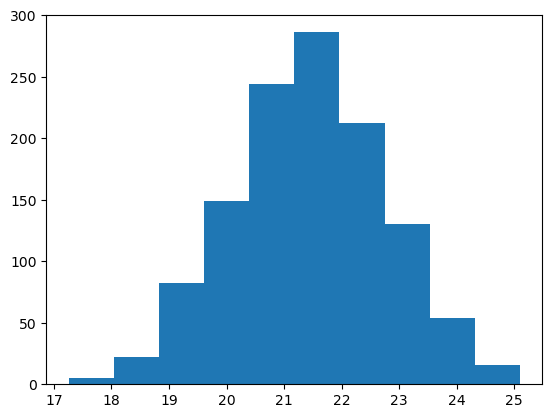

In [25]:

component_weights = torch.ones(num_components) / num_components  # Equal weights by default

# Parameters for each Gaussian component
means = (torch.randn(num_components, d) + 1 )* 10  # Random means for each component
stds = torch.rand(num_components, d)  + 0.5  # Random standard deviations

# Generate samples from mixture of Gaussians
component_indices = torch.multinomial(component_weights, m, replacement=True)
x_real = torch.zeros(m, d)
y_real = torch.ones(m, 1)
for i in range(m):
    component_idx = component_indices[i]
    x_real[i] = torch.randn(d) * stds[component_idx] + means[component_idx]
plt.hist(x_real, bins=10);


In [26]:
x_real.shape


torch.Size([1200, 1])

Epoch 0/500: D Loss: 0.7113, G Loss: 0.4462, D Accuracy: 0.9375


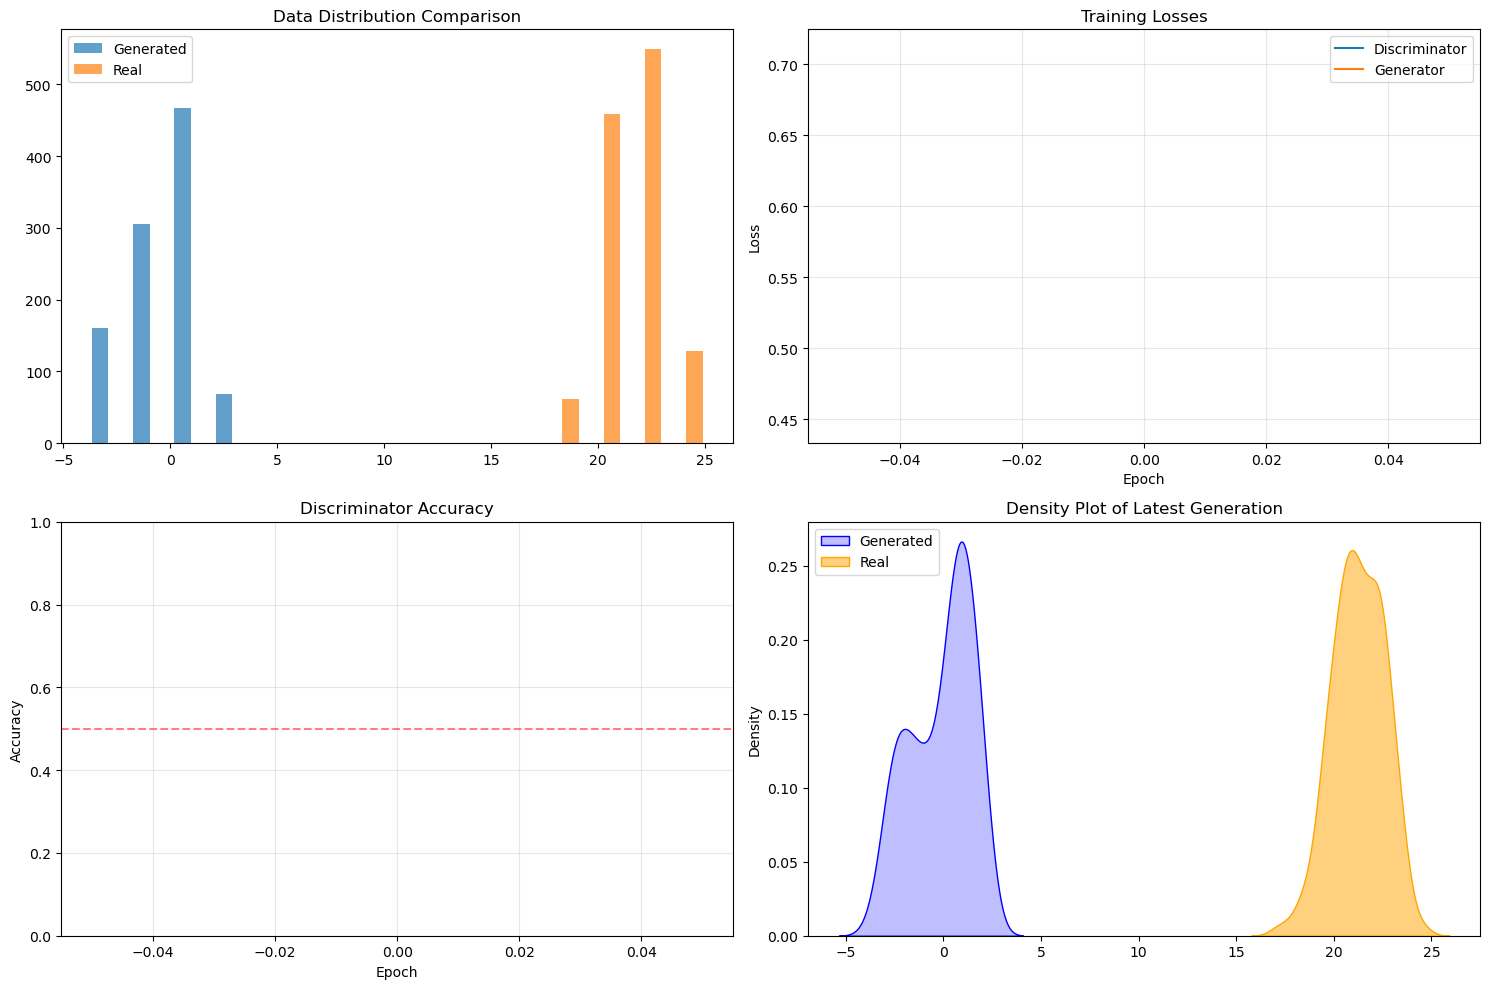

Epoch 1/500: D Loss: 0.7089, G Loss: 0.4519, D Accuracy: 0.9375
Epoch 2/500: D Loss: 0.7096, G Loss: 0.4538, D Accuracy: 0.9375
Epoch 3/500: D Loss: 0.7092, G Loss: 0.4577, D Accuracy: 0.9375
Epoch 4/500: D Loss: 0.7079, G Loss: 0.4632, D Accuracy: 0.9375
Epoch 5/500: D Loss: 0.7056, G Loss: 0.4699, D Accuracy: 0.9375
Epoch 6/500: D Loss: 0.7029, G Loss: 0.4773, D Accuracy: 0.9375
Epoch 7/500: D Loss: 0.7002, G Loss: 0.4846, D Accuracy: 0.9375
Epoch 8/500: D Loss: 0.6972, G Loss: 0.4923, D Accuracy: 0.9375
Epoch 9/500: D Loss: 0.6931, G Loss: 0.5017, D Accuracy: 0.9375
Epoch 10/500: D Loss: 0.6881, G Loss: 0.5124, D Accuracy: 0.9375


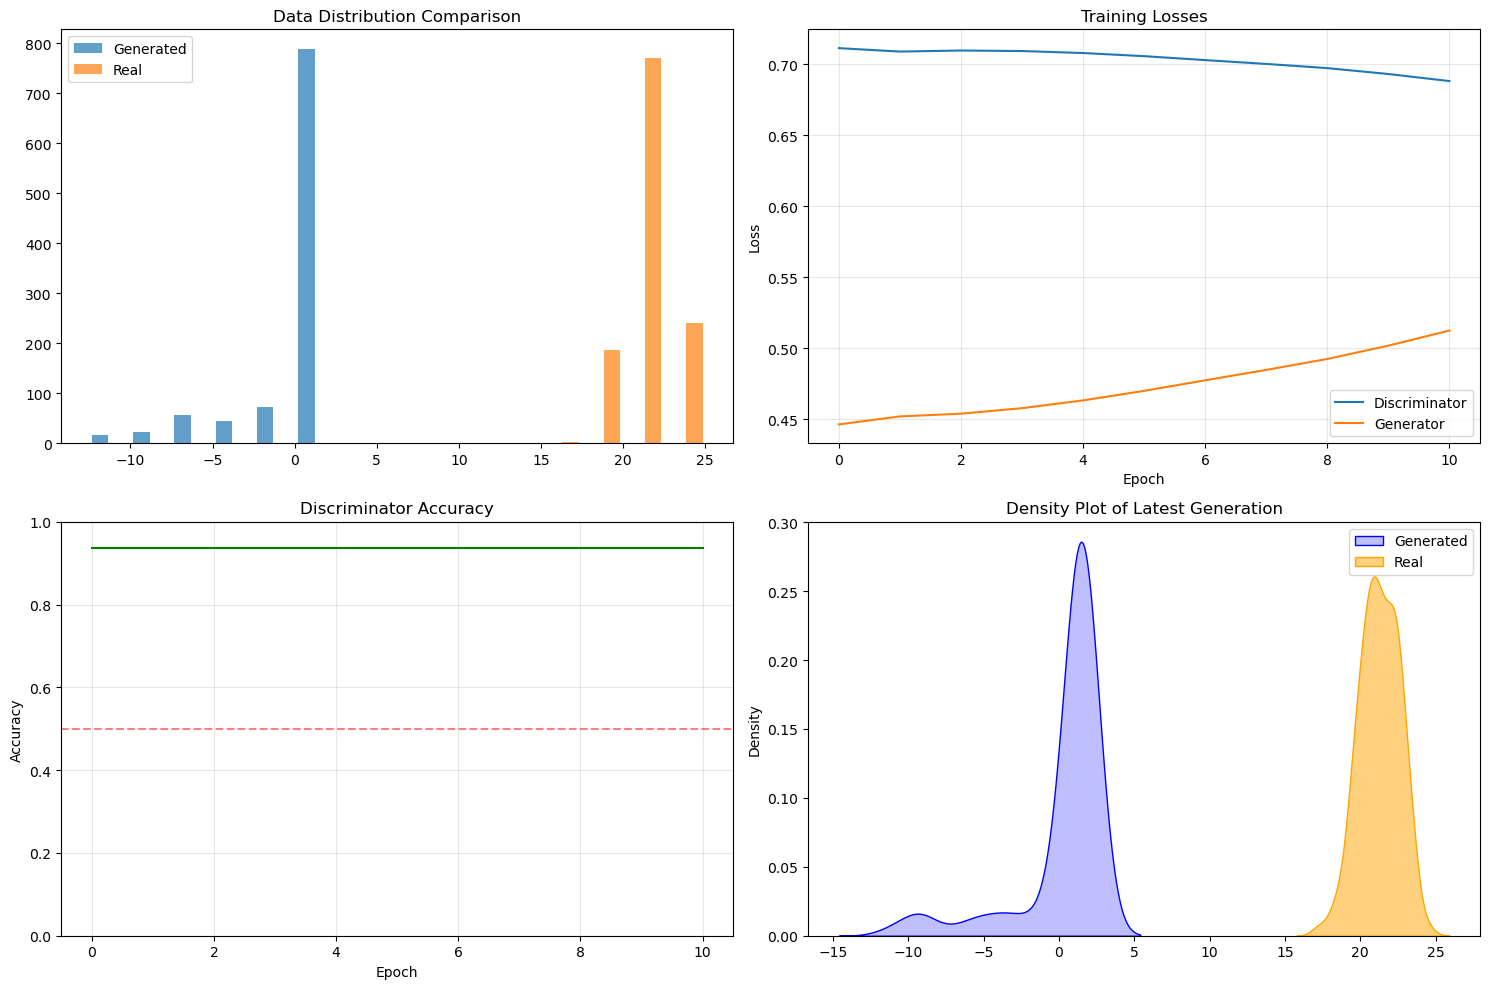

Epoch 11/500: D Loss: 0.6825, G Loss: 0.5240, D Accuracy: 0.9375
Epoch 12/500: D Loss: 0.6767, G Loss: 0.5353, D Accuracy: 0.9375
Epoch 13/500: D Loss: 0.6718, G Loss: 0.5430, D Accuracy: 0.9375
Epoch 14/500: D Loss: 0.6678, G Loss: 0.5494, D Accuracy: 0.9375
Epoch 15/500: D Loss: 0.6638, G Loss: 0.5520, D Accuracy: 0.9375
Epoch 16/500: D Loss: 0.6596, G Loss: 0.5545, D Accuracy: 0.9375
Epoch 17/500: D Loss: 0.6557, G Loss: 0.5568, D Accuracy: 0.9375
Epoch 18/500: D Loss: 0.6518, G Loss: 0.5592, D Accuracy: 0.9375
Epoch 19/500: D Loss: 0.6481, G Loss: 0.5611, D Accuracy: 0.9375
Epoch 20/500: D Loss: 0.6444, G Loss: 0.5628, D Accuracy: 0.9375


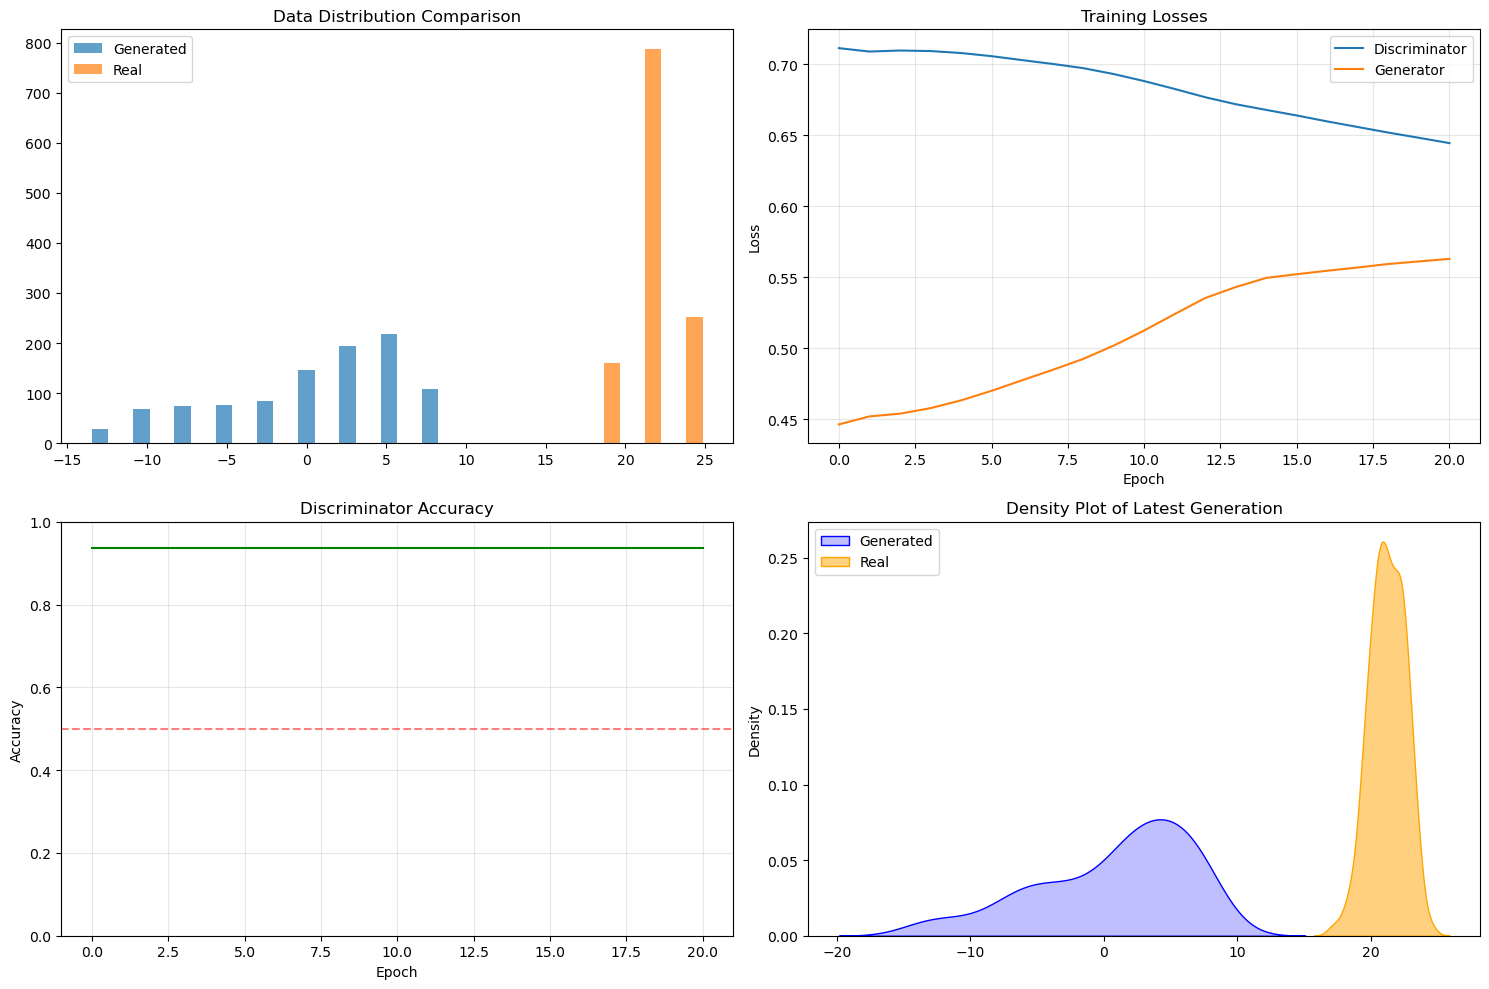

Epoch 21/500: D Loss: 0.6410, G Loss: 0.5639, D Accuracy: 0.9375
Epoch 22/500: D Loss: 0.6377, G Loss: 0.5646, D Accuracy: 0.9375
Epoch 23/500: D Loss: 0.6346, G Loss: 0.5652, D Accuracy: 0.9375
Epoch 24/500: D Loss: 0.6321, G Loss: 0.5653, D Accuracy: 0.9375
Epoch 25/500: D Loss: 0.6300, G Loss: 0.5649, D Accuracy: 0.9375
Epoch 26/500: D Loss: 0.6282, G Loss: 0.5641, D Accuracy: 0.9375
Epoch 27/500: D Loss: 0.6276, G Loss: 0.5625, D Accuracy: 0.9375
Epoch 28/500: D Loss: 0.6272, G Loss: 0.5611, D Accuracy: 0.9375
Epoch 29/500: D Loss: 0.6284, G Loss: 0.5586, D Accuracy: 0.9375
Epoch 30/500: D Loss: 0.6303, G Loss: 0.5558, D Accuracy: 0.9375


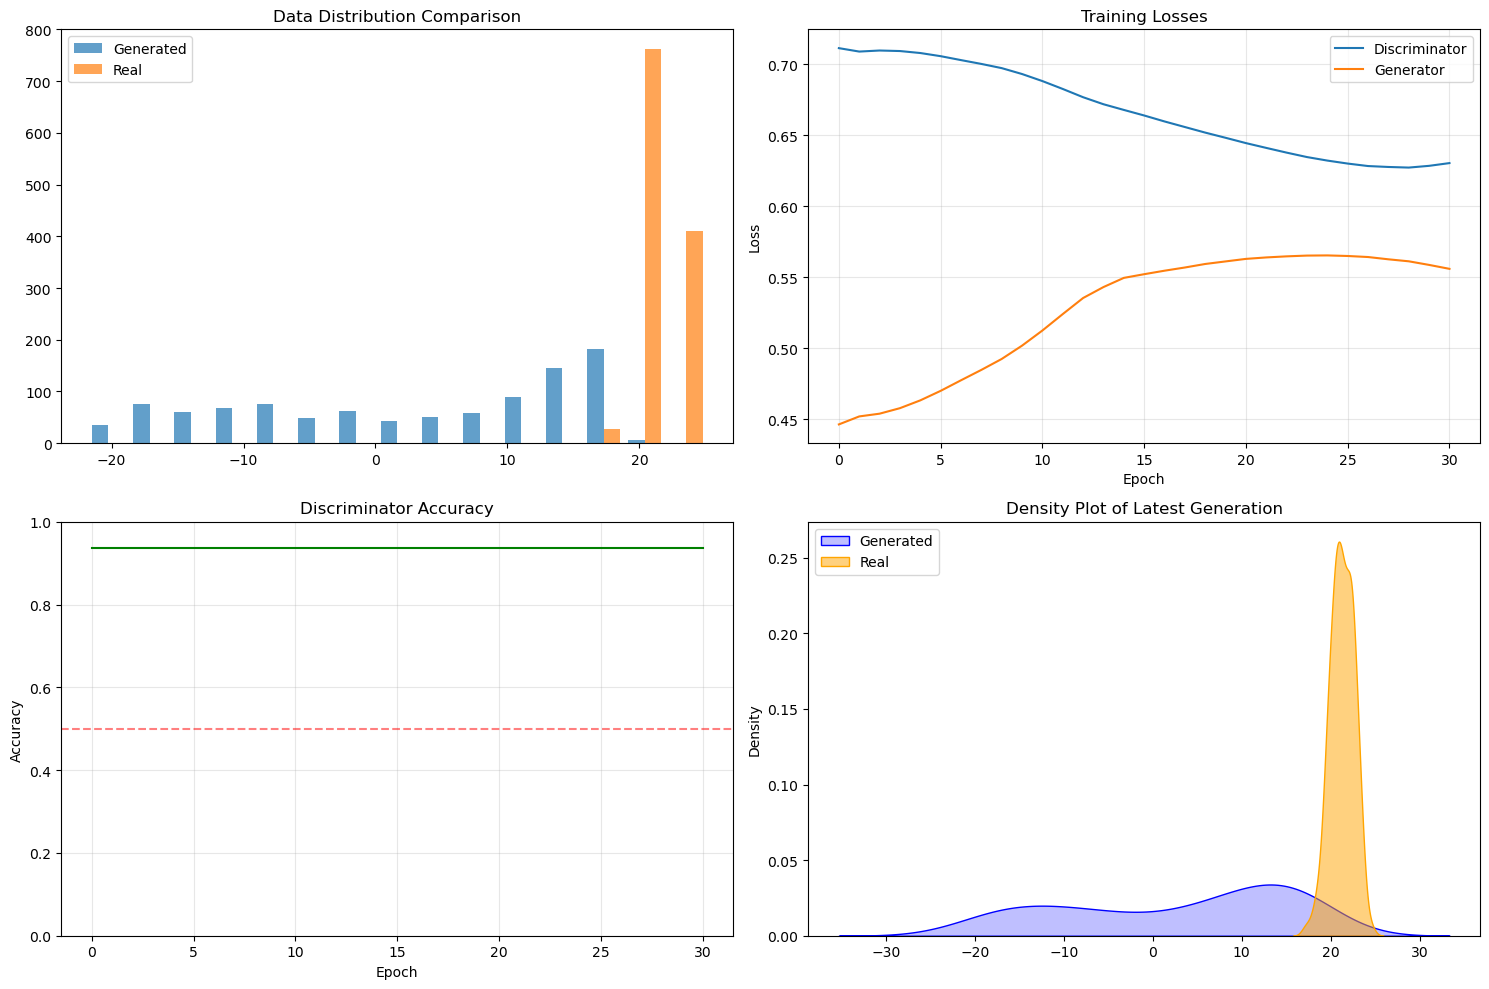

Epoch 31/500: D Loss: 0.6339, G Loss: 0.5519, D Accuracy: 0.9375
Epoch 32/500: D Loss: 0.6364, G Loss: 0.5501, D Accuracy: 0.9375
Epoch 33/500: D Loss: 0.6423, G Loss: 0.5457, D Accuracy: 0.9375
Epoch 34/500: D Loss: 0.6486, G Loss: 0.5416, D Accuracy: 0.9375
Epoch 35/500: D Loss: 0.6548, G Loss: 0.5380, D Accuracy: 0.9375
Epoch 36/500: D Loss: 0.6598, G Loss: 0.5351, D Accuracy: 0.9375
Epoch 37/500: D Loss: 0.6664, G Loss: 0.5426, D Accuracy: 0.9375
Epoch 38/500: D Loss: 0.6692, G Loss: 0.5161, D Accuracy: 0.9375
Epoch 39/500: D Loss: 0.6693, G Loss: 0.5313, D Accuracy: 0.9375
Epoch 40/500: D Loss: 0.6786, G Loss: 0.5705, D Accuracy: 0.9375


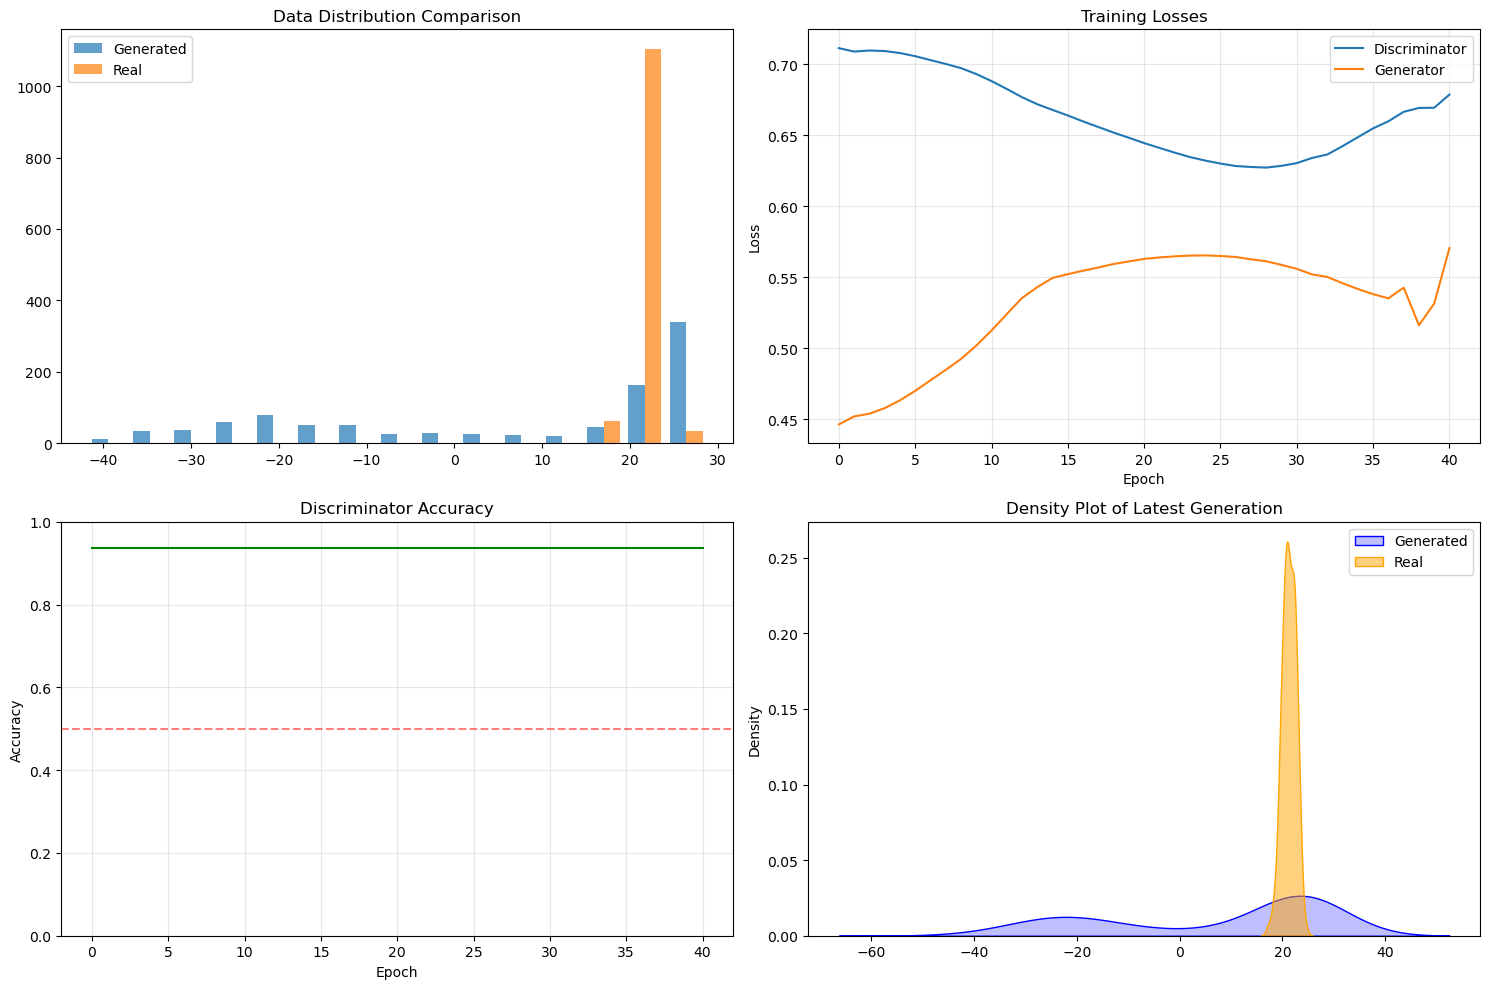

Epoch 41/500: D Loss: 0.6860, G Loss: 0.5581, D Accuracy: 0.9375
Epoch 42/500: D Loss: 0.6681, G Loss: 0.5358, D Accuracy: 0.9375
Epoch 43/500: D Loss: 0.6789, G Loss: 0.5193, D Accuracy: 0.9375
Epoch 44/500: D Loss: 0.6876, G Loss: 0.5144, D Accuracy: 0.9375
Epoch 45/500: D Loss: 0.6786, G Loss: 0.5435, D Accuracy: 0.9375
Epoch 46/500: D Loss: 0.6885, G Loss: 0.5734, D Accuracy: 0.9141
Epoch 47/500: D Loss: 0.6715, G Loss: 0.5687, D Accuracy: 0.7691
Epoch 48/500: D Loss: 0.6759, G Loss: 0.5588, D Accuracy: 0.7980
Epoch 49/500: D Loss: 0.6795, G Loss: 0.5587, D Accuracy: 0.8059
Epoch 50/500: D Loss: 0.6815, G Loss: 0.5624, D Accuracy: 0.8297


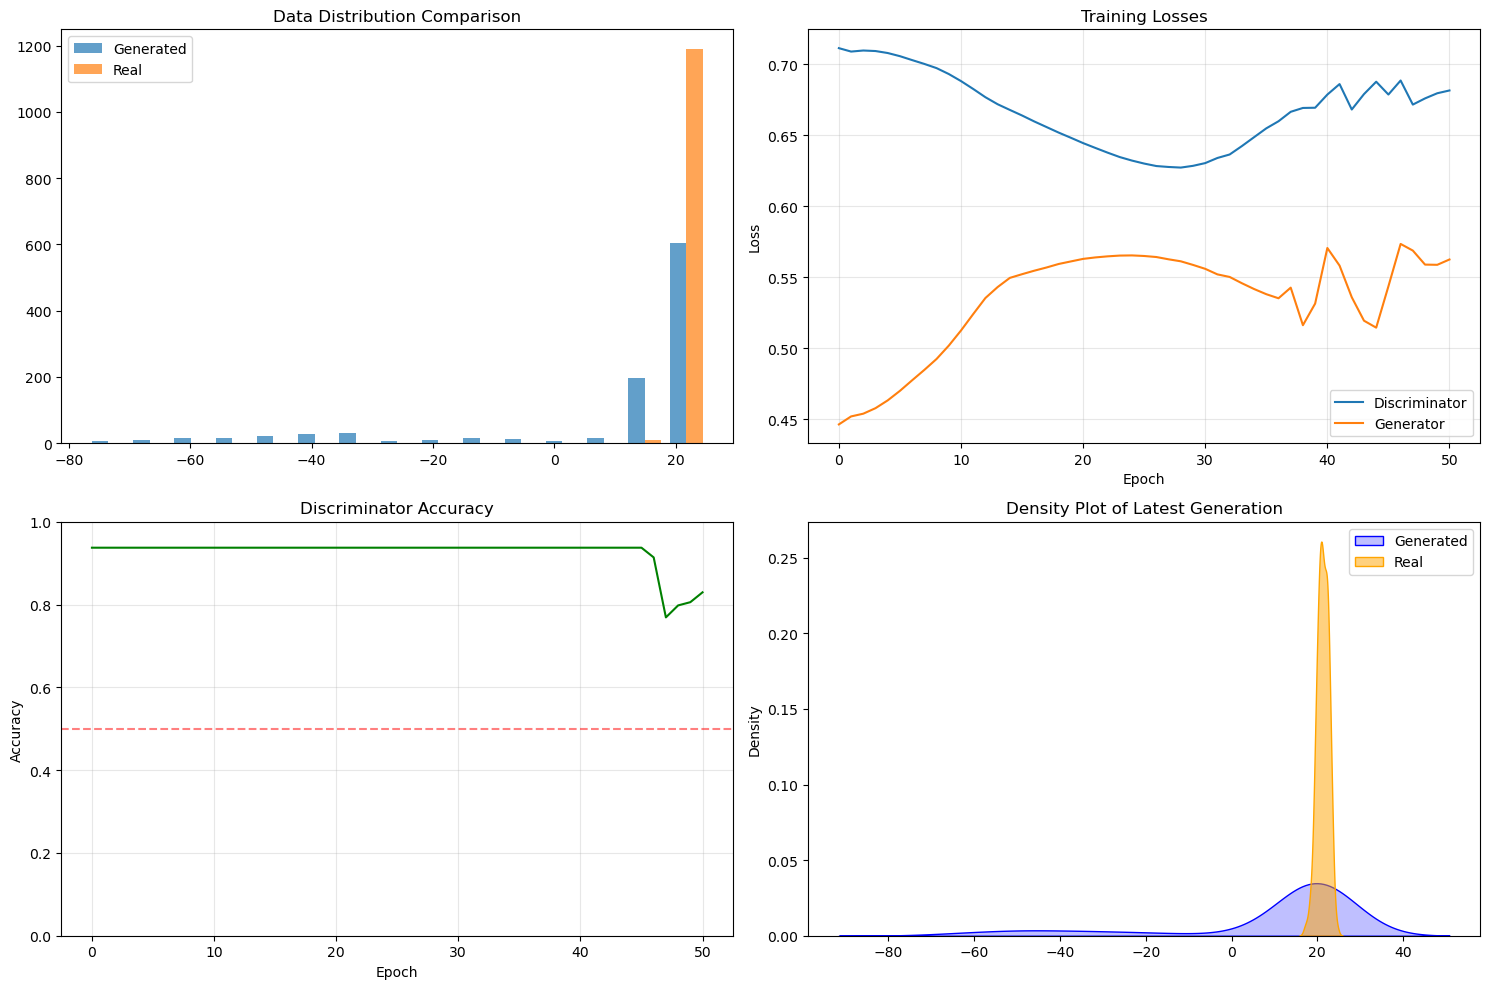

Epoch 51/500: D Loss: 0.6811, G Loss: 0.5793, D Accuracy: 0.8270
Epoch 52/500: D Loss: 0.6830, G Loss: 0.5802, D Accuracy: 0.8219
Epoch 53/500: D Loss: 0.6836, G Loss: 0.5794, D Accuracy: 0.8395
Epoch 54/500: D Loss: 0.6857, G Loss: 0.5834, D Accuracy: 0.8590
Epoch 55/500: D Loss: 0.6846, G Loss: 0.5984, D Accuracy: 0.8484
Epoch 56/500: D Loss: 0.6831, G Loss: 0.6081, D Accuracy: 0.8289
Epoch 57/500: D Loss: 0.6832, G Loss: 0.6054, D Accuracy: 0.8531
Epoch 58/500: D Loss: 0.6843, G Loss: 0.6087, D Accuracy: 0.8508
Epoch 59/500: D Loss: 0.6841, G Loss: 0.6141, D Accuracy: 0.8504
Epoch 60/500: D Loss: 0.6802, G Loss: 0.6273, D Accuracy: 0.8523


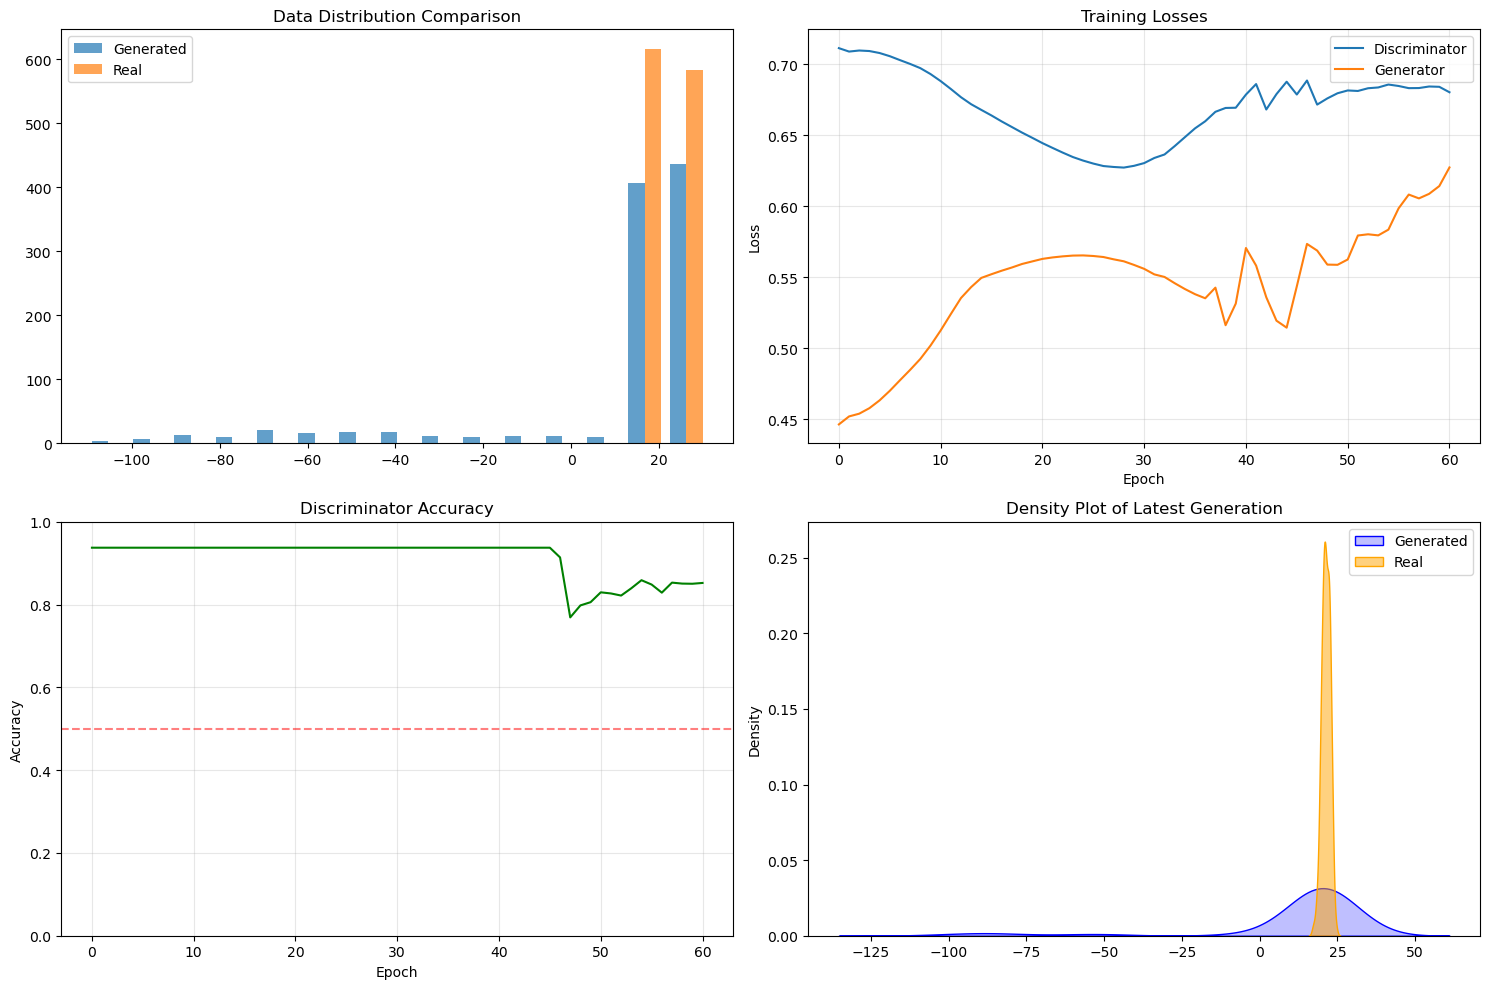

Epoch 61/500: D Loss: 0.6844, G Loss: 0.6252, D Accuracy: 0.8418
Epoch 62/500: D Loss: 0.6829, G Loss: 0.6242, D Accuracy: 0.8434
Epoch 63/500: D Loss: 0.6837, G Loss: 0.6237, D Accuracy: 0.8535
Epoch 64/500: D Loss: 0.6850, G Loss: 0.6236, D Accuracy: 0.8668
Epoch 65/500: D Loss: 0.6846, G Loss: 0.6294, D Accuracy: 0.8676
Epoch 66/500: D Loss: 0.6837, G Loss: 0.6371, D Accuracy: 0.8648
Epoch 67/500: D Loss: 0.6842, G Loss: 0.6401, D Accuracy: 0.8500
Epoch 68/500: D Loss: 0.6830, G Loss: 0.6388, D Accuracy: 0.8461
Epoch 69/500: D Loss: 0.6837, G Loss: 0.6360, D Accuracy: 0.8566
Epoch 70/500: D Loss: 0.6855, G Loss: 0.6330, D Accuracy: 0.8684


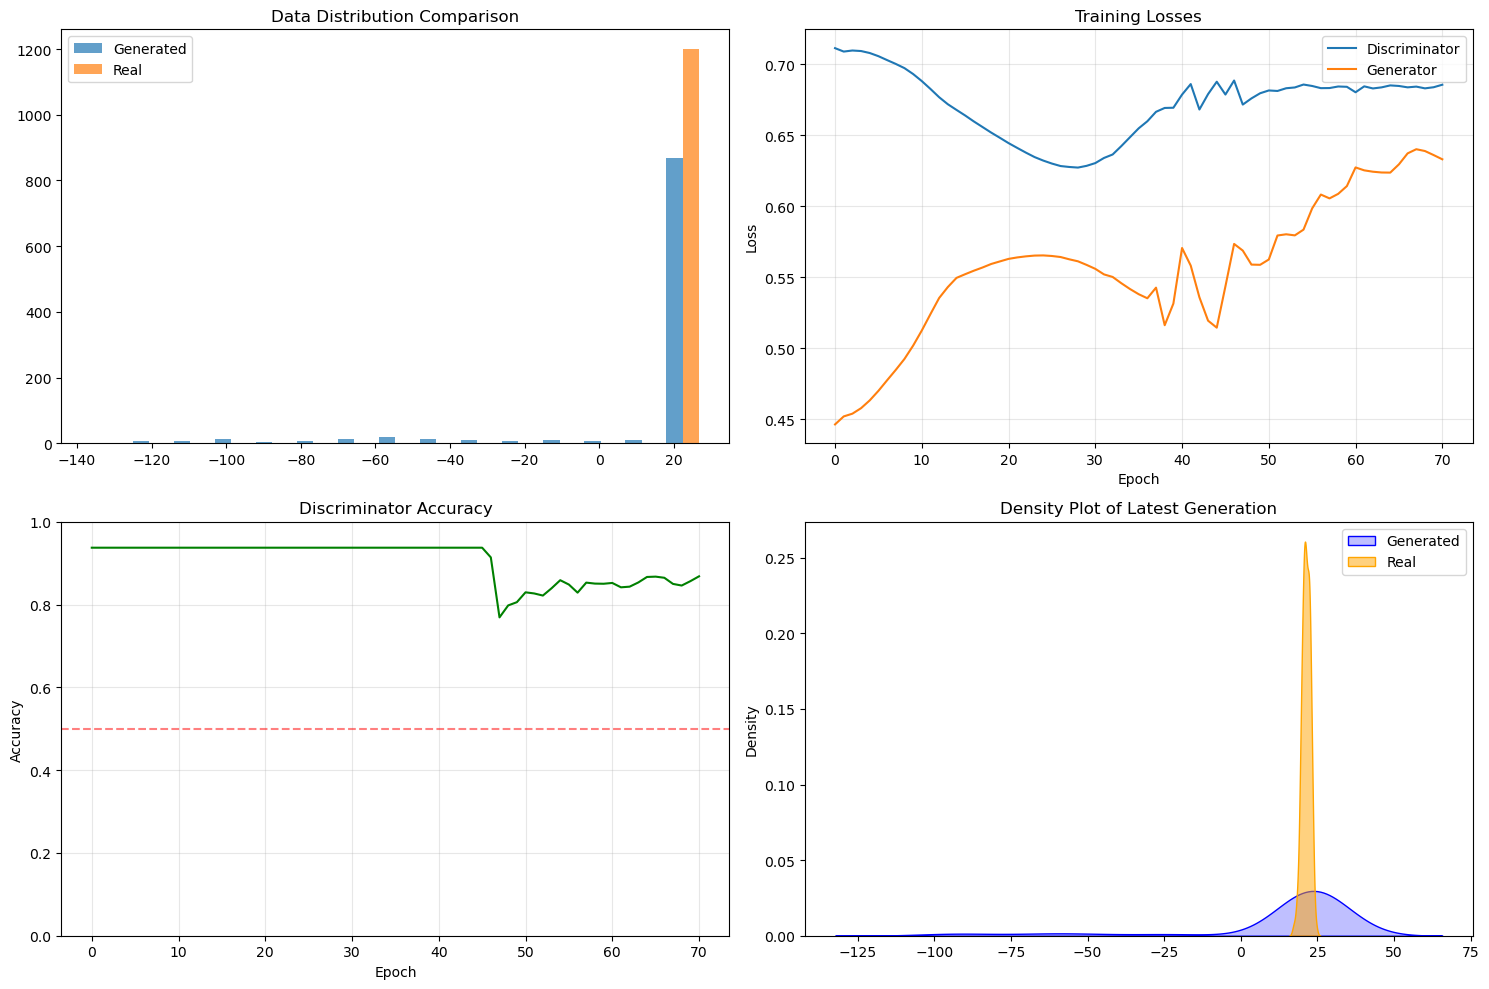

Epoch 71/500: D Loss: 0.6856, G Loss: 0.6346, D Accuracy: 0.8711
Epoch 72/500: D Loss: 0.6860, G Loss: 0.6373, D Accuracy: 0.8805
Epoch 73/500: D Loss: 0.6869, G Loss: 0.6397, D Accuracy: 0.8832
Epoch 74/500: D Loss: 0.6870, G Loss: 0.6433, D Accuracy: 0.8812
Epoch 75/500: D Loss: 0.6874, G Loss: 0.6456, D Accuracy: 0.8863
Epoch 76/500: D Loss: 0.6873, G Loss: 0.6487, D Accuracy: 0.8797
Epoch 77/500: D Loss: 0.6872, G Loss: 0.6505, D Accuracy: 0.8836
Epoch 78/500: D Loss: 0.6880, G Loss: 0.6510, D Accuracy: 0.8910
Epoch 79/500: D Loss: 0.6877, G Loss: 0.6552, D Accuracy: 0.8891
Epoch 80/500: D Loss: 0.6837, G Loss: 0.6655, D Accuracy: 0.8453


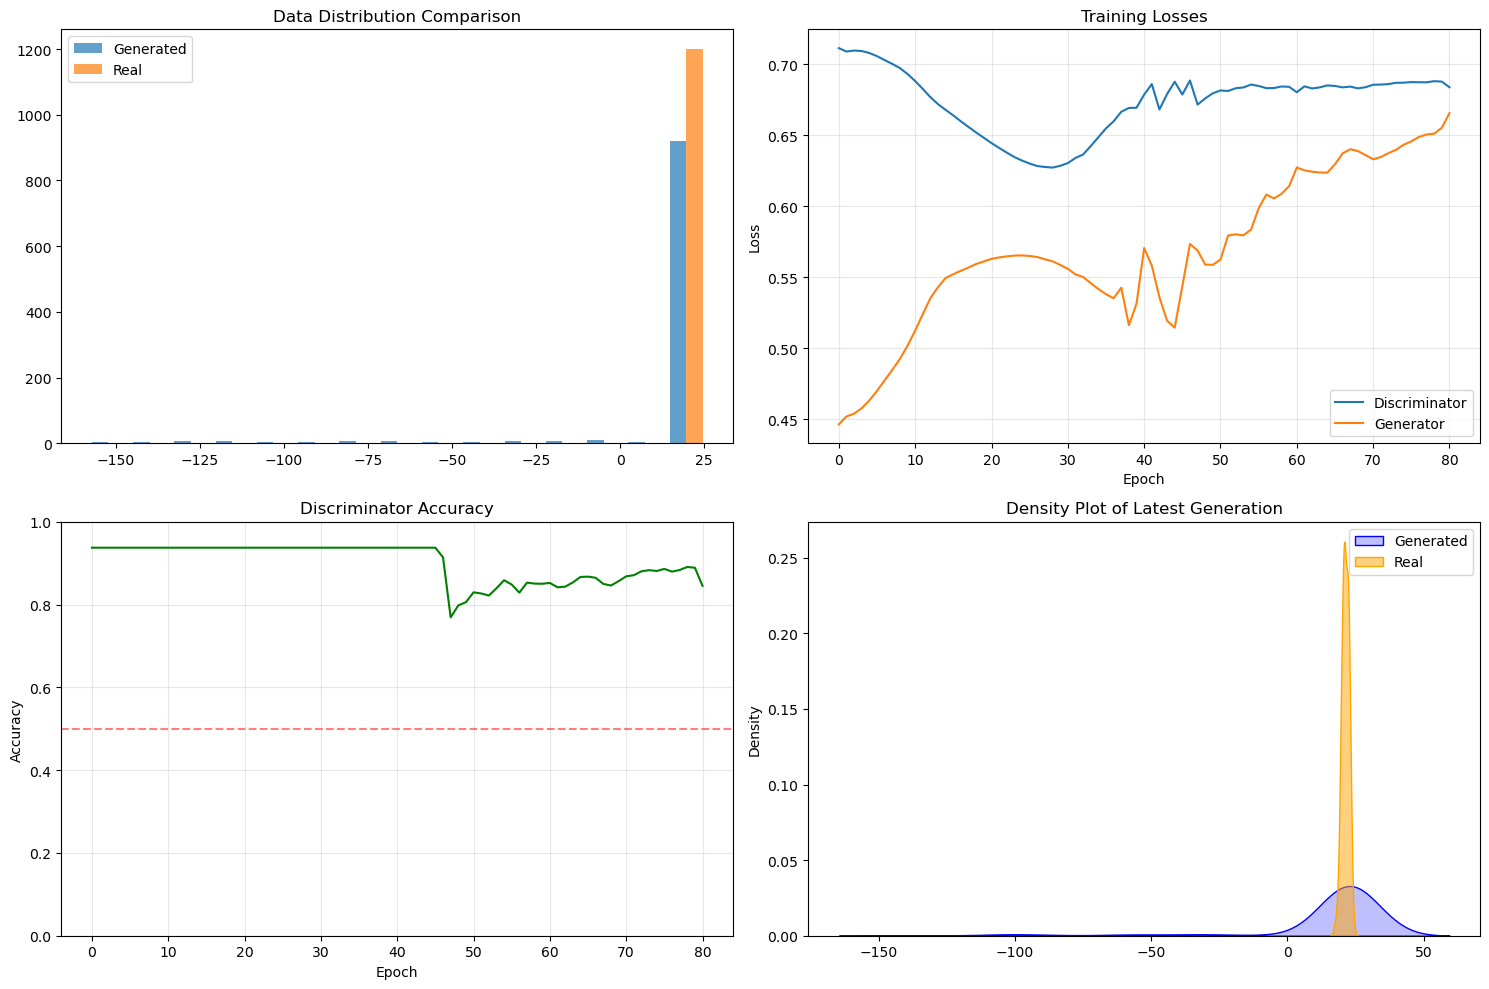

Epoch 81/500: D Loss: 0.6882, G Loss: 0.6553, D Accuracy: 0.8891
Epoch 82/500: D Loss: 0.6881, G Loss: 0.6550, D Accuracy: 0.8906
Epoch 83/500: D Loss: 0.6878, G Loss: 0.6566, D Accuracy: 0.8906
Epoch 84/500: D Loss: 0.6864, G Loss: 0.6612, D Accuracy: 0.8805
Epoch 85/500: D Loss: 0.6881, G Loss: 0.6609, D Accuracy: 0.8906
Epoch 86/500: D Loss: 0.6882, G Loss: 0.6626, D Accuracy: 0.8816
Epoch 87/500: D Loss: 0.6893, G Loss: 0.6600, D Accuracy: 0.8996
Epoch 88/500: D Loss: 0.6884, G Loss: 0.6628, D Accuracy: 0.8965
Epoch 89/500: D Loss: 0.6892, G Loss: 0.6633, D Accuracy: 0.9031
Epoch 90/500: D Loss: 0.6880, G Loss: 0.6679, D Accuracy: 0.8906


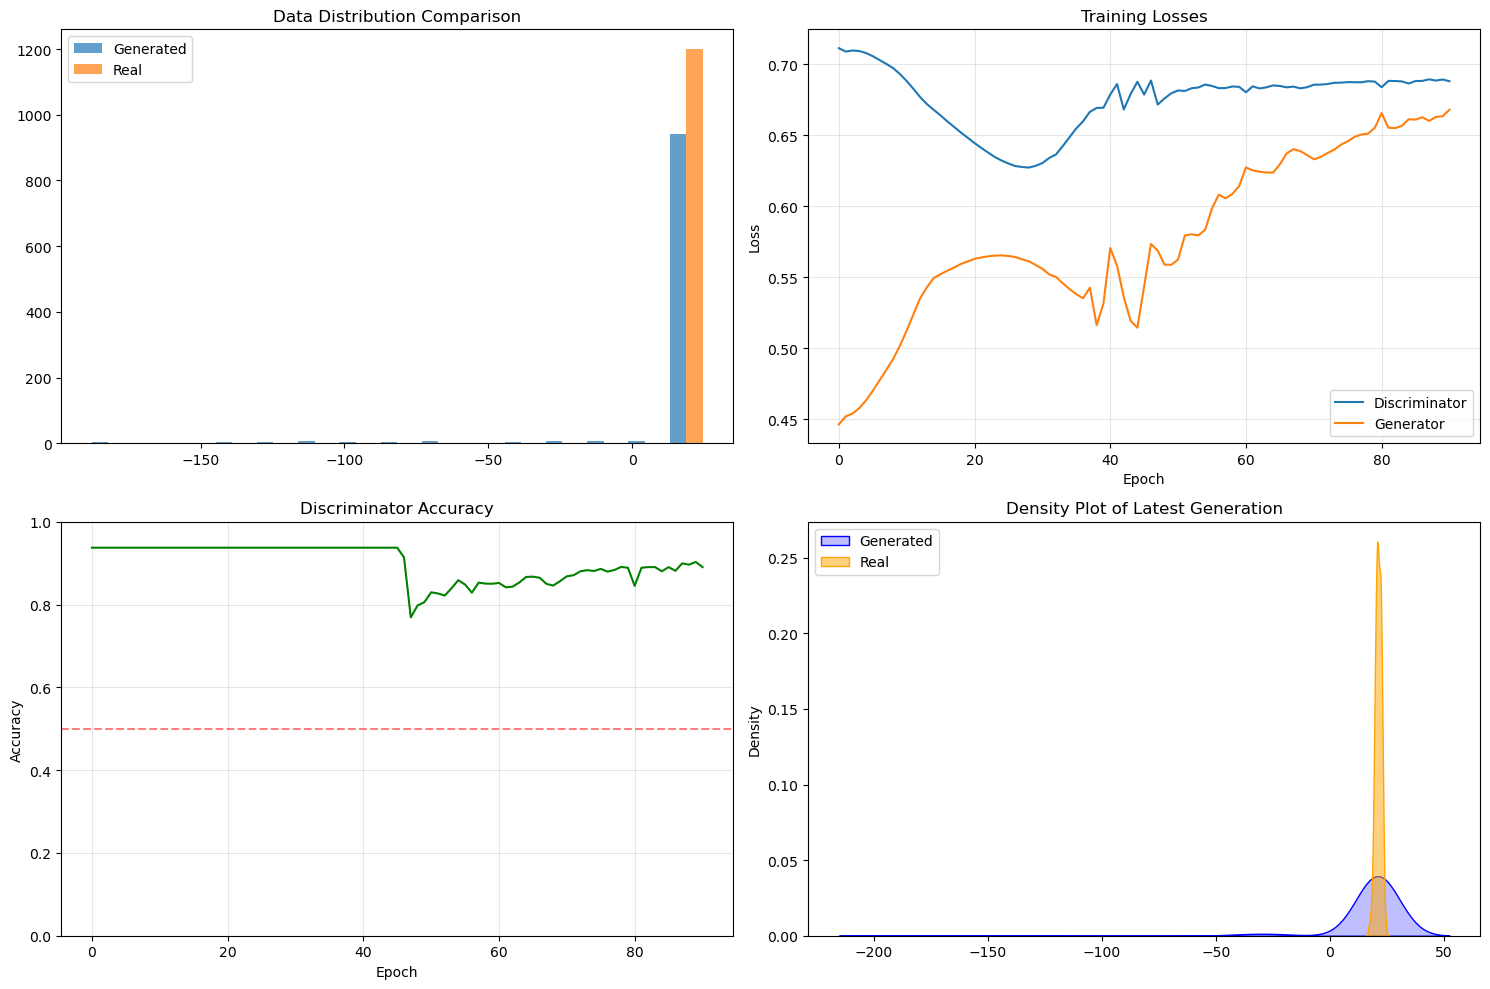

Epoch 91/500: D Loss: 0.6894, G Loss: 0.6676, D Accuracy: 0.9027
Epoch 92/500: D Loss: 0.6901, G Loss: 0.6687, D Accuracy: 0.8984
Epoch 93/500: D Loss: 0.6880, G Loss: 0.6719, D Accuracy: 0.8957
Epoch 94/500: D Loss: 0.6888, G Loss: 0.6687, D Accuracy: 0.8992
Epoch 95/500: D Loss: 0.6892, G Loss: 0.6679, D Accuracy: 0.9039
Epoch 96/500: D Loss: 0.6892, G Loss: 0.6693, D Accuracy: 0.9031
Epoch 97/500: D Loss: 0.6897, G Loss: 0.6749, D Accuracy: 0.8637
Epoch 98/500: D Loss: 0.6894, G Loss: 0.6731, D Accuracy: 0.8875
Epoch 99/500: D Loss: 0.6894, G Loss: 0.6709, D Accuracy: 0.9090
Epoch 100/500: D Loss: 0.6897, G Loss: 0.6704, D Accuracy: 0.9078


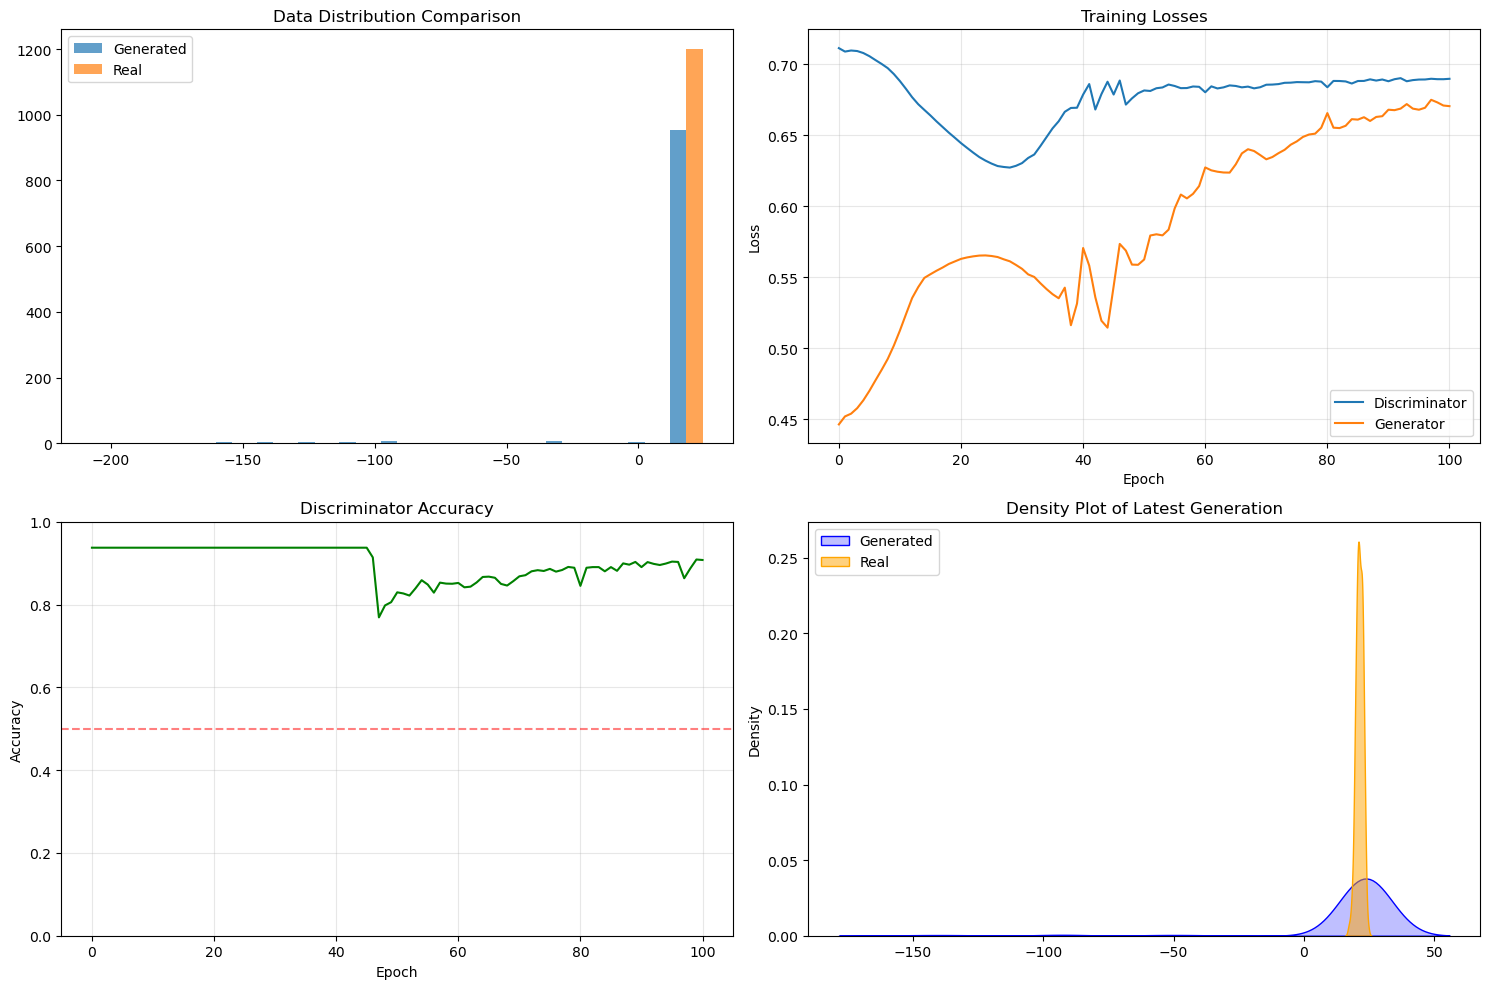

Epoch 101/500: D Loss: 0.6905, G Loss: 0.6696, D Accuracy: 0.9156
Epoch 102/500: D Loss: 0.6909, G Loss: 0.6711, D Accuracy: 0.9180
Epoch 103/500: D Loss: 0.6895, G Loss: 0.6770, D Accuracy: 0.9129
Epoch 104/500: D Loss: 0.6844, G Loss: 0.6903, D Accuracy: 0.8445
Epoch 105/500: D Loss: 0.6922, G Loss: 0.6774, D Accuracy: 0.8551
Epoch 106/500: D Loss: 0.6885, G Loss: 0.6816, D Accuracy: 0.8879
Epoch 107/500: D Loss: 0.6901, G Loss: 0.6758, D Accuracy: 0.9125
Epoch 108/500: D Loss: 0.6898, G Loss: 0.6761, D Accuracy: 0.9074
Epoch 109/500: D Loss: 0.6909, G Loss: 0.6744, D Accuracy: 0.9176
Epoch 110/500: D Loss: 0.6898, G Loss: 0.6785, D Accuracy: 0.9078


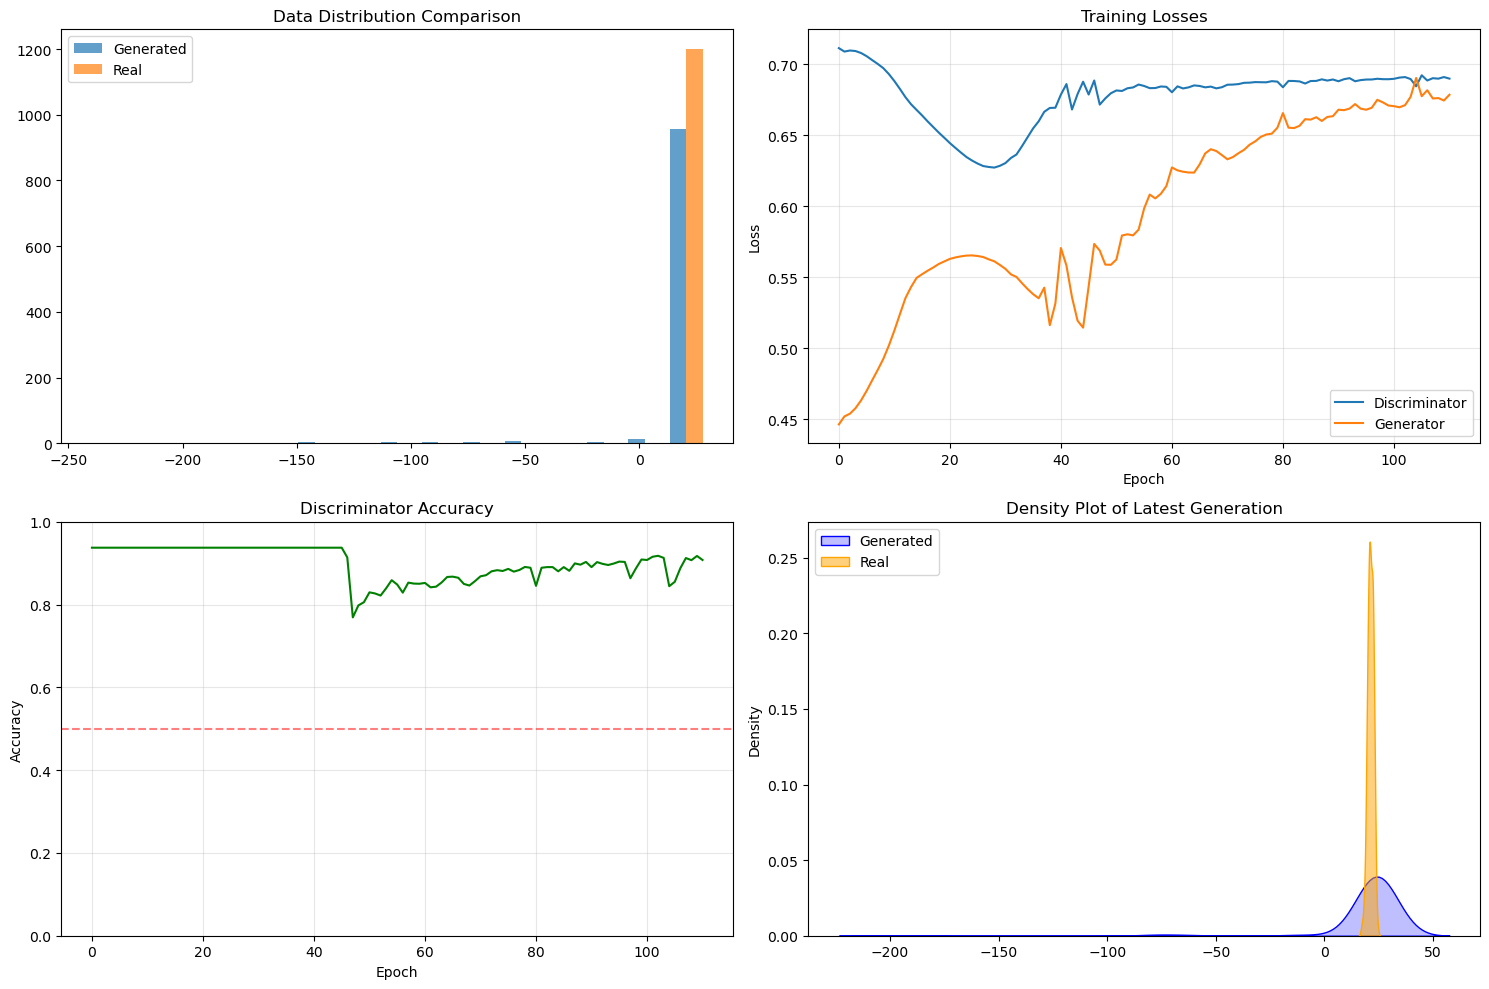

Epoch 111/500: D Loss: 0.6895, G Loss: 0.6802, D Accuracy: 0.9070
Epoch 112/500: D Loss: 0.6892, G Loss: 0.6807, D Accuracy: 0.9055
Epoch 113/500: D Loss: 0.6897, G Loss: 0.6784, D Accuracy: 0.9078
Epoch 114/500: D Loss: 0.6902, G Loss: 0.6760, D Accuracy: 0.9145
Epoch 115/500: D Loss: 0.6899, G Loss: 0.6764, D Accuracy: 0.9109
Epoch 116/500: D Loss: 0.6894, G Loss: 0.6770, D Accuracy: 0.9086
Epoch 117/500: D Loss: 0.6905, G Loss: 0.6750, D Accuracy: 0.9168
Epoch 118/500: D Loss: 0.6909, G Loss: 0.6751, D Accuracy: 0.9191
Epoch 119/500: D Loss: 0.6893, G Loss: 0.6803, D Accuracy: 0.9141
Epoch 120/500: D Loss: 0.6897, G Loss: 0.6805, D Accuracy: 0.9117


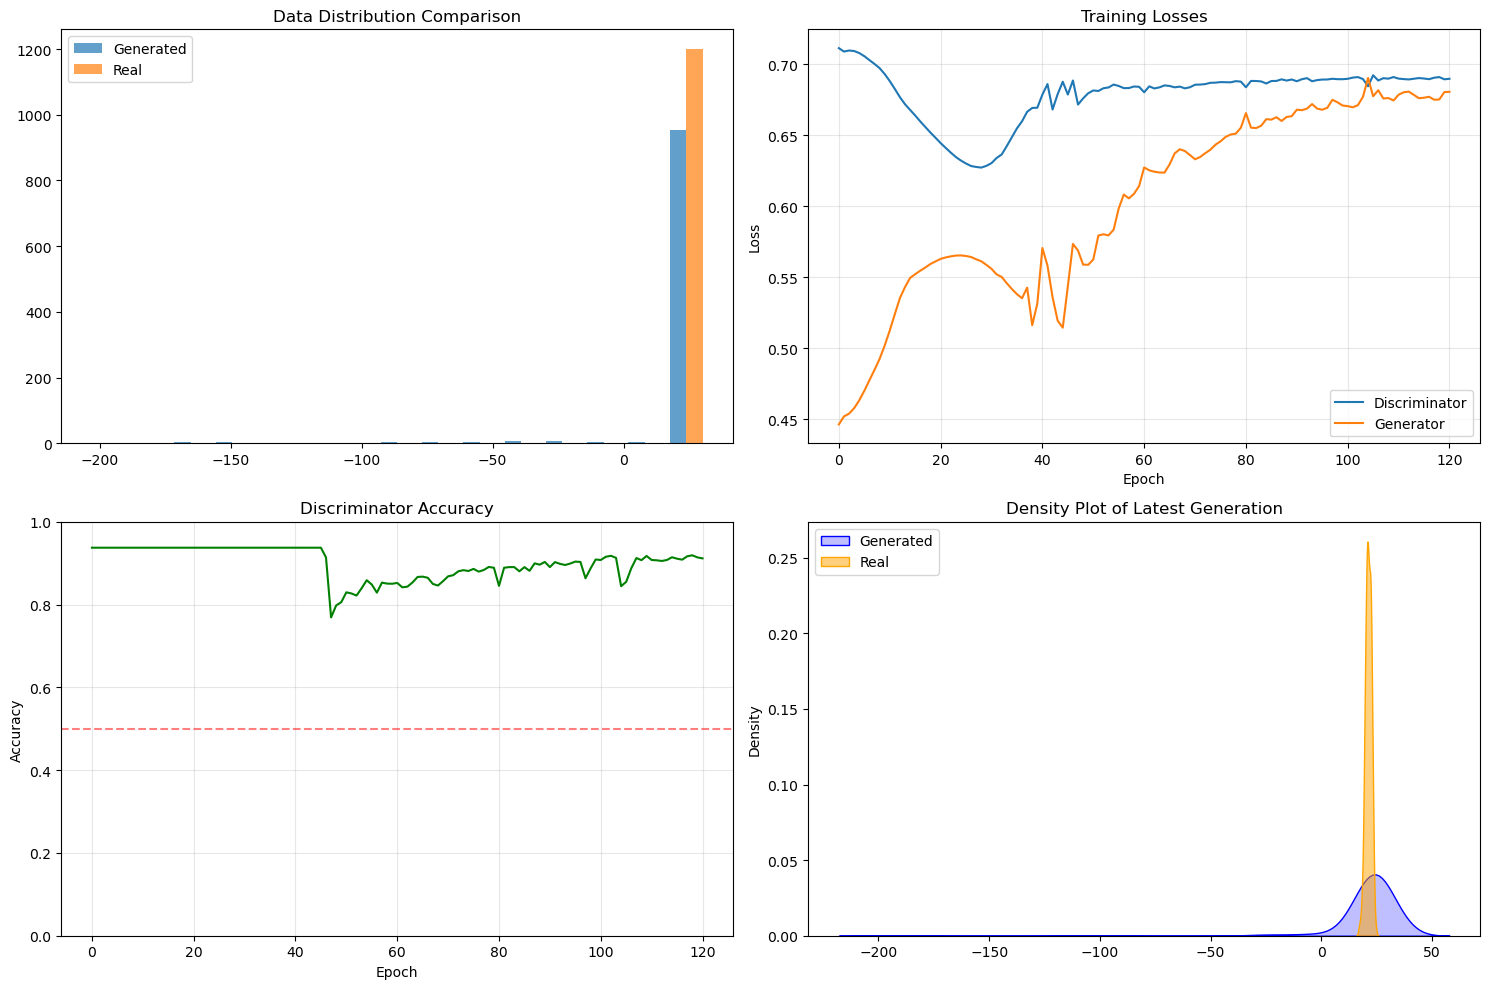

Epoch 121/500: D Loss: 0.6903, G Loss: 0.6788, D Accuracy: 0.9141
Epoch 122/500: D Loss: 0.6905, G Loss: 0.6780, D Accuracy: 0.9152
Epoch 123/500: D Loss: 0.6883, G Loss: 0.6834, D Accuracy: 0.9109
Epoch 124/500: D Loss: 0.6903, G Loss: 0.6778, D Accuracy: 0.9156
Epoch 125/500: D Loss: 0.6901, G Loss: 0.6774, D Accuracy: 0.9141
Epoch 126/500: D Loss: 0.6909, G Loss: 0.6758, D Accuracy: 0.9199
Epoch 127/500: D Loss: 0.6883, G Loss: 0.6824, D Accuracy: 0.8969
Epoch 128/500: D Loss: 0.6892, G Loss: 0.6803, D Accuracy: 0.9125
Epoch 129/500: D Loss: 0.6888, G Loss: 0.6810, D Accuracy: 0.8938
Epoch 130/500: D Loss: 0.6905, G Loss: 0.6777, D Accuracy: 0.9094


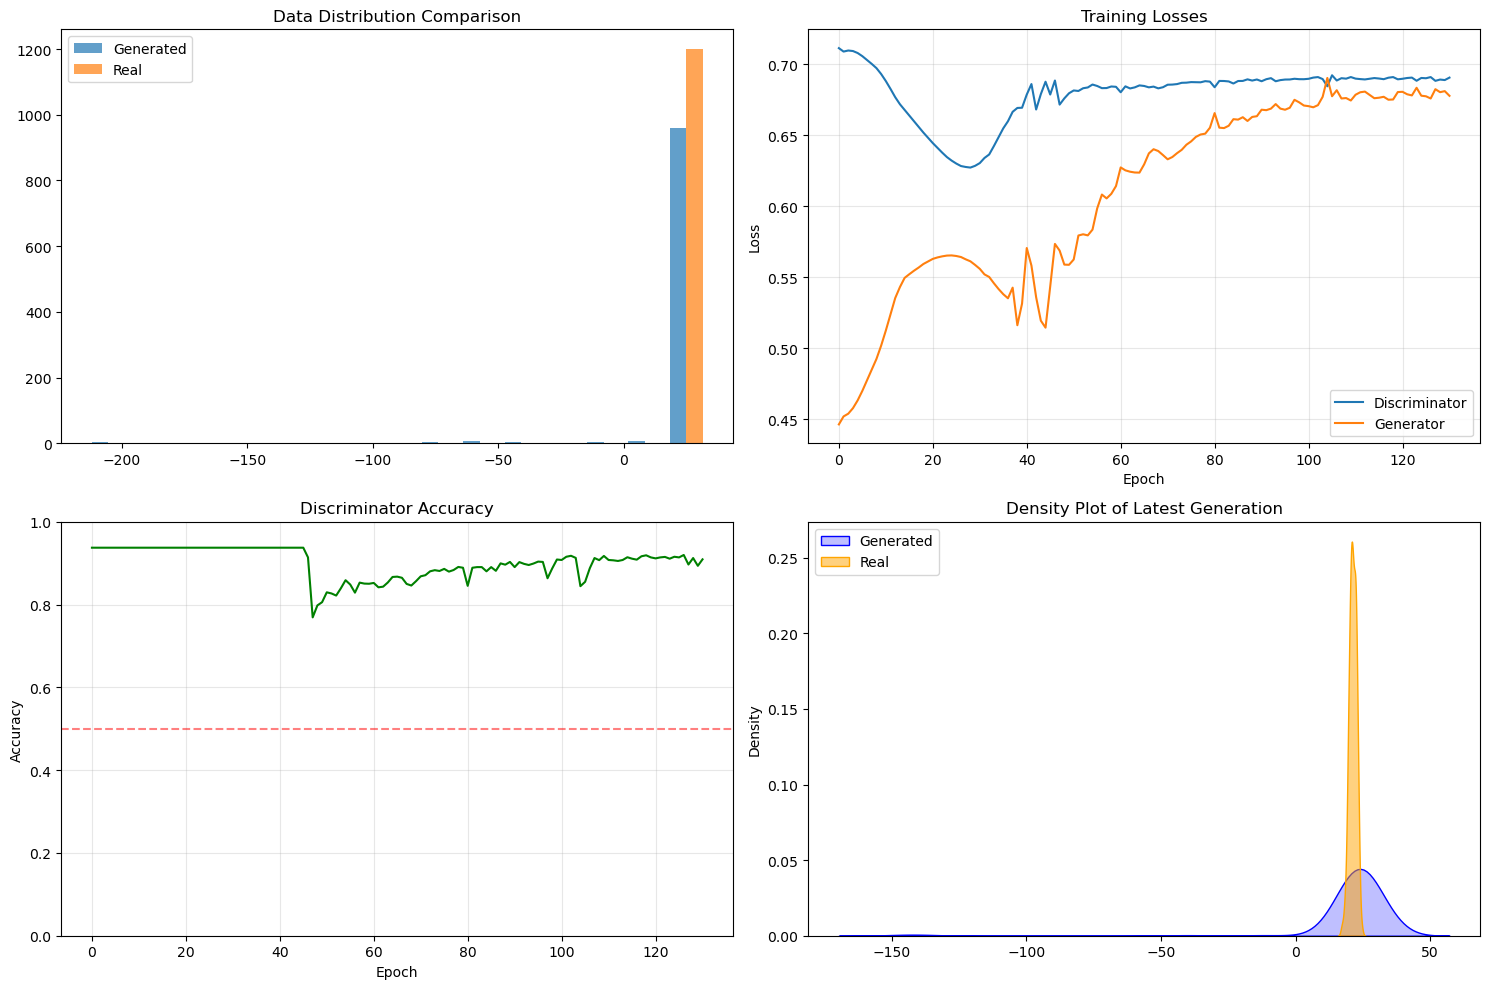

Epoch 131/500: D Loss: 0.6905, G Loss: 0.6783, D Accuracy: 0.9117
Epoch 132/500: D Loss: 0.6907, G Loss: 0.6784, D Accuracy: 0.9168
Epoch 133/500: D Loss: 0.6886, G Loss: 0.6841, D Accuracy: 0.9129
Epoch 134/500: D Loss: 0.6893, G Loss: 0.6818, D Accuracy: 0.9133
Epoch 135/500: D Loss: 0.6908, G Loss: 0.6783, D Accuracy: 0.9199
Epoch 136/500: D Loss: 0.6904, G Loss: 0.6800, D Accuracy: 0.9102
Epoch 137/500: D Loss: 0.6900, G Loss: 0.6818, D Accuracy: 0.9086
Epoch 138/500: D Loss: 0.6910, G Loss: 0.6798, D Accuracy: 0.9172
Epoch 139/500: D Loss: 0.6906, G Loss: 0.6818, D Accuracy: 0.9180
Epoch 140/500: D Loss: 0.6904, G Loss: 0.6829, D Accuracy: 0.9172


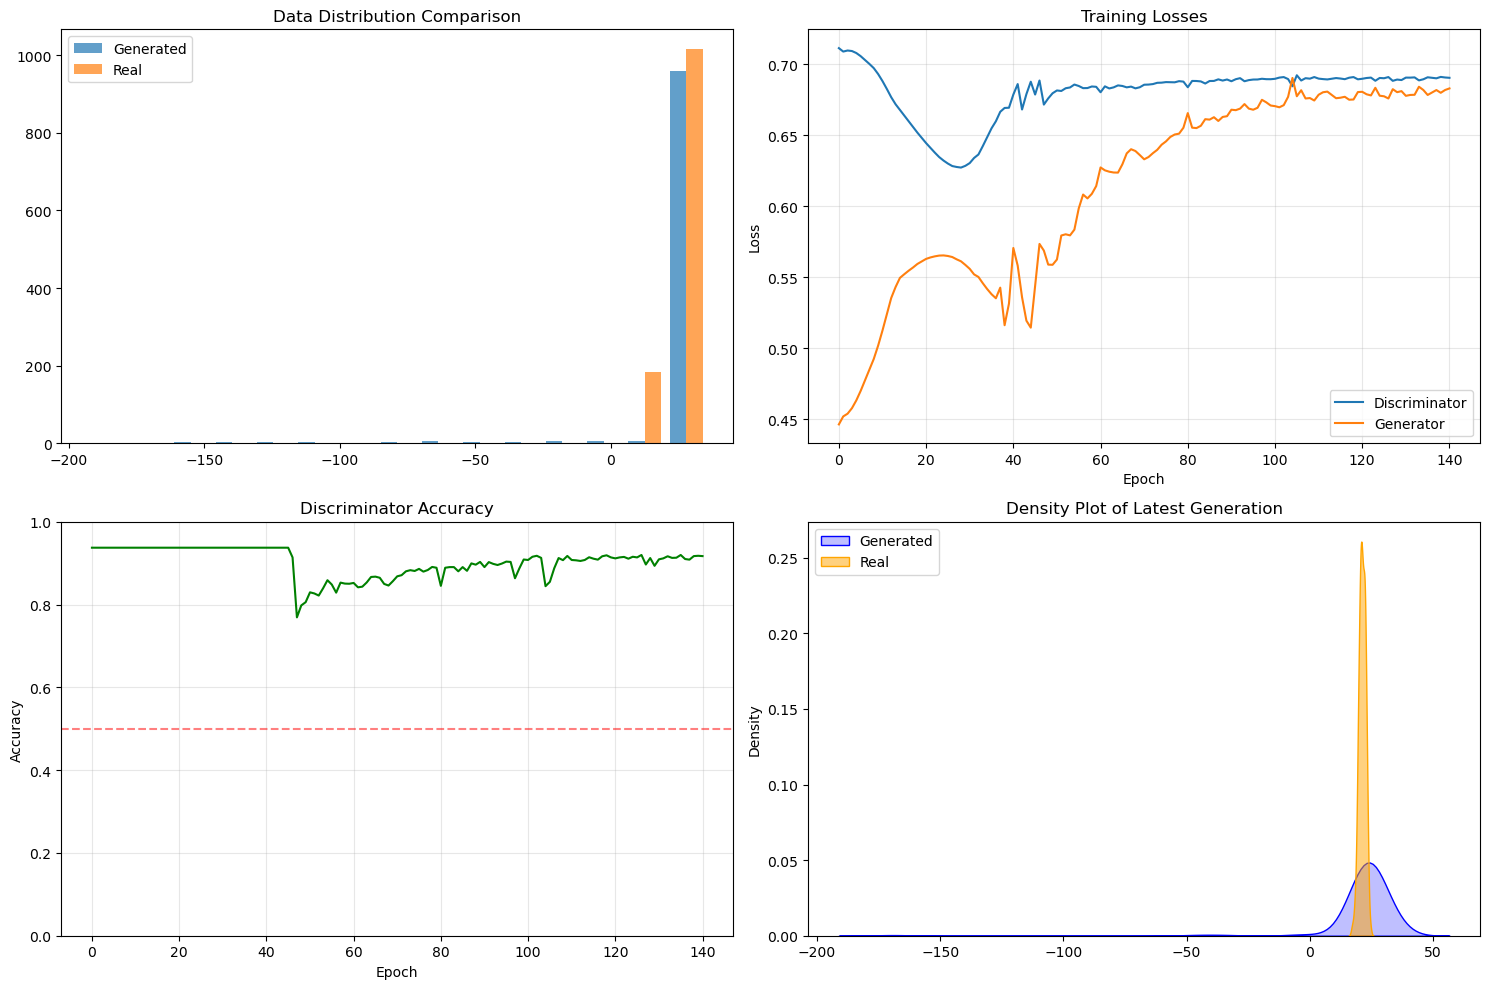

Epoch 141/500: D Loss: 0.6914, G Loss: 0.6813, D Accuracy: 0.9230
Epoch 142/500: D Loss: 0.6908, G Loss: 0.6839, D Accuracy: 0.9102
Epoch 143/500: D Loss: 0.6907, G Loss: 0.6860, D Accuracy: 0.9125
Epoch 144/500: D Loss: 0.6915, G Loss: 0.6845, D Accuracy: 0.9176
Epoch 145/500: D Loss: 0.6915, G Loss: 0.6847, D Accuracy: 0.9207
Epoch 146/500: D Loss: 0.6905, G Loss: 0.6872, D Accuracy: 0.9203
Epoch 147/500: D Loss: 0.6910, G Loss: 0.6858, D Accuracy: 0.9160
Epoch 148/500: D Loss: 0.6907, G Loss: 0.6862, D Accuracy: 0.9133
Epoch 149/500: D Loss: 0.6905, G Loss: 0.6872, D Accuracy: 0.9113
Epoch 150/500: D Loss: 0.6910, G Loss: 0.6853, D Accuracy: 0.9145


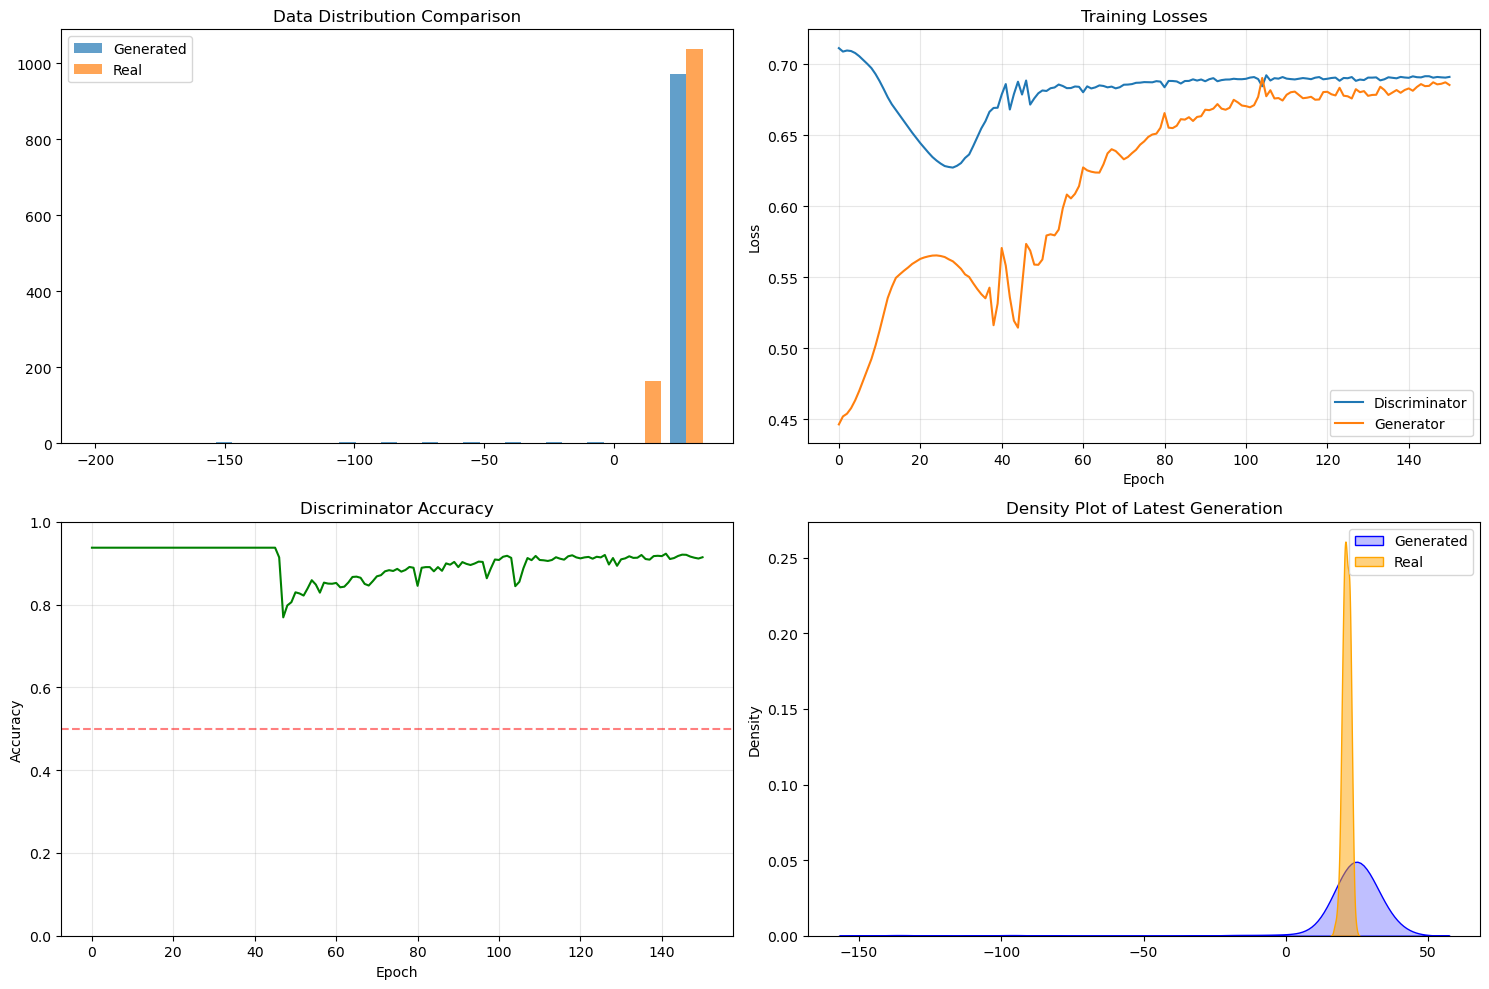

Epoch 151/500: D Loss: 0.6907, G Loss: 0.6847, D Accuracy: 0.9160
Epoch 152/500: D Loss: 0.6912, G Loss: 0.6832, D Accuracy: 0.9207
Epoch 153/500: D Loss: 0.6915, G Loss: 0.6830, D Accuracy: 0.9246
Epoch 154/500: D Loss: 0.6919, G Loss: 0.6836, D Accuracy: 0.9254
Epoch 155/500: D Loss: 0.6912, G Loss: 0.6867, D Accuracy: 0.9223
Epoch 156/500: D Loss: 0.6917, G Loss: 0.6858, D Accuracy: 0.9258
Epoch 157/500: D Loss: 0.6920, G Loss: 0.6857, D Accuracy: 0.9281
Epoch 158/500: D Loss: 0.6919, G Loss: 0.6867, D Accuracy: 0.9223
Epoch 159/500: D Loss: 0.6921, G Loss: 0.6876, D Accuracy: 0.9230
Epoch 160/500: D Loss: 0.6922, G Loss: 0.6885, D Accuracy: 0.9242


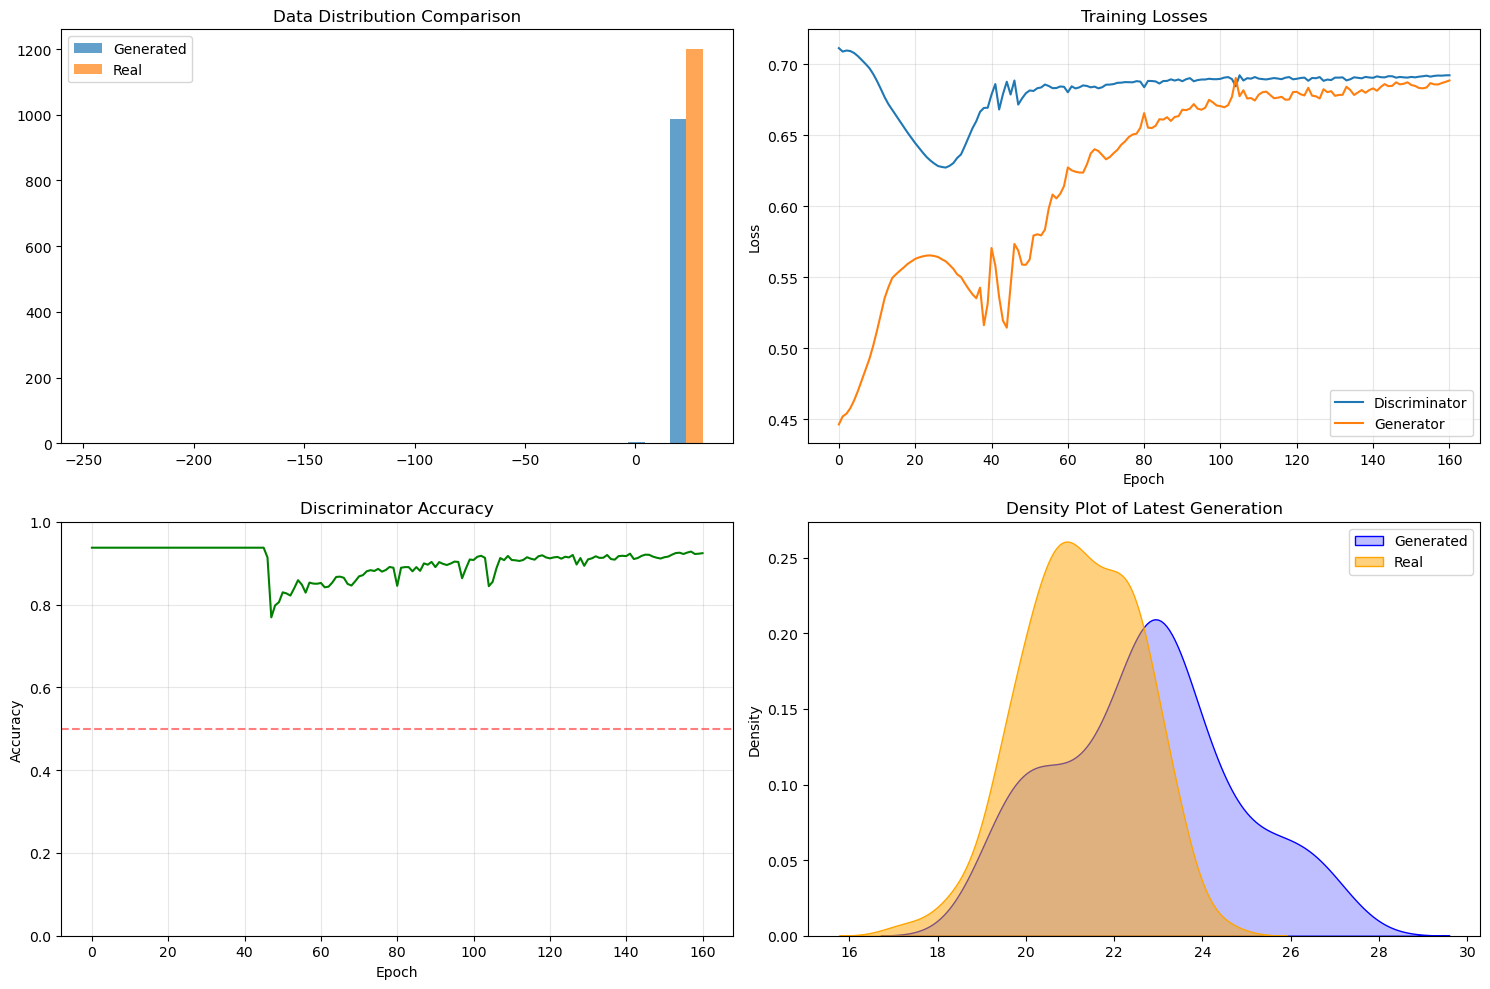

Epoch 161/500: D Loss: 0.6924, G Loss: 0.6888, D Accuracy: 0.9246
Epoch 162/500: D Loss: 0.6920, G Loss: 0.6905, D Accuracy: 0.9121
Epoch 163/500: D Loss: 0.6927, G Loss: 0.6895, D Accuracy: 0.9180
Epoch 164/500: D Loss: 0.6925, G Loss: 0.6903, D Accuracy: 0.9242
Epoch 165/500: D Loss: 0.6927, G Loss: 0.6900, D Accuracy: 0.9285
Epoch 166/500: D Loss: 0.6927, G Loss: 0.6905, D Accuracy: 0.9332
Epoch 167/500: D Loss: 0.6931, G Loss: 0.6903, D Accuracy: 0.9355
Epoch 168/500: D Loss: 0.6927, G Loss: 0.6920, D Accuracy: 0.9328
Epoch 169/500: D Loss: 0.6927, G Loss: 0.6919, D Accuracy: 0.9332
Epoch 170/500: D Loss: 0.6928, G Loss: 0.6916, D Accuracy: 0.9344


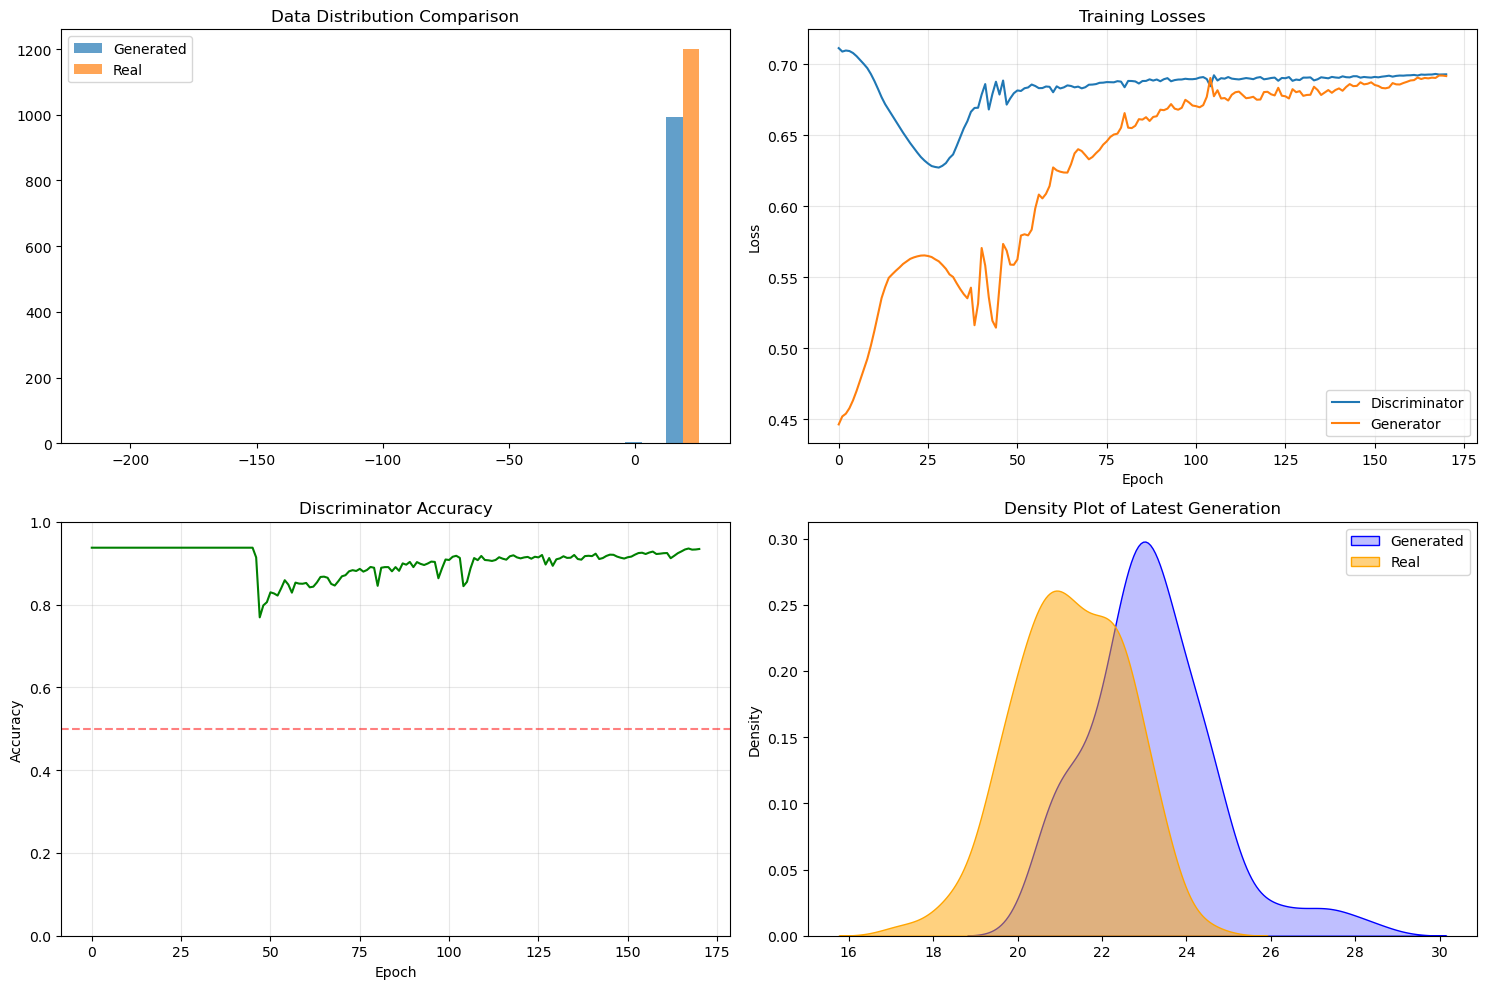

Epoch 171/500: D Loss: 0.6927, G Loss: 0.6920, D Accuracy: 0.9340
Epoch 172/500: D Loss: 0.6928, G Loss: 0.6916, D Accuracy: 0.9355
Epoch 173/500: D Loss: 0.6926, G Loss: 0.6921, D Accuracy: 0.9340
Epoch 174/500: D Loss: 0.6929, G Loss: 0.6911, D Accuracy: 0.9355
Epoch 175/500: D Loss: 0.6928, G Loss: 0.6916, D Accuracy: 0.9352
Epoch 176/500: D Loss: 0.6930, G Loss: 0.6912, D Accuracy: 0.9363
Epoch 177/500: D Loss: 0.6928, G Loss: 0.6920, D Accuracy: 0.9348
Epoch 178/500: D Loss: 0.6929, G Loss: 0.6921, D Accuracy: 0.9355
Epoch 179/500: D Loss: 0.6926, G Loss: 0.6925, D Accuracy: 0.9328
Epoch 180/500: D Loss: 0.6928, G Loss: 0.6915, D Accuracy: 0.9359


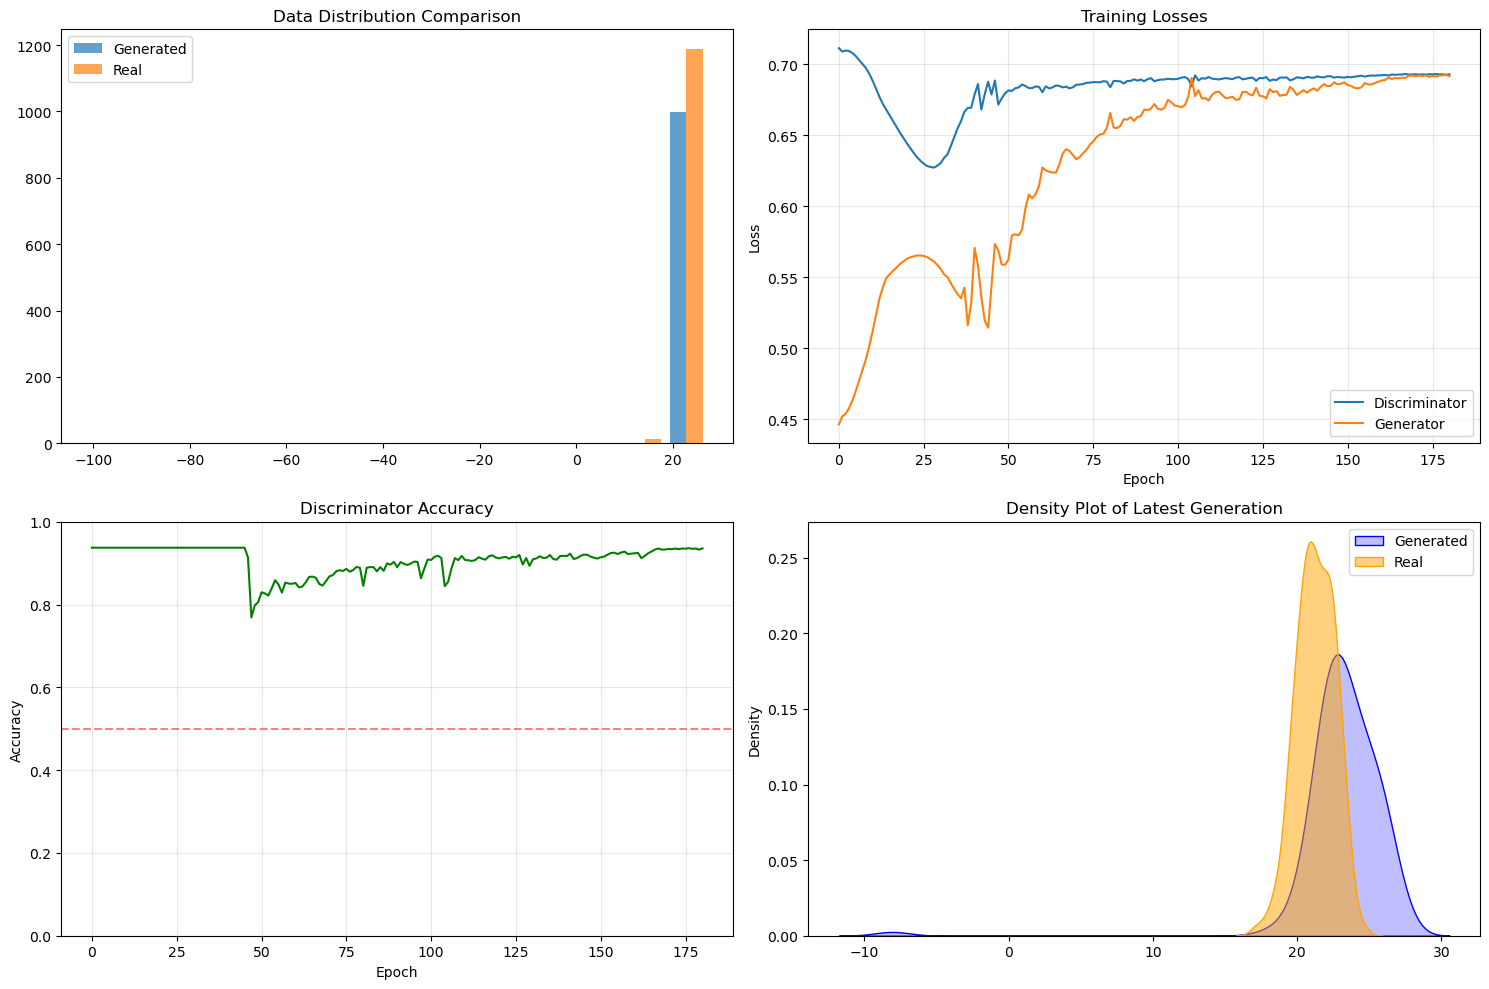

Epoch 181/500: D Loss: 0.6930, G Loss: 0.6912, D Accuracy: 0.9363
Epoch 182/500: D Loss: 0.6929, G Loss: 0.6918, D Accuracy: 0.9352
Epoch 183/500: D Loss: 0.6929, G Loss: 0.6922, D Accuracy: 0.9348
Epoch 184/500: D Loss: 0.6931, G Loss: 0.6919, D Accuracy: 0.9367
Epoch 185/500: D Loss: 0.6931, G Loss: 0.6923, D Accuracy: 0.9371
Epoch 186/500: D Loss: 0.6931, G Loss: 0.6928, D Accuracy: 0.9367
Epoch 187/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9367
Epoch 188/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9363
Epoch 189/500: D Loss: 0.6931, G Loss: 0.6930, D Accuracy: 0.9371
Epoch 190/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9367


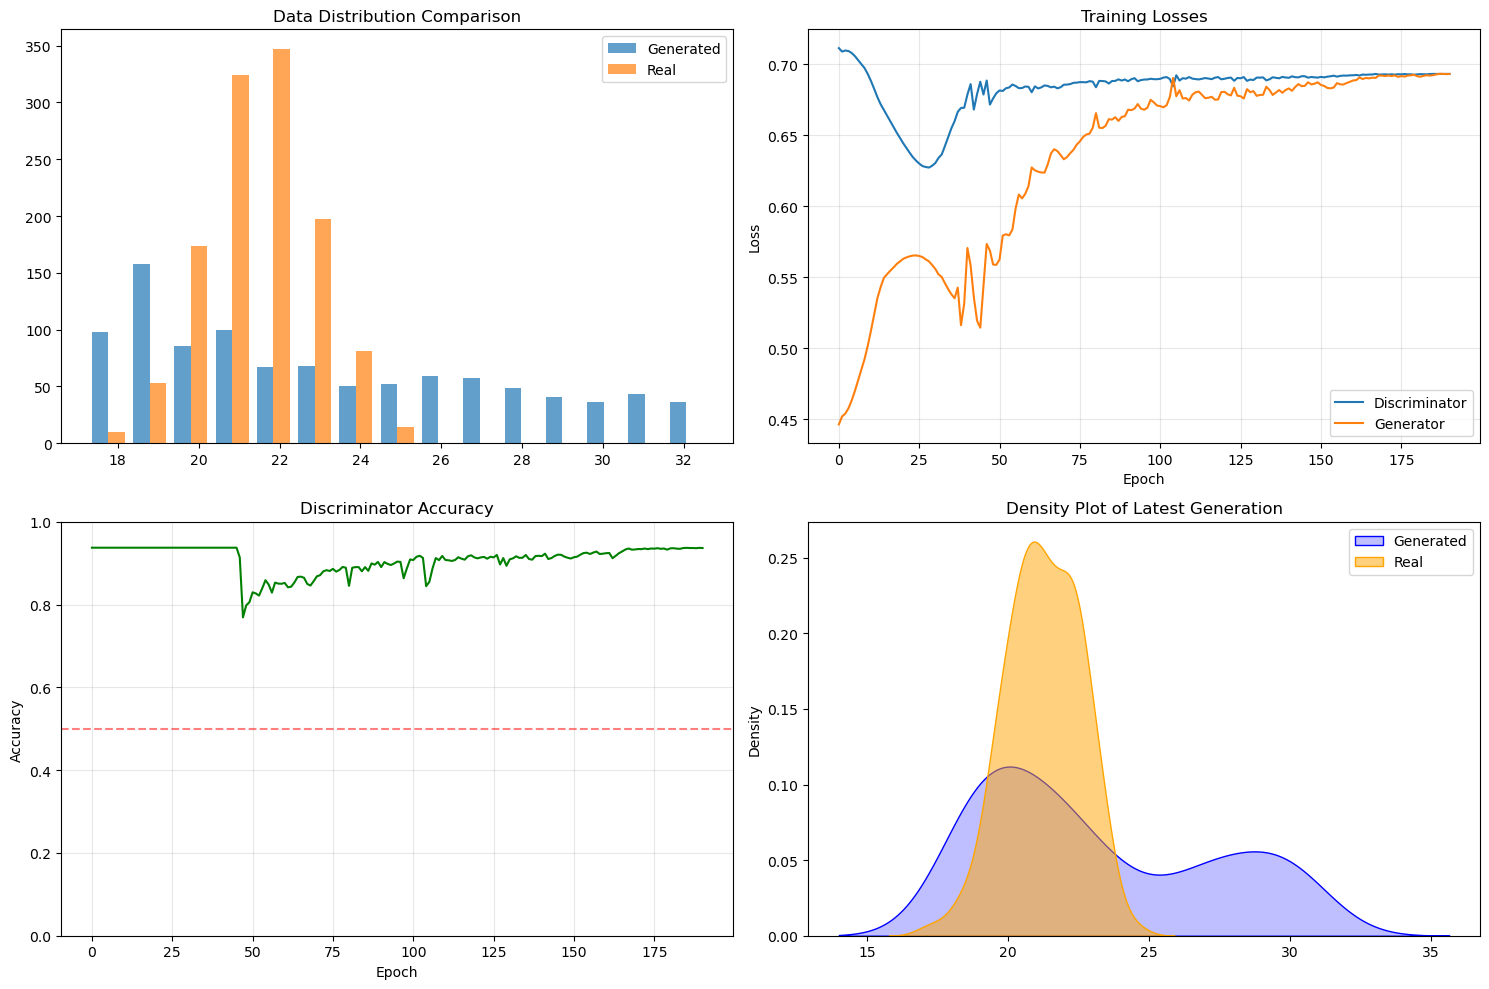

Epoch 191/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9352
Epoch 192/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 193/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.1996
Epoch 194/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.0000
Epoch 195/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.0000
Epoch 196/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.0000
Epoch 197/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.1375
Epoch 198/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 199/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 200/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


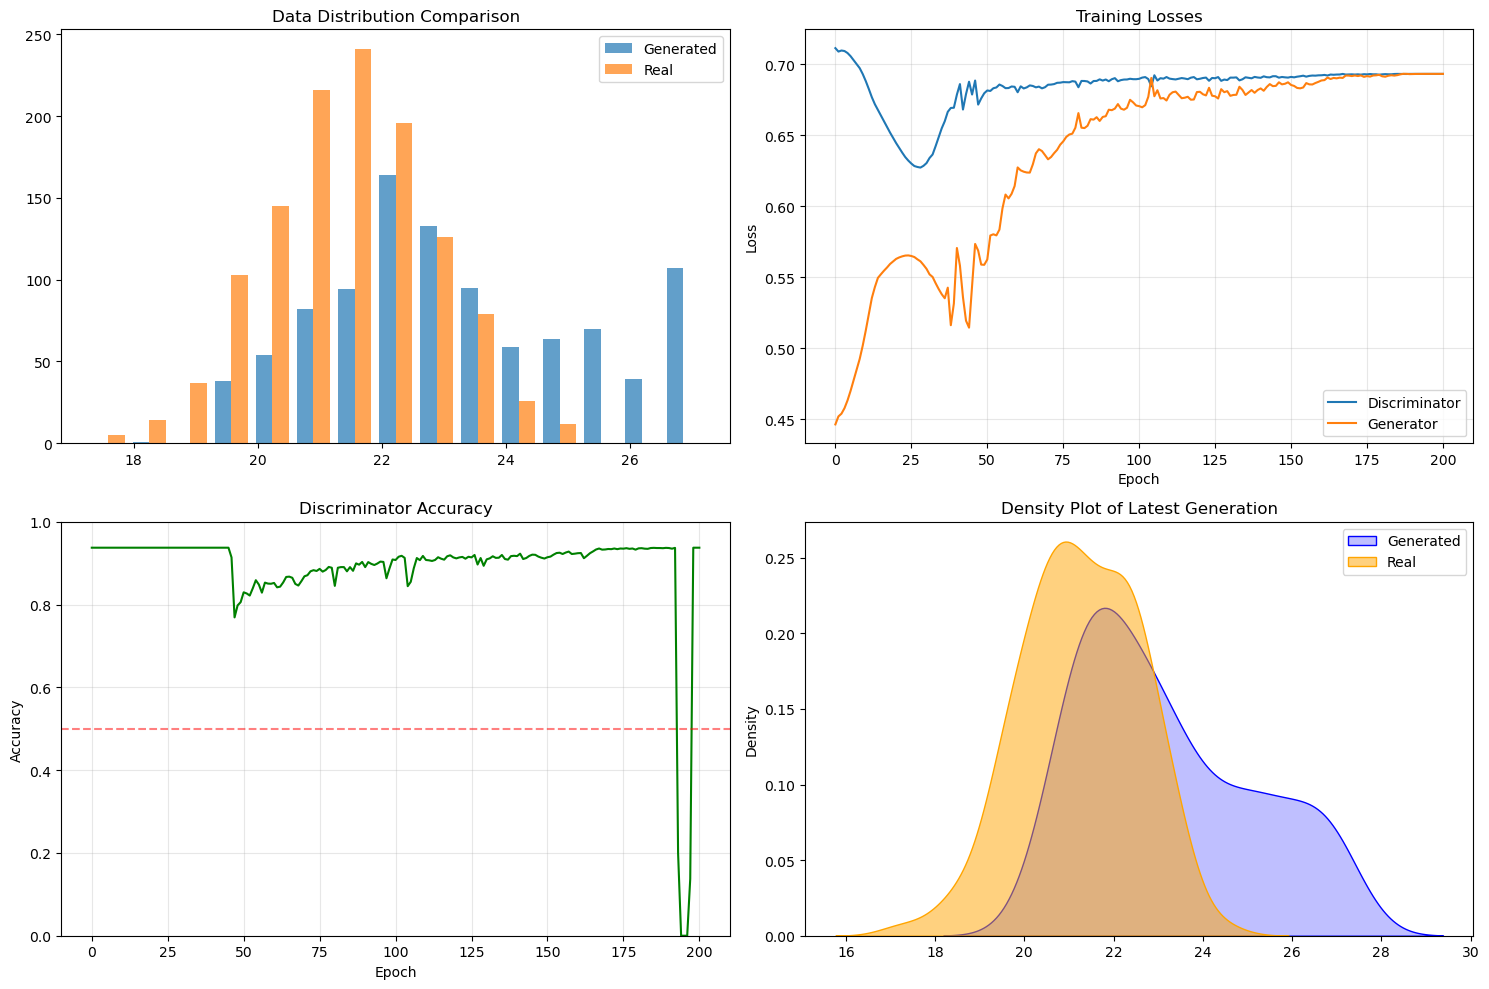

Epoch 201/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 202/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 203/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 204/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 205/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 206/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 207/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 208/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 209/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 210/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


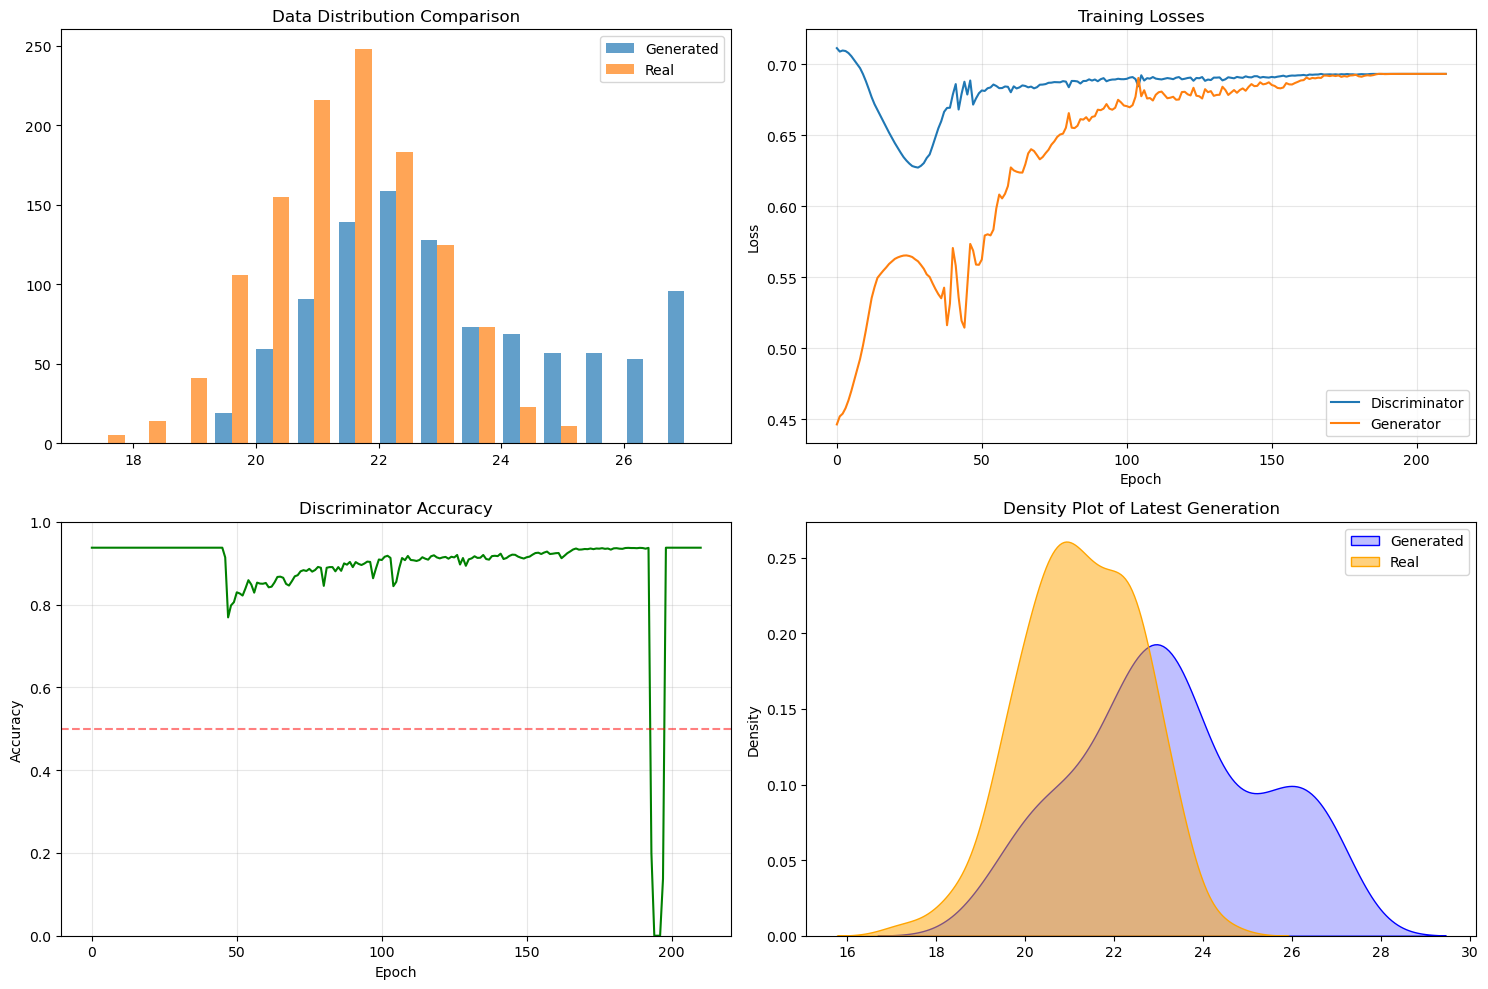

Epoch 211/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 212/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 213/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 214/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9371
Epoch 215/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 216/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9367
Epoch 217/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 218/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 219/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.7000
Epoch 220/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000


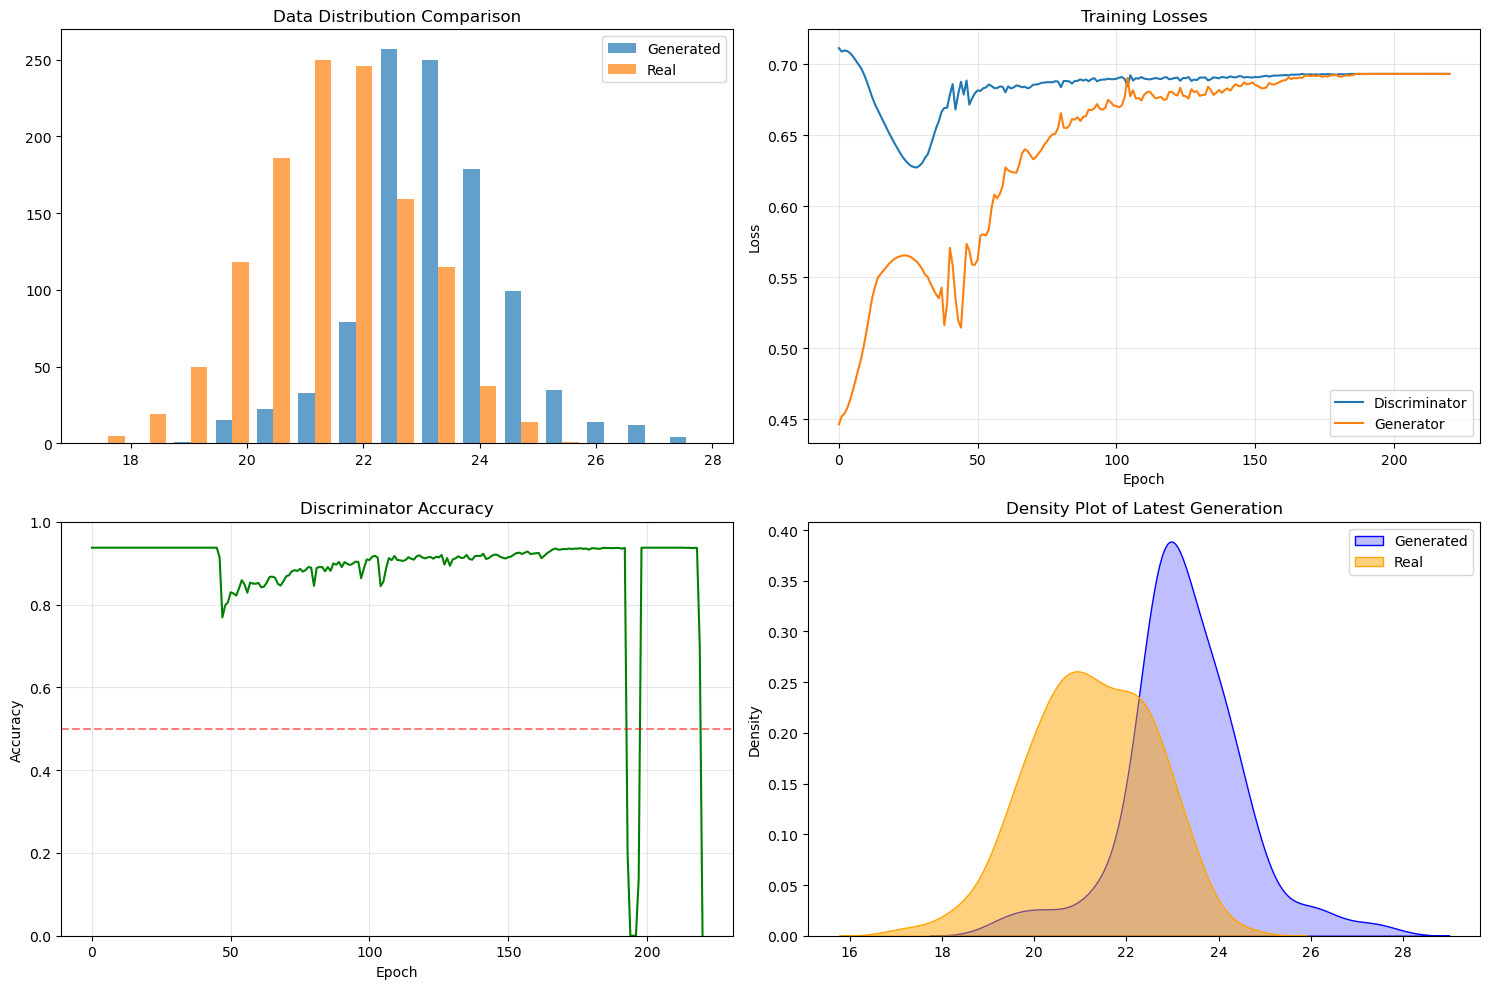

Epoch 221/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 222/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 223/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0375
Epoch 224/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 225/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 226/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 227/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 228/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 229/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 230/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


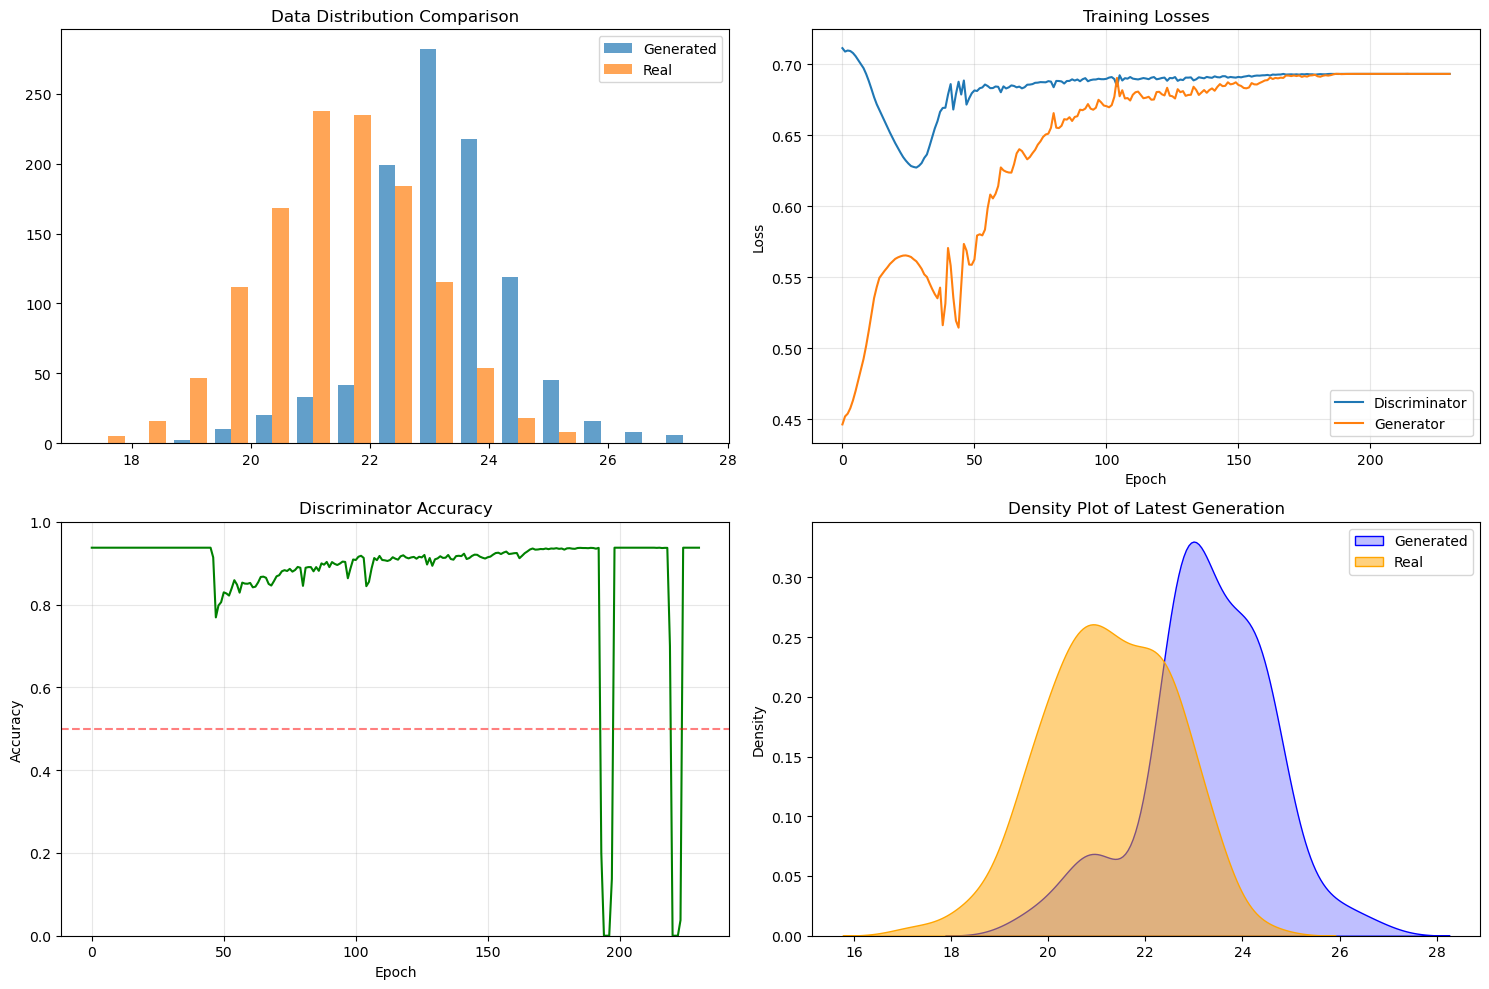

Epoch 231/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 232/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 233/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 234/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 235/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 236/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 237/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 238/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 239/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 240/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


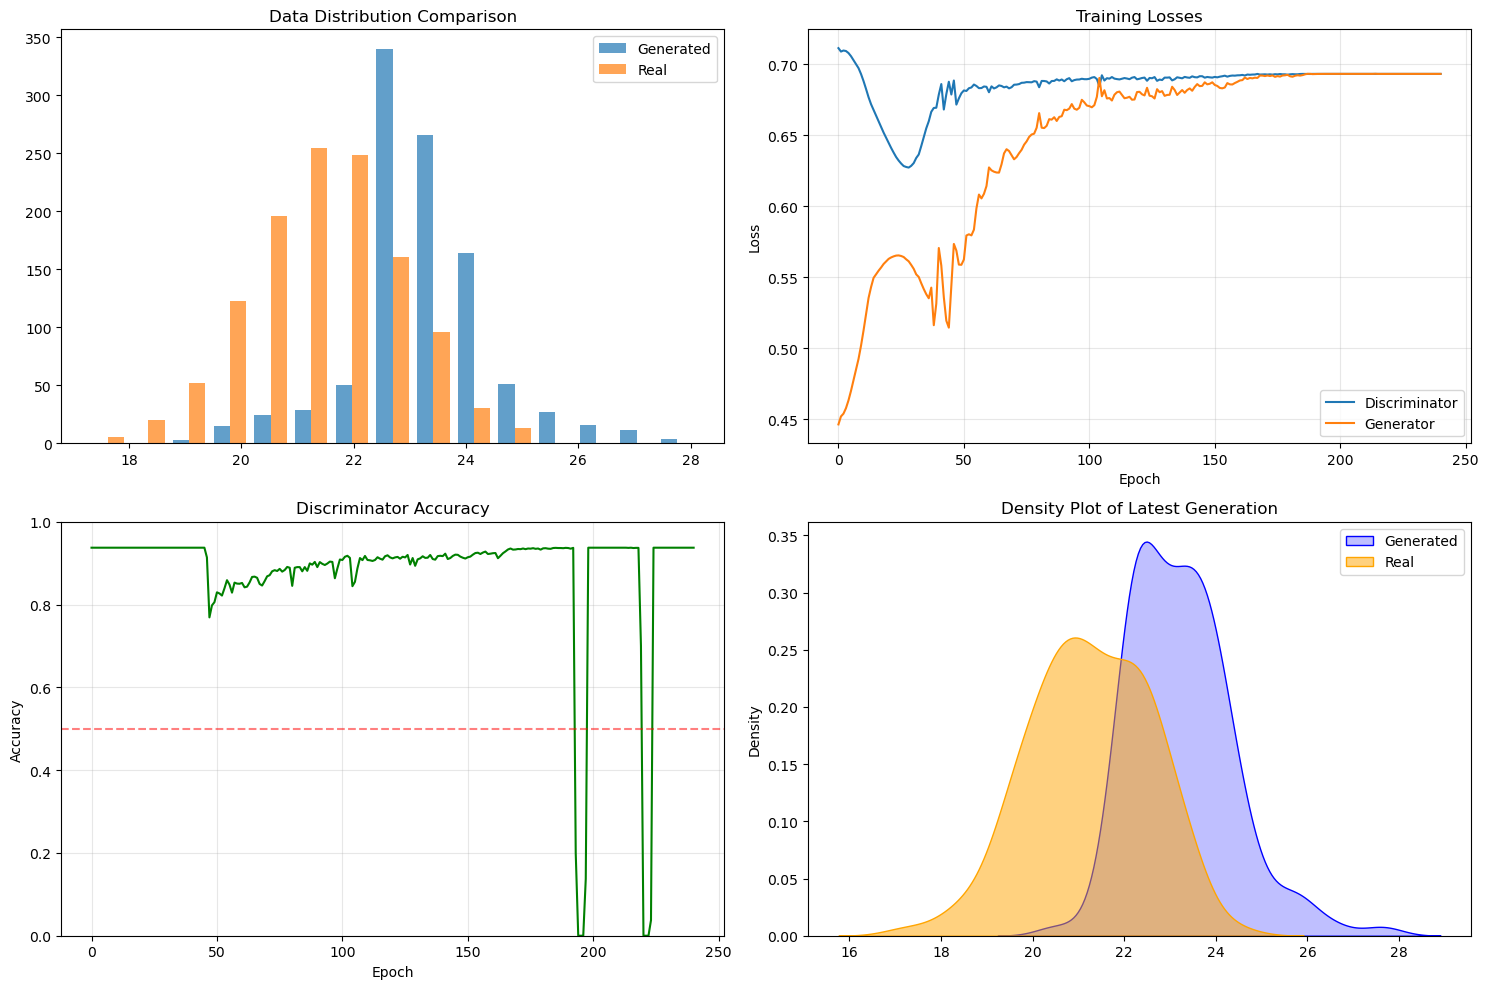

Epoch 241/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 242/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 243/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 244/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 245/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 246/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 247/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 248/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 249/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 250/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


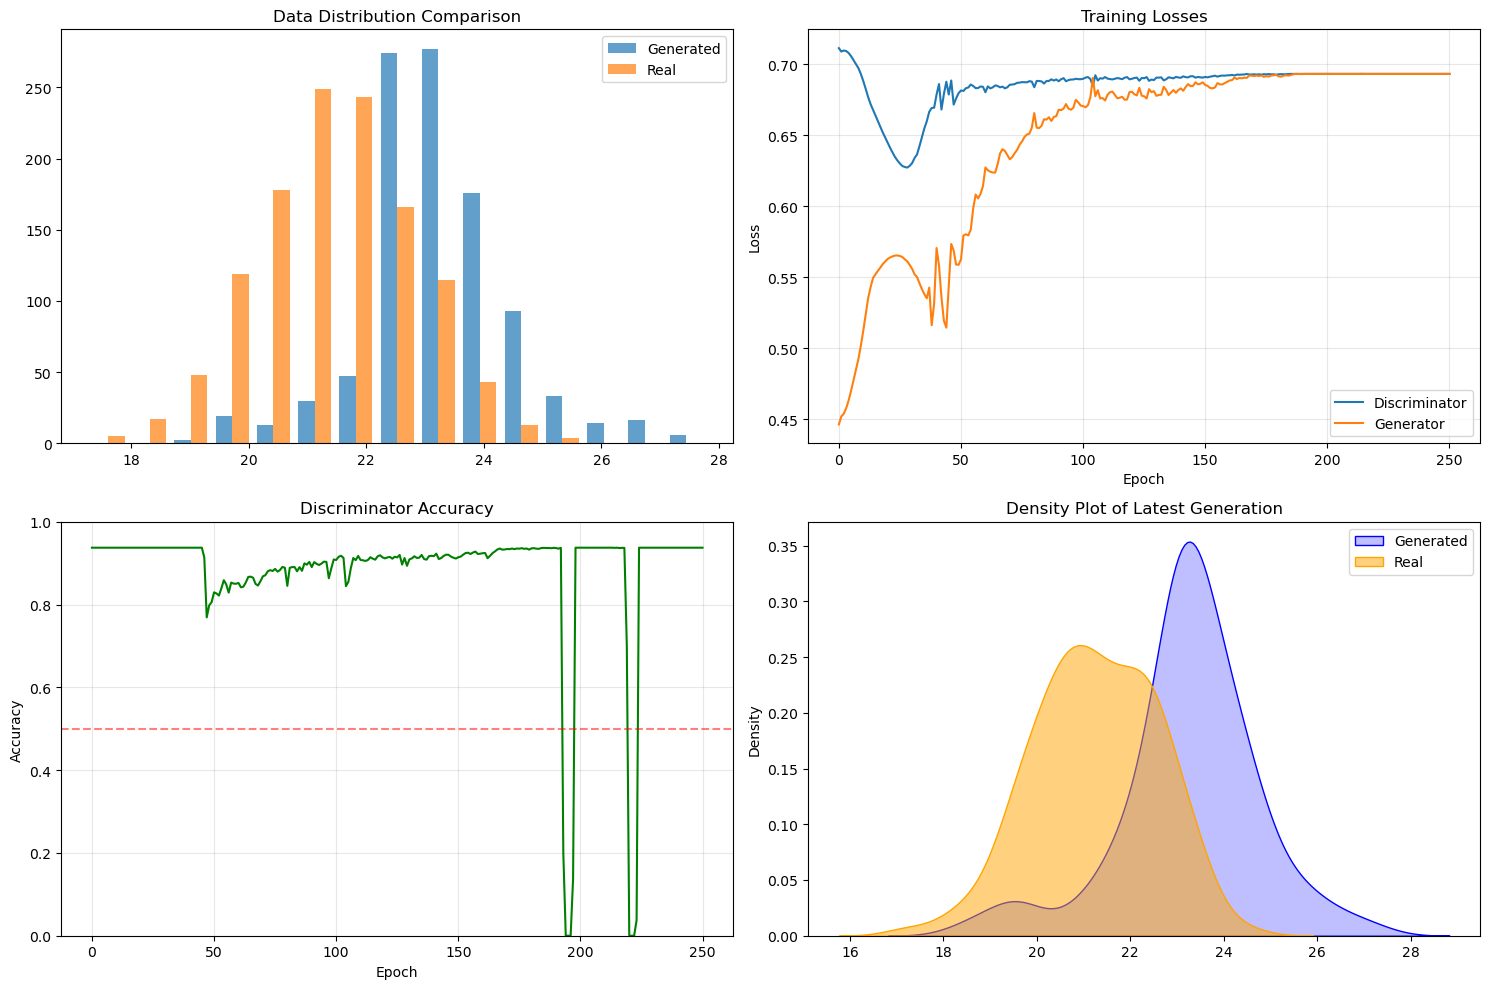

Epoch 251/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 252/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 253/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9371
Epoch 254/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 255/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 256/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 257/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9367
Epoch 258/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9371
Epoch 259/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 260/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9000


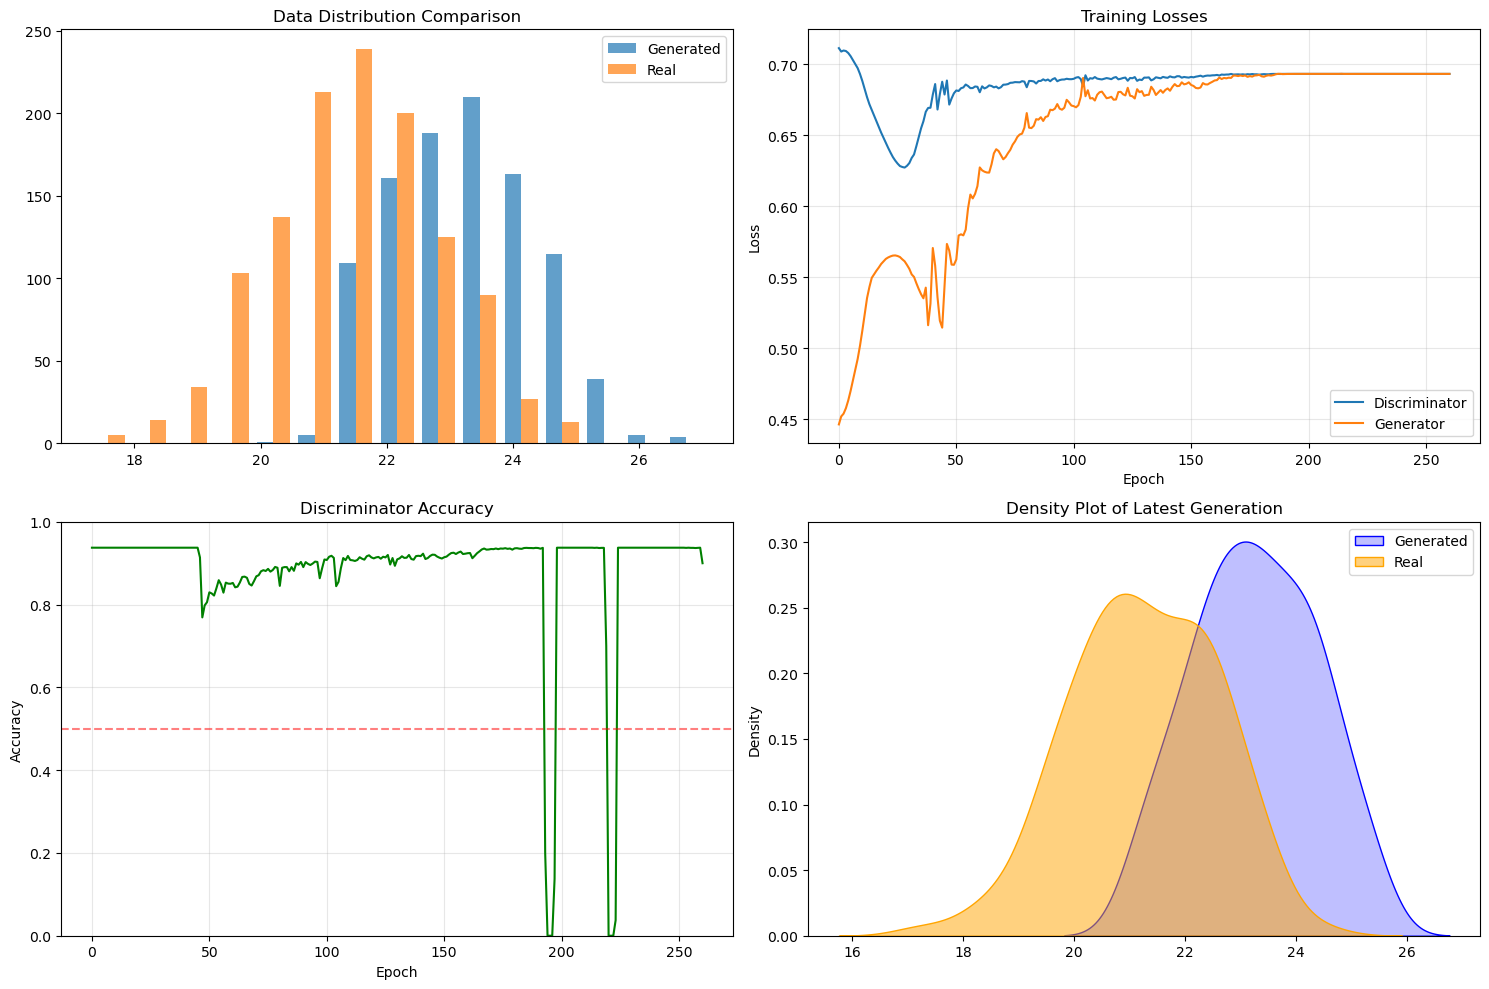

Epoch 261/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 262/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 263/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 264/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.5375
Epoch 265/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 266/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 267/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 268/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 269/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 270/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


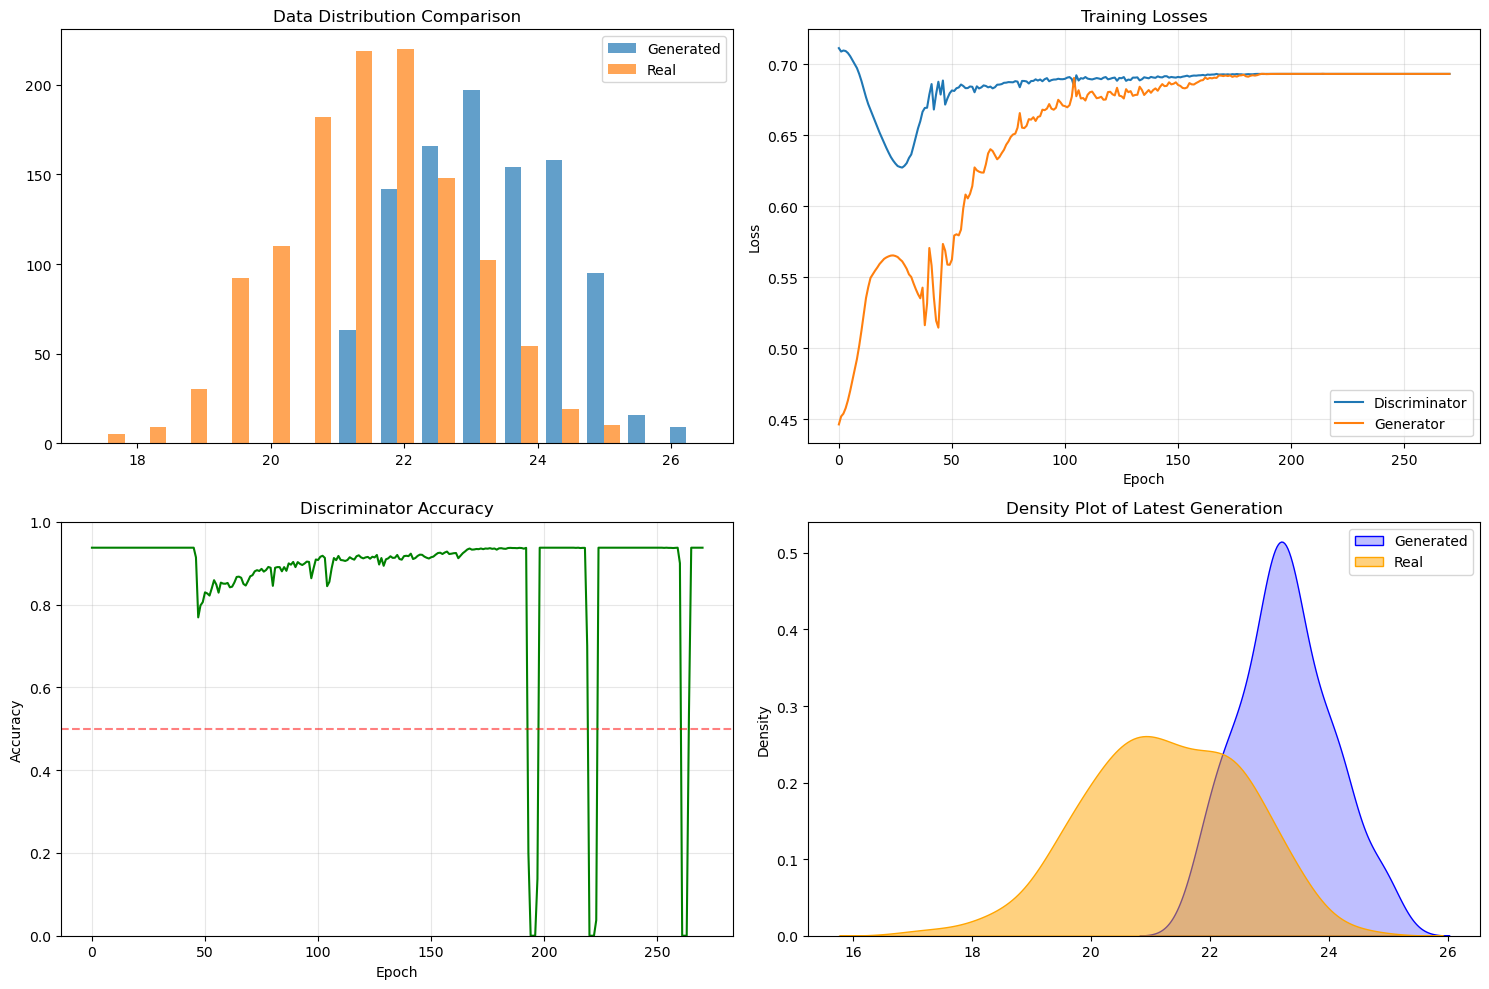

Epoch 271/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 272/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 273/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 274/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 275/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 276/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 277/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 278/500: D Loss: 0.6931, G Loss: 0.6932, D Accuracy: 0.9371
Epoch 279/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 280/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


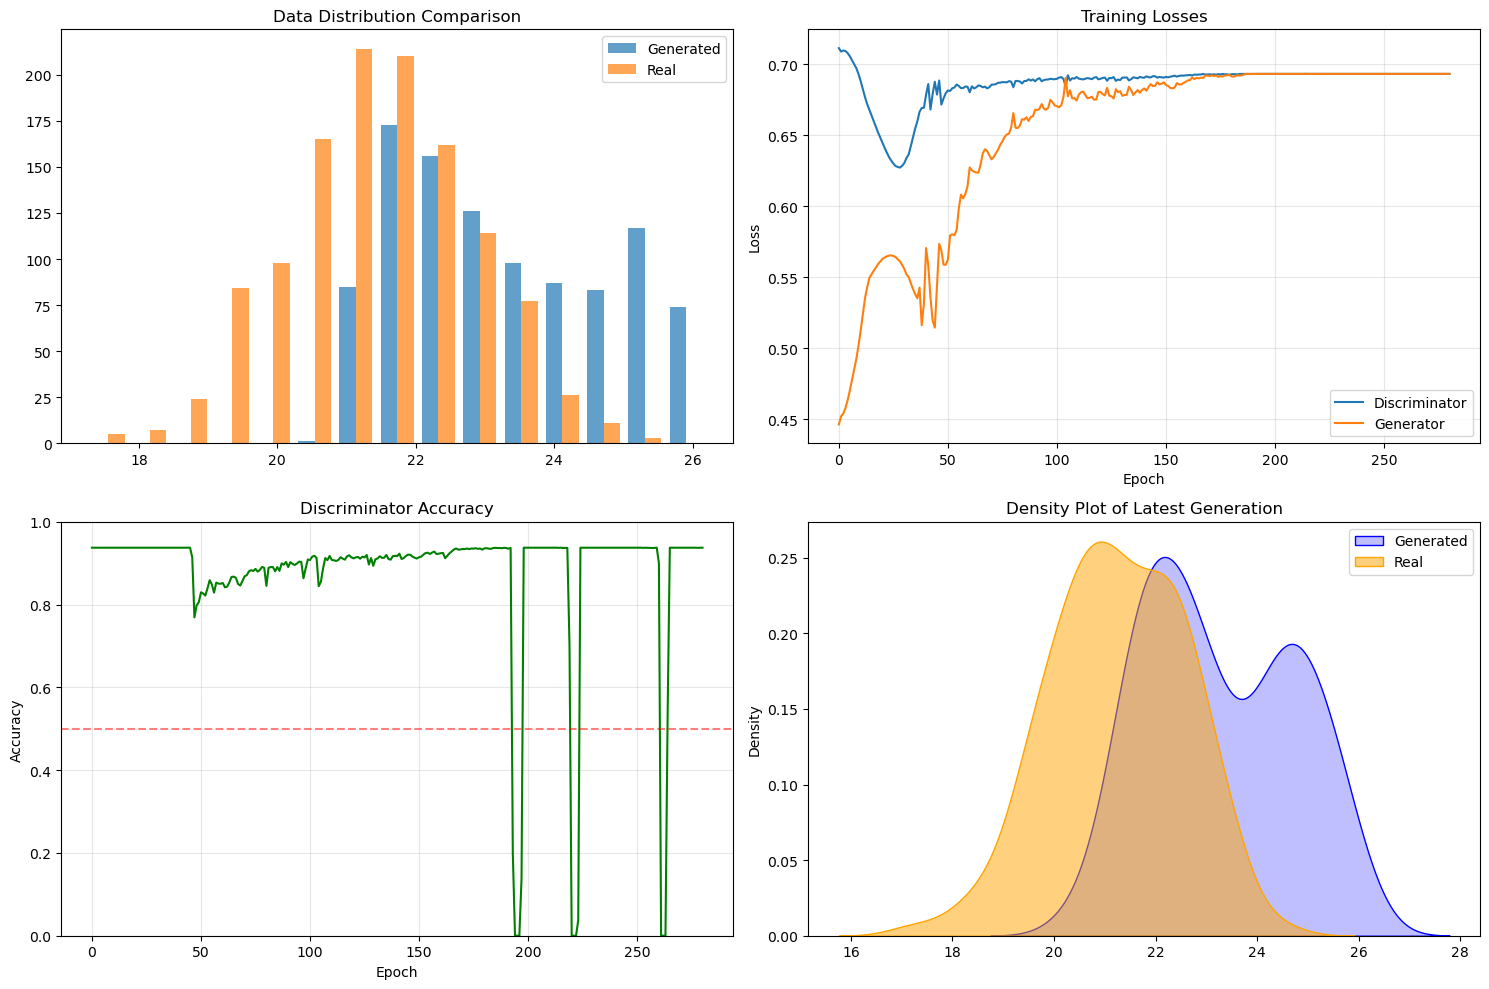

Epoch 281/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.7000
Epoch 282/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 283/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.0000
Epoch 284/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.1375
Epoch 285/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 286/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 287/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 288/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 289/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 290/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


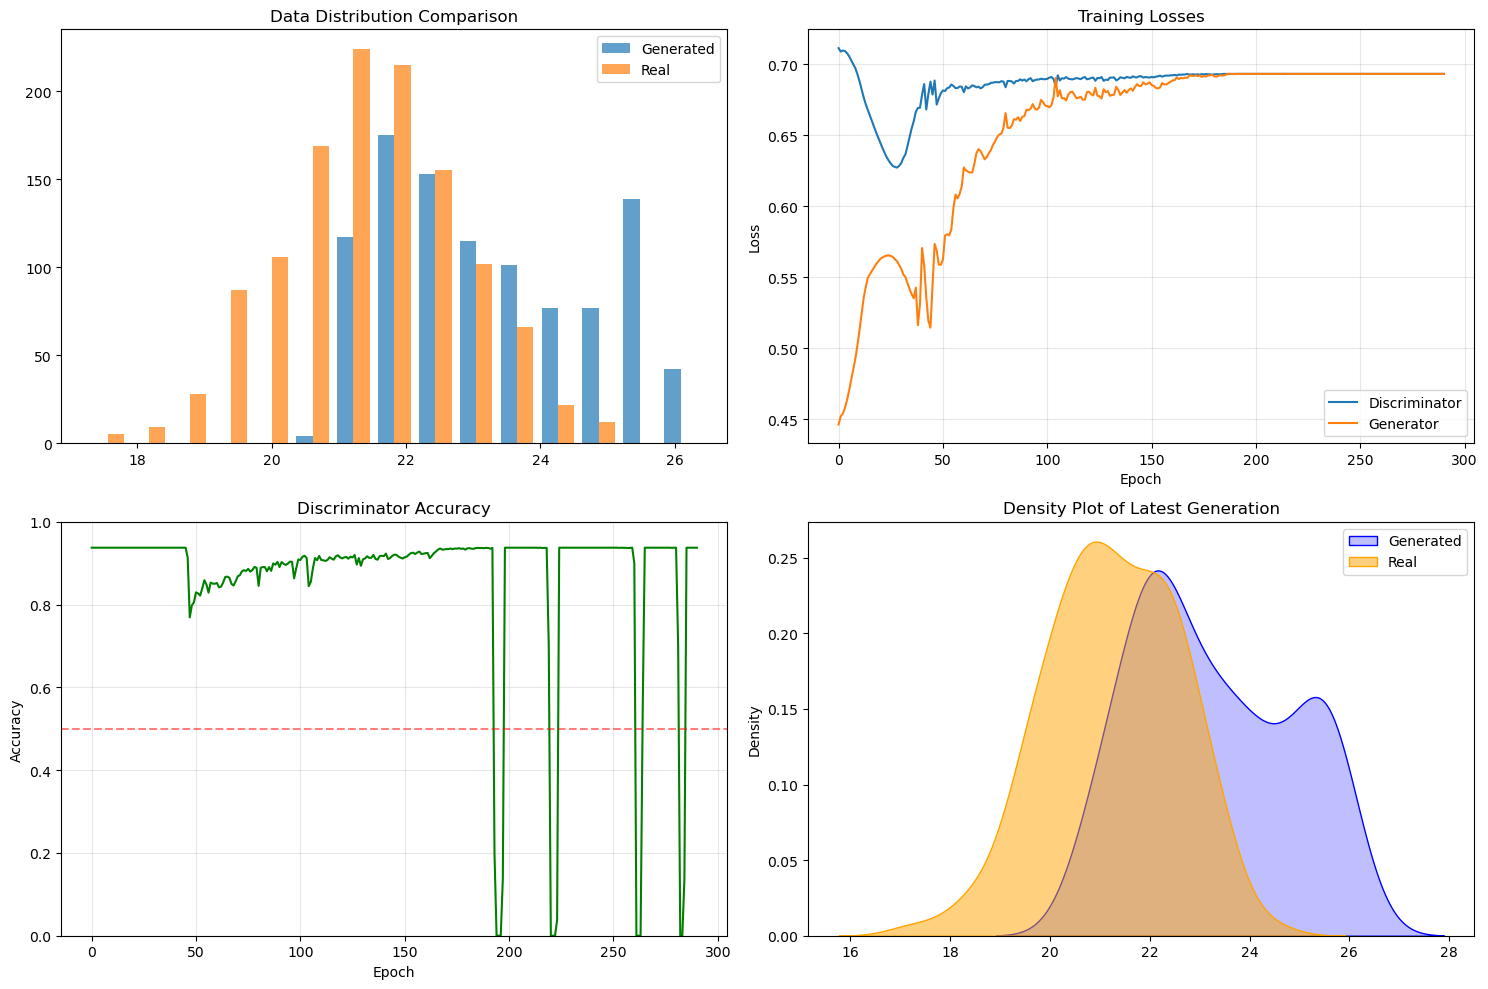

Epoch 291/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 292/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 293/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 294/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 295/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 296/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 297/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 298/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 299/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 300/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


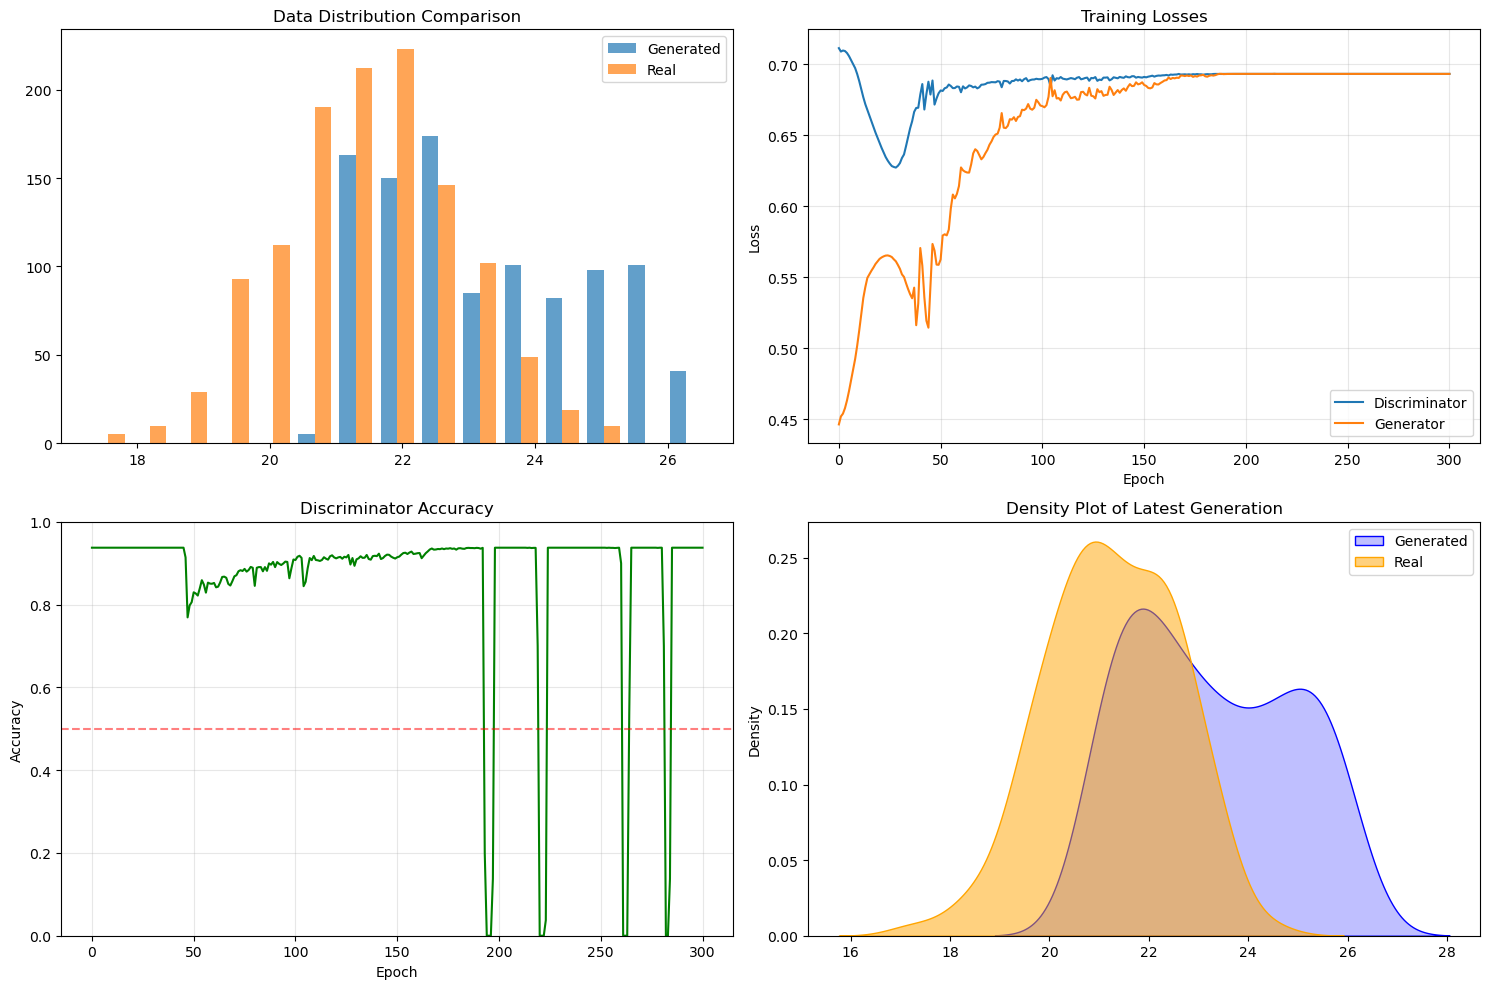

Epoch 301/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 302/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 303/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 304/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 305/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 306/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 307/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 308/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 309/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 310/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


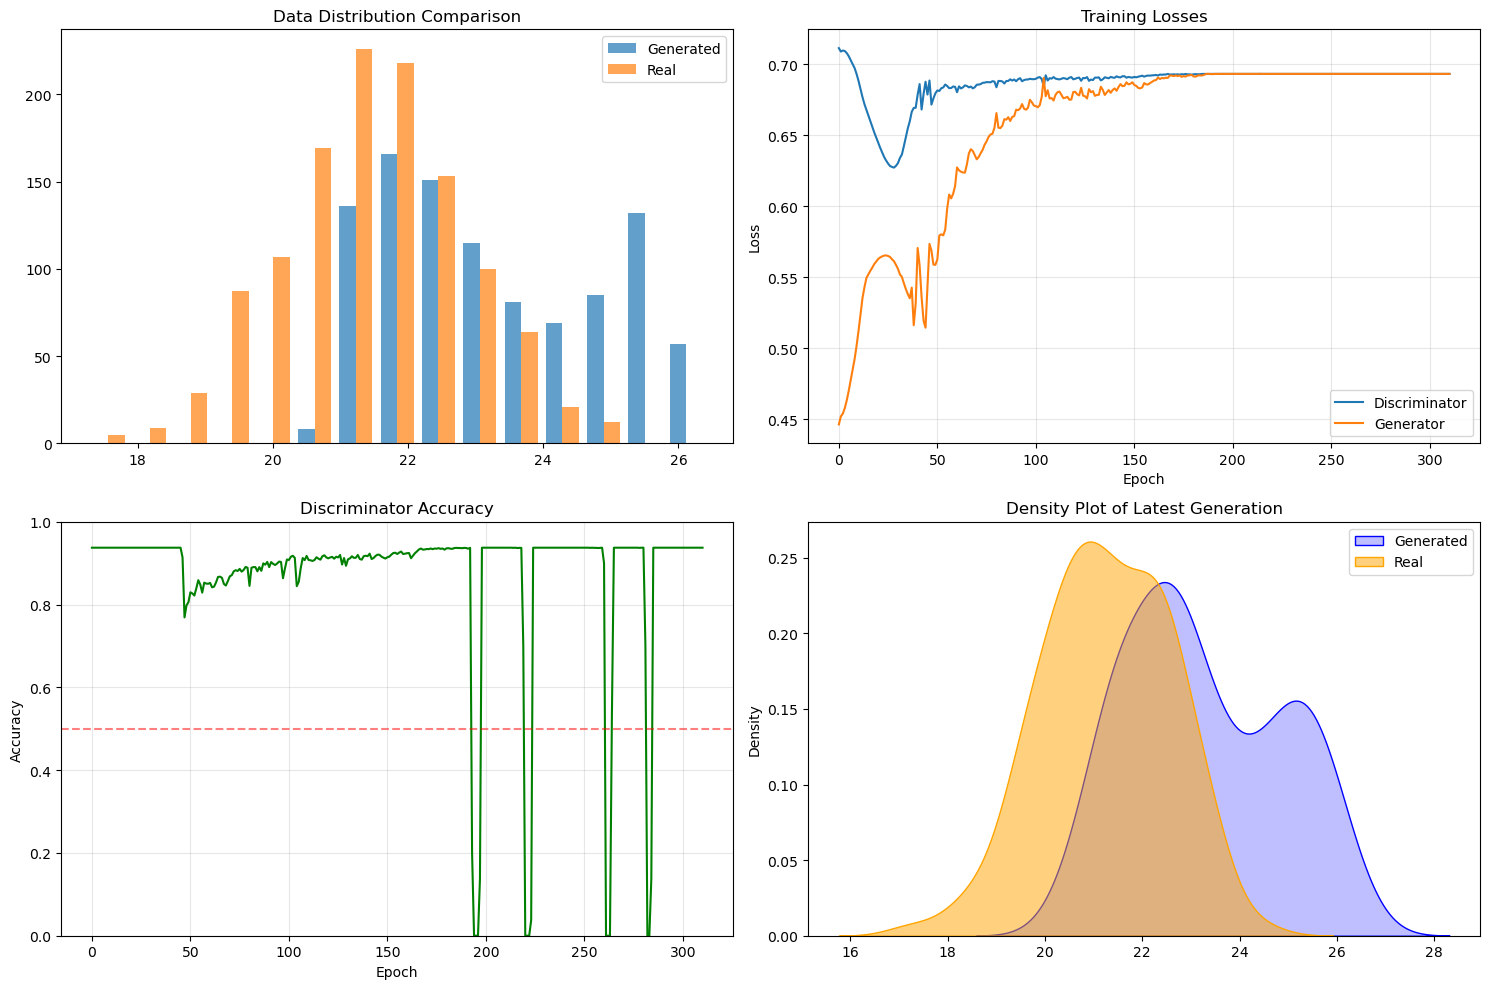

Epoch 311/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 312/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 313/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 314/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 315/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 316/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 317/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 318/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 319/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 320/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


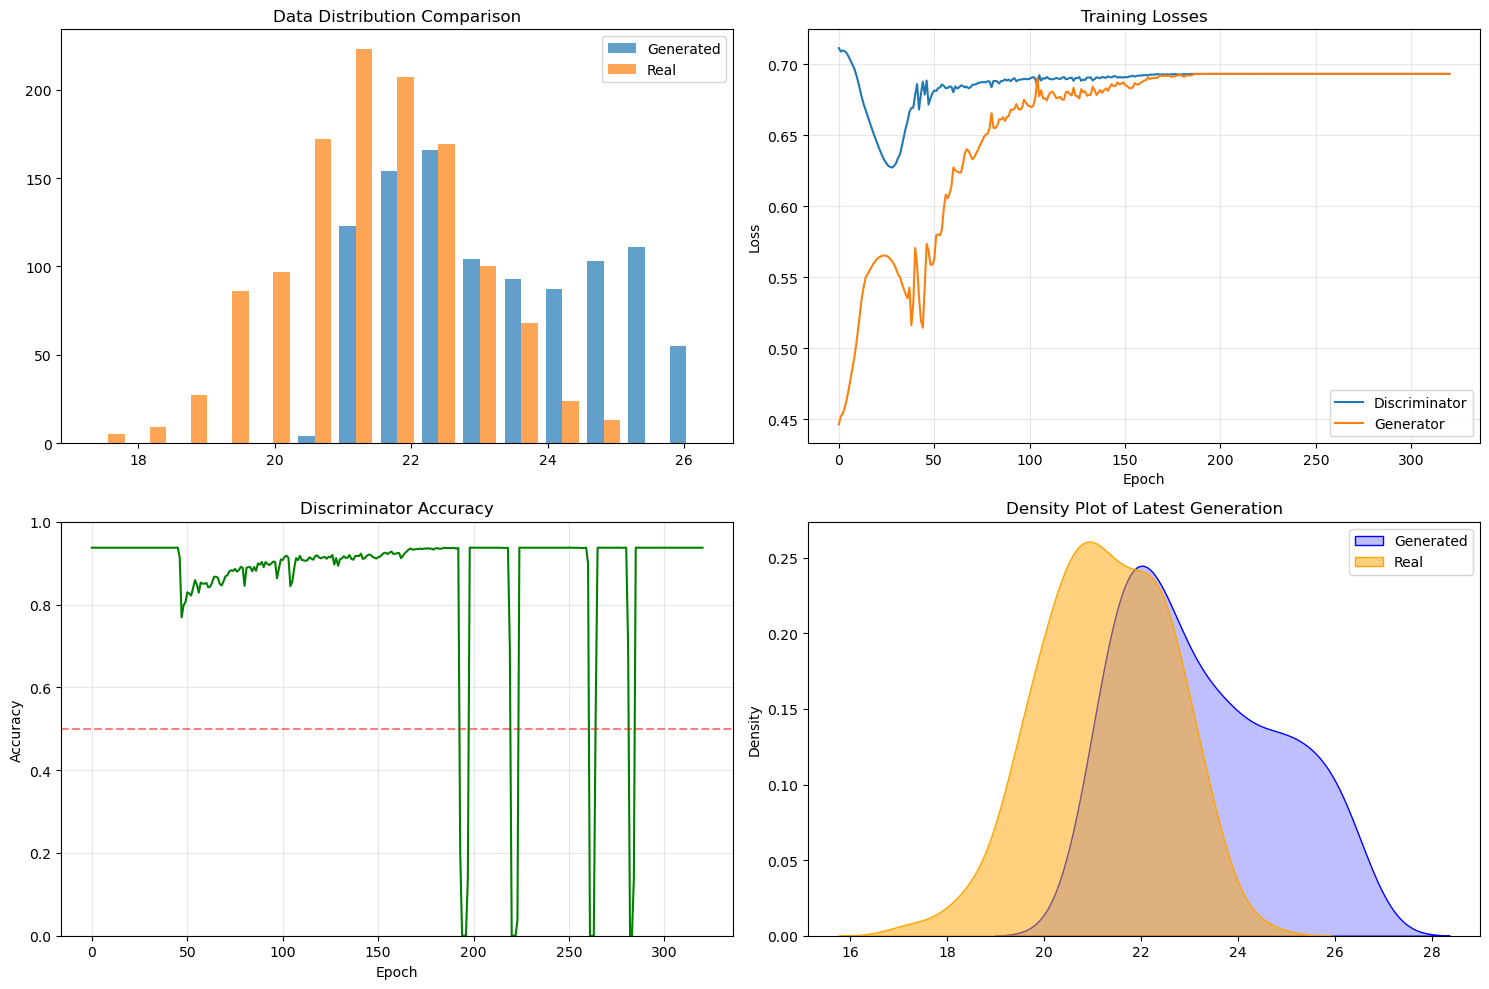

Epoch 321/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 322/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 323/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 324/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 325/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 326/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 327/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 328/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 329/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 330/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


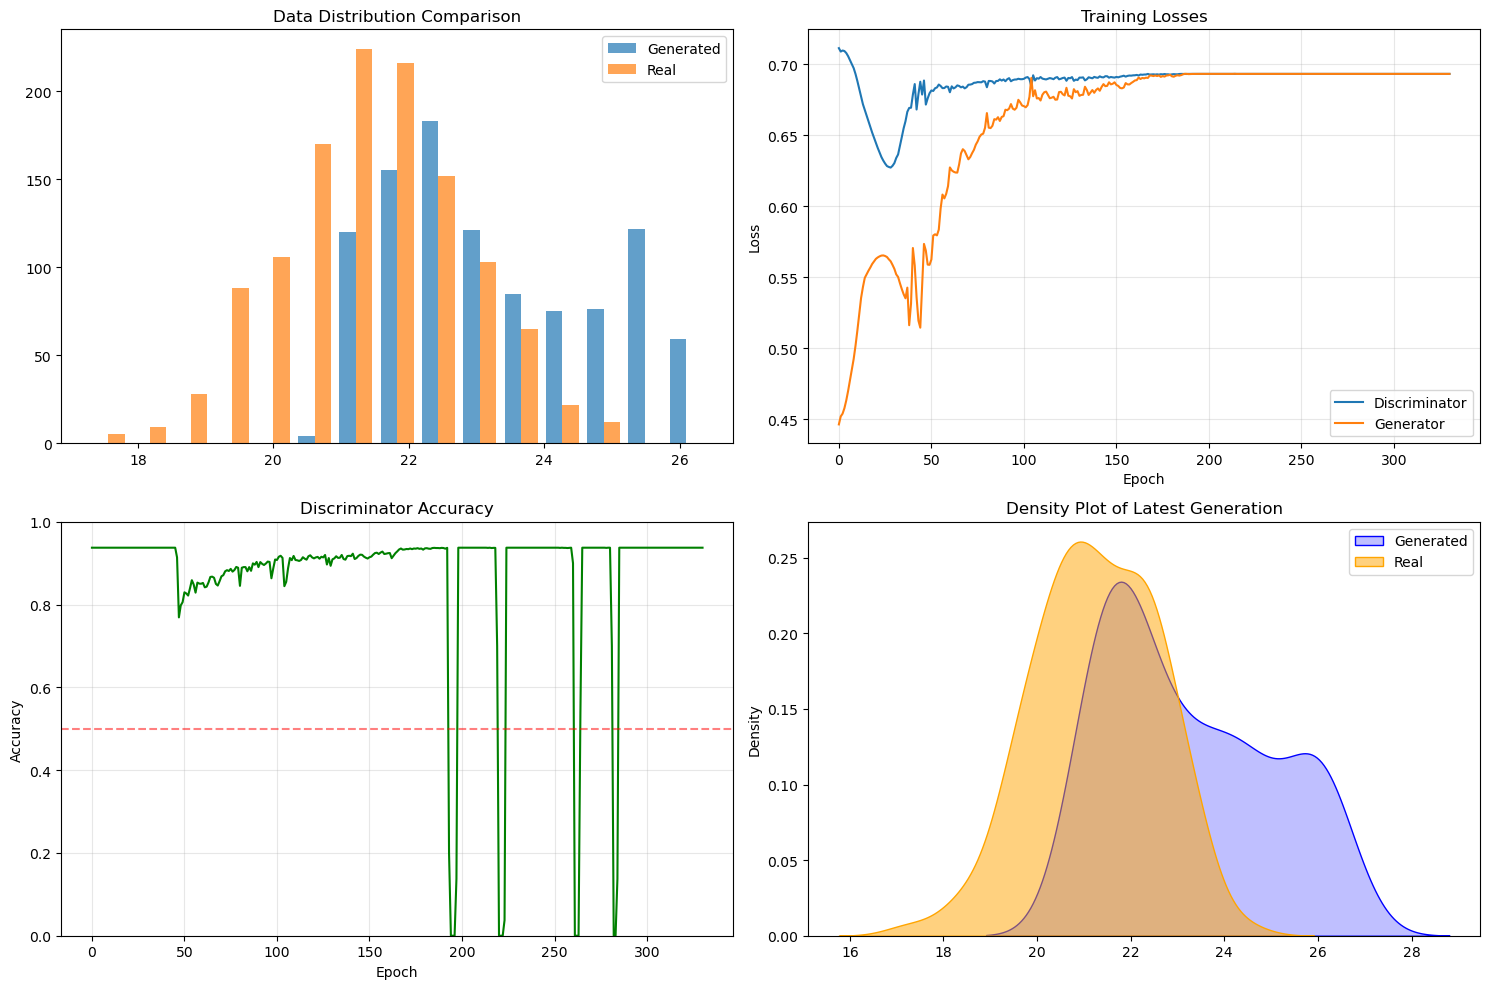

Epoch 331/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 332/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 333/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 334/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 335/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 336/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 337/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 338/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 339/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 340/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


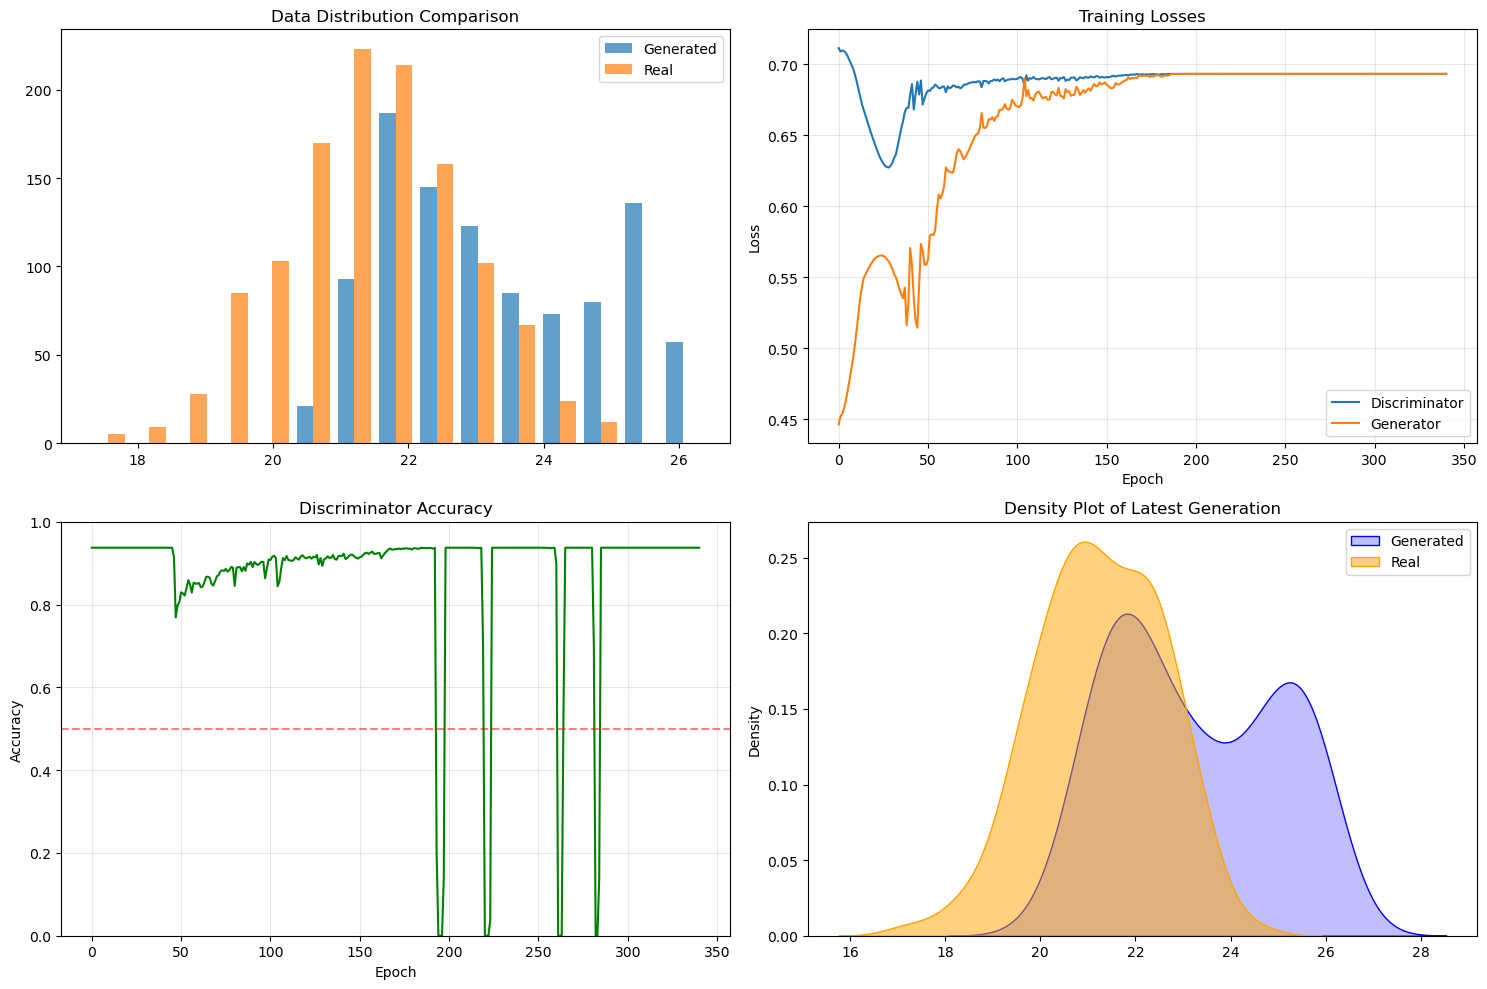

Epoch 341/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 342/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 343/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 344/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 345/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 346/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 347/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 348/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 349/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 350/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


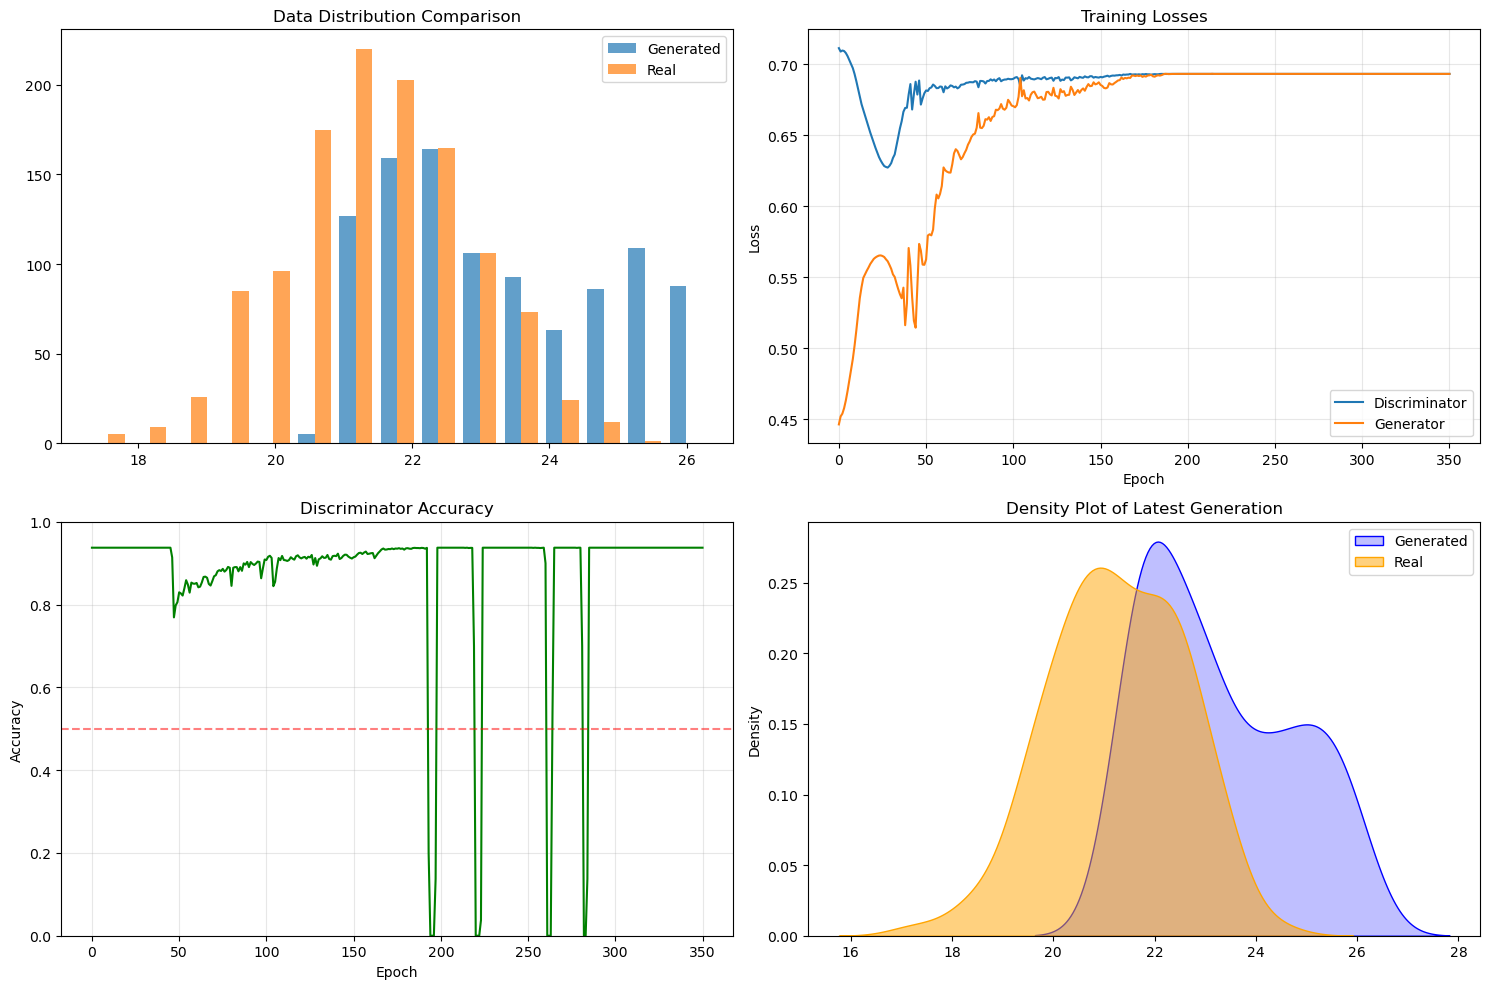

Epoch 351/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 352/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 353/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 354/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 355/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 356/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 357/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 358/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 359/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 360/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


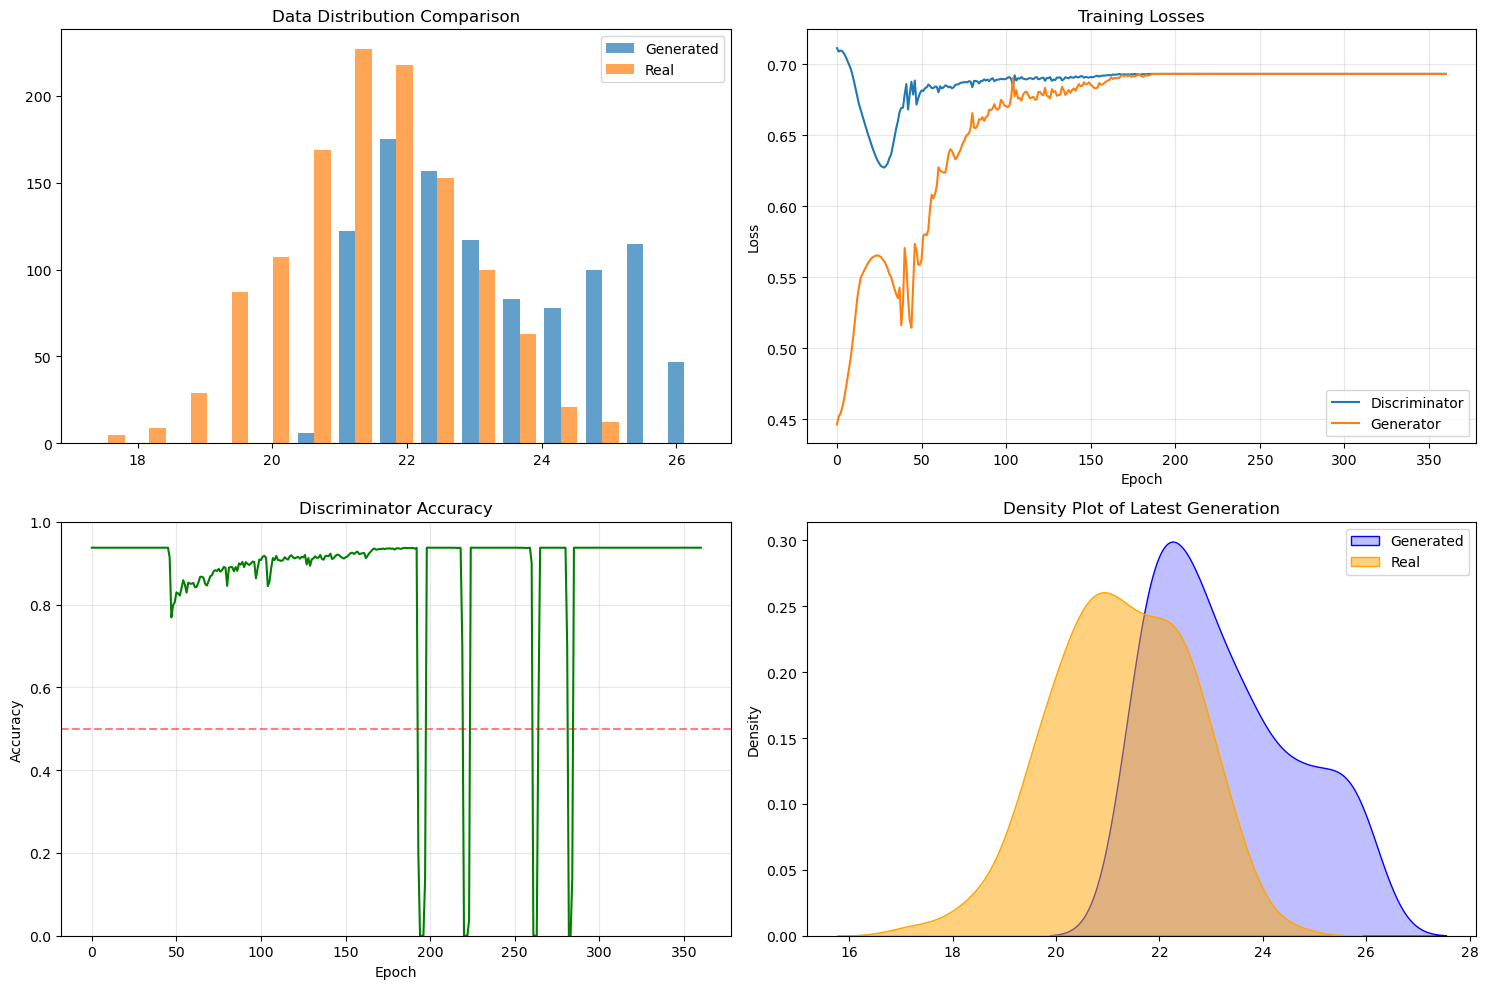

Epoch 361/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 362/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 363/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 364/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 365/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 366/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 367/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 368/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 369/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 370/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


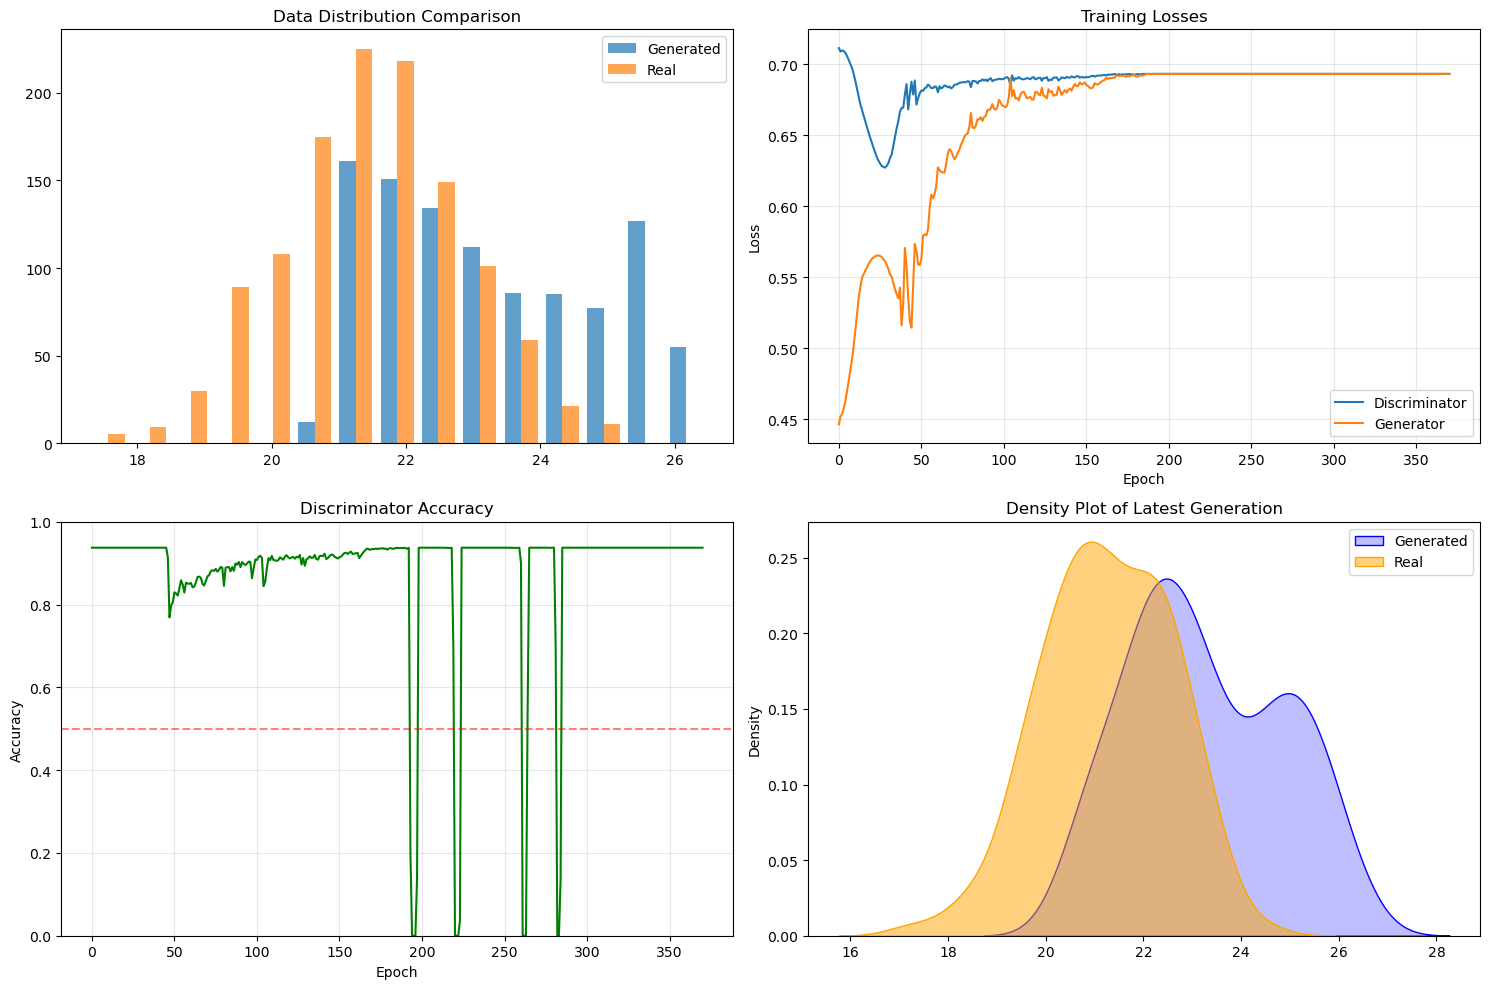

Epoch 371/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 372/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 373/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 374/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 375/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 376/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 377/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 378/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 379/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 380/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


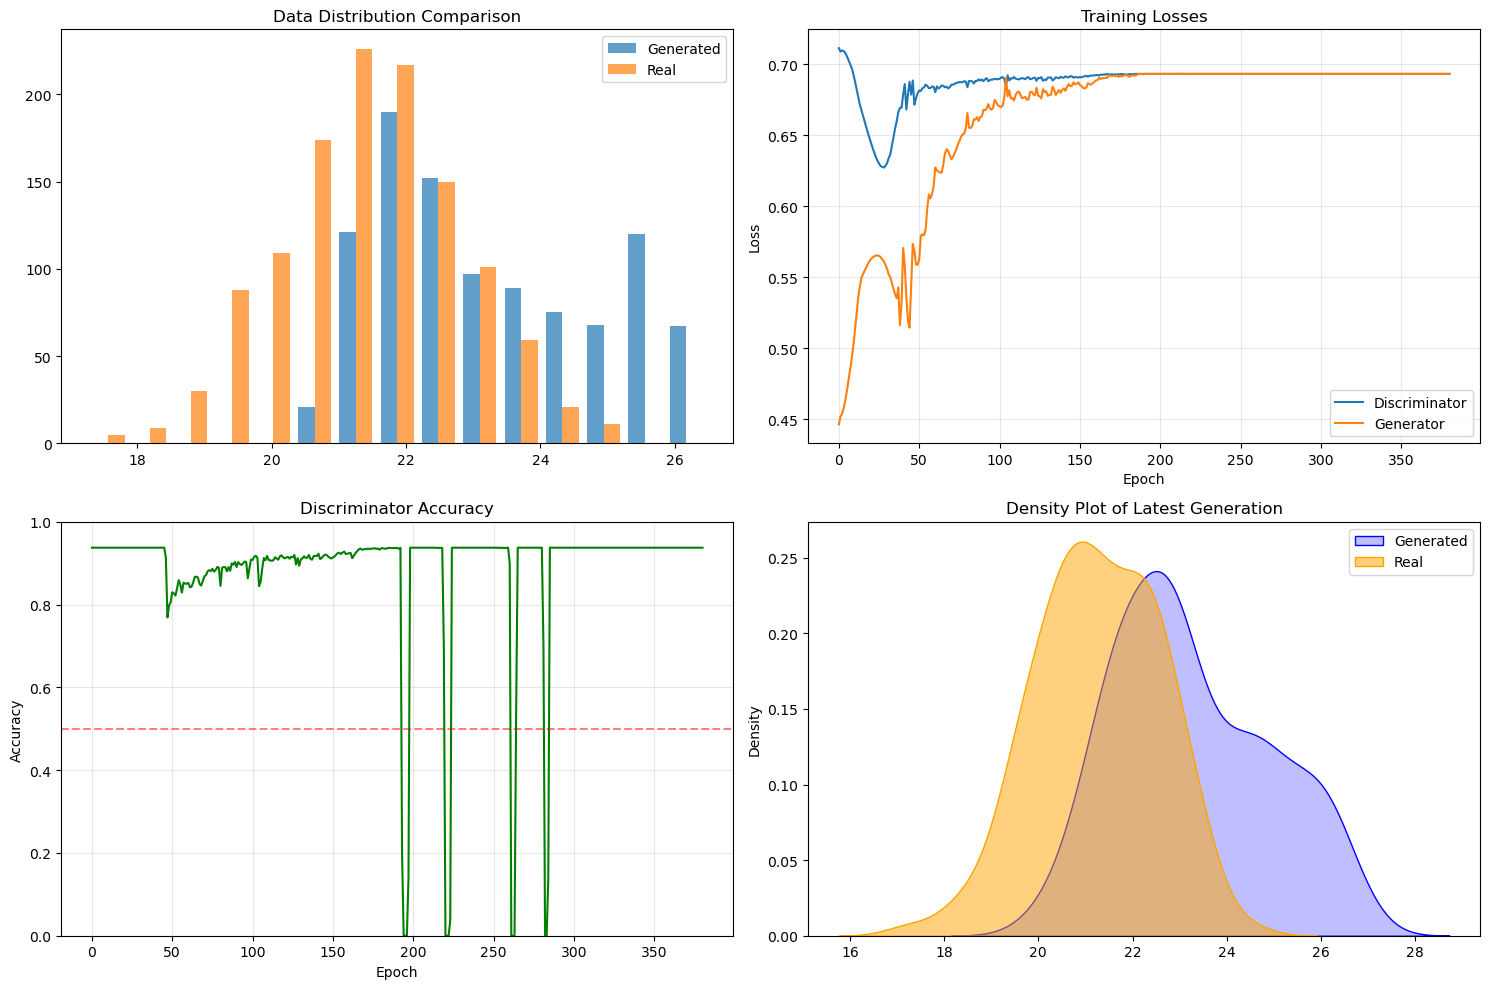

Epoch 381/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 382/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 383/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 384/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 385/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 386/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 387/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 388/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 389/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 390/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


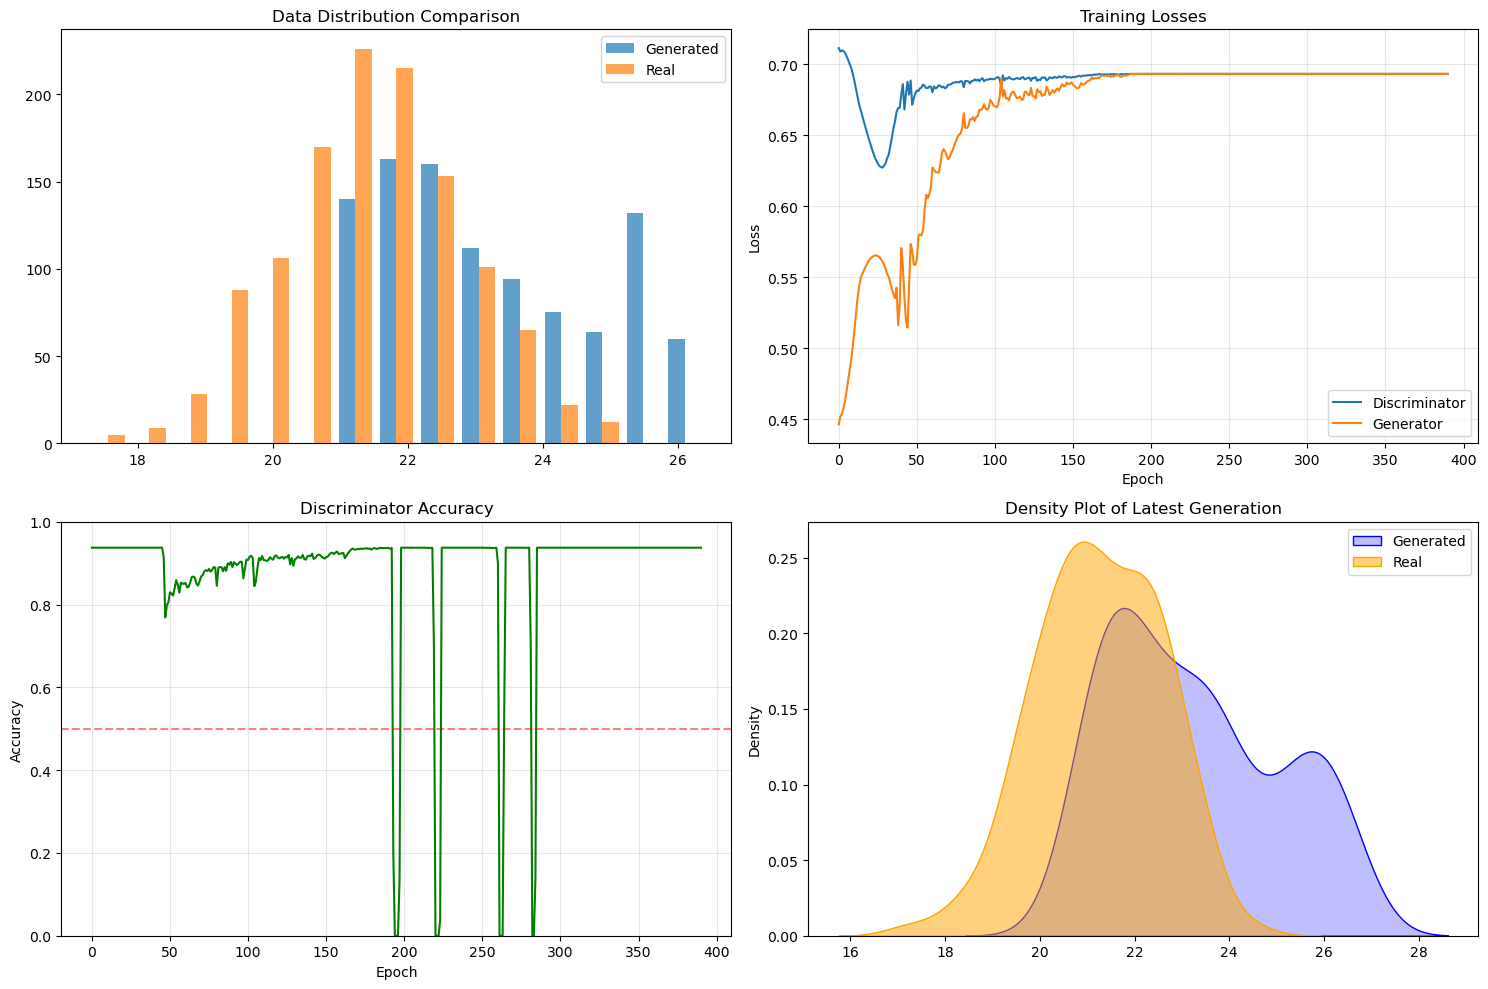

Epoch 391/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 392/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 393/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 394/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 395/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 396/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 397/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 398/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 399/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 400/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


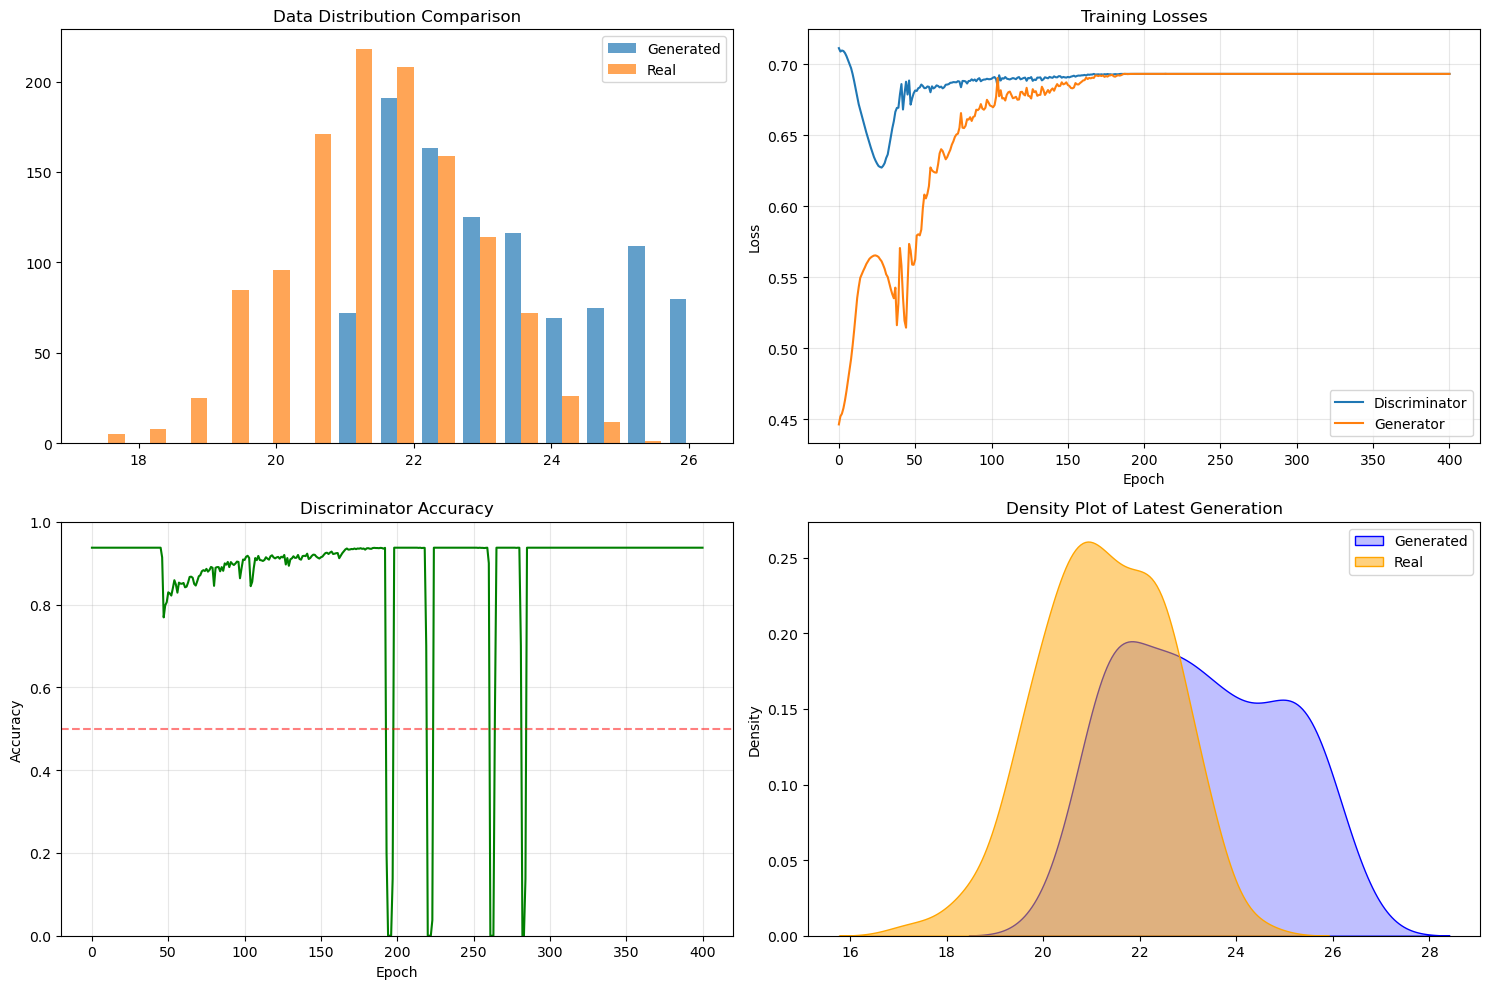

Epoch 401/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 402/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 403/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 404/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 405/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 406/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 407/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 408/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 409/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 410/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


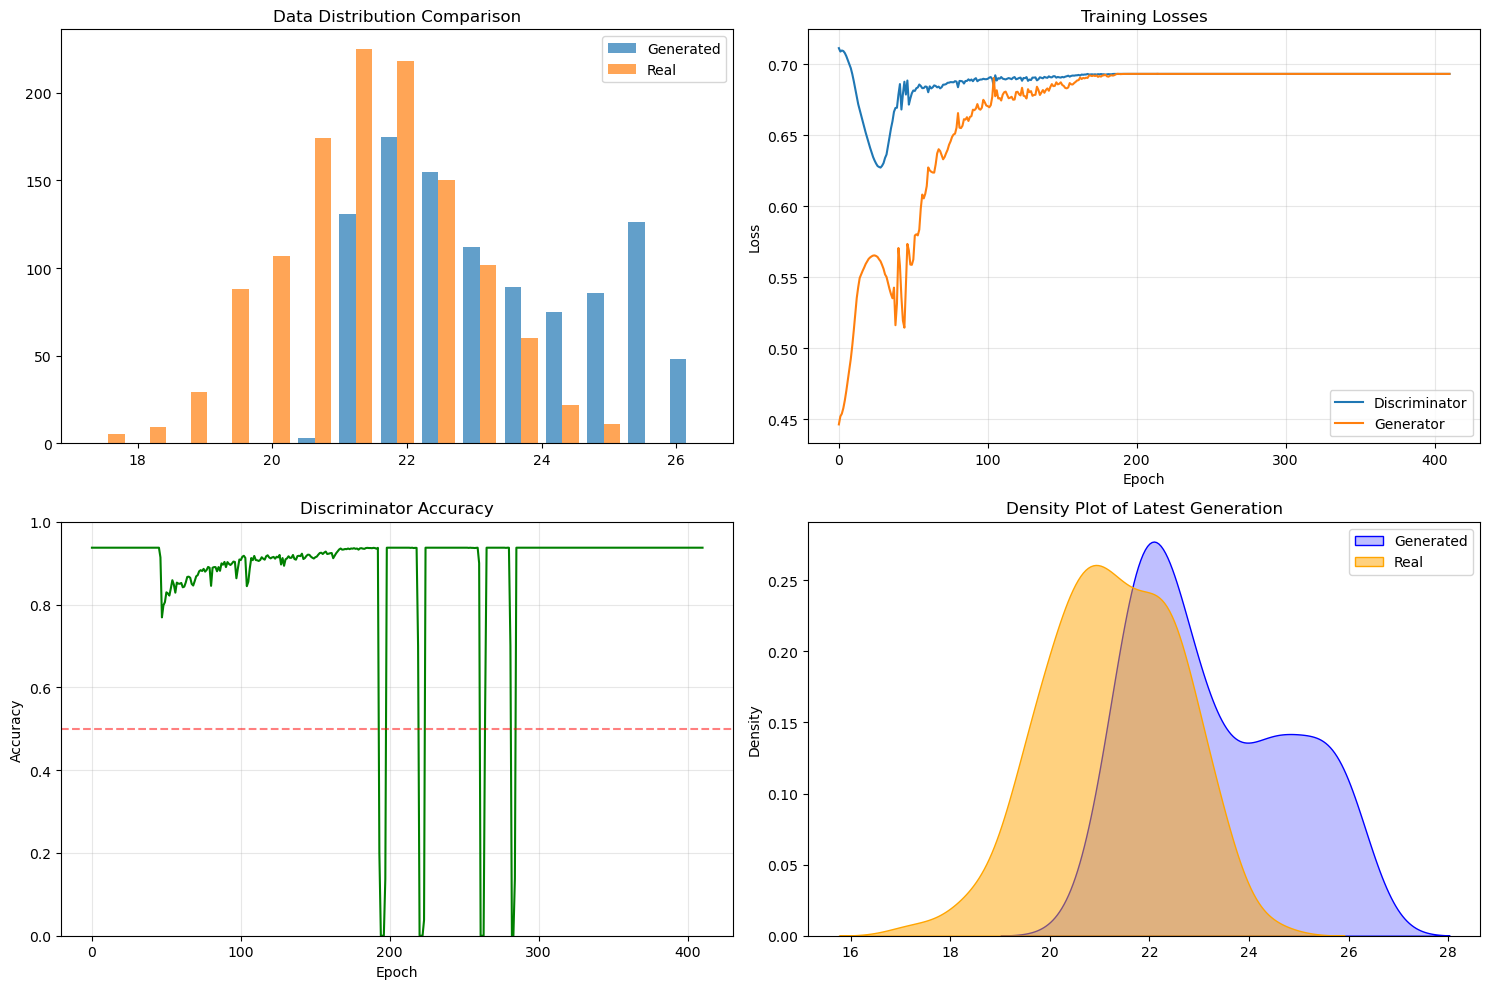

Epoch 411/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 412/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 413/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 414/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 415/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 416/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 417/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 418/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 419/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 420/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


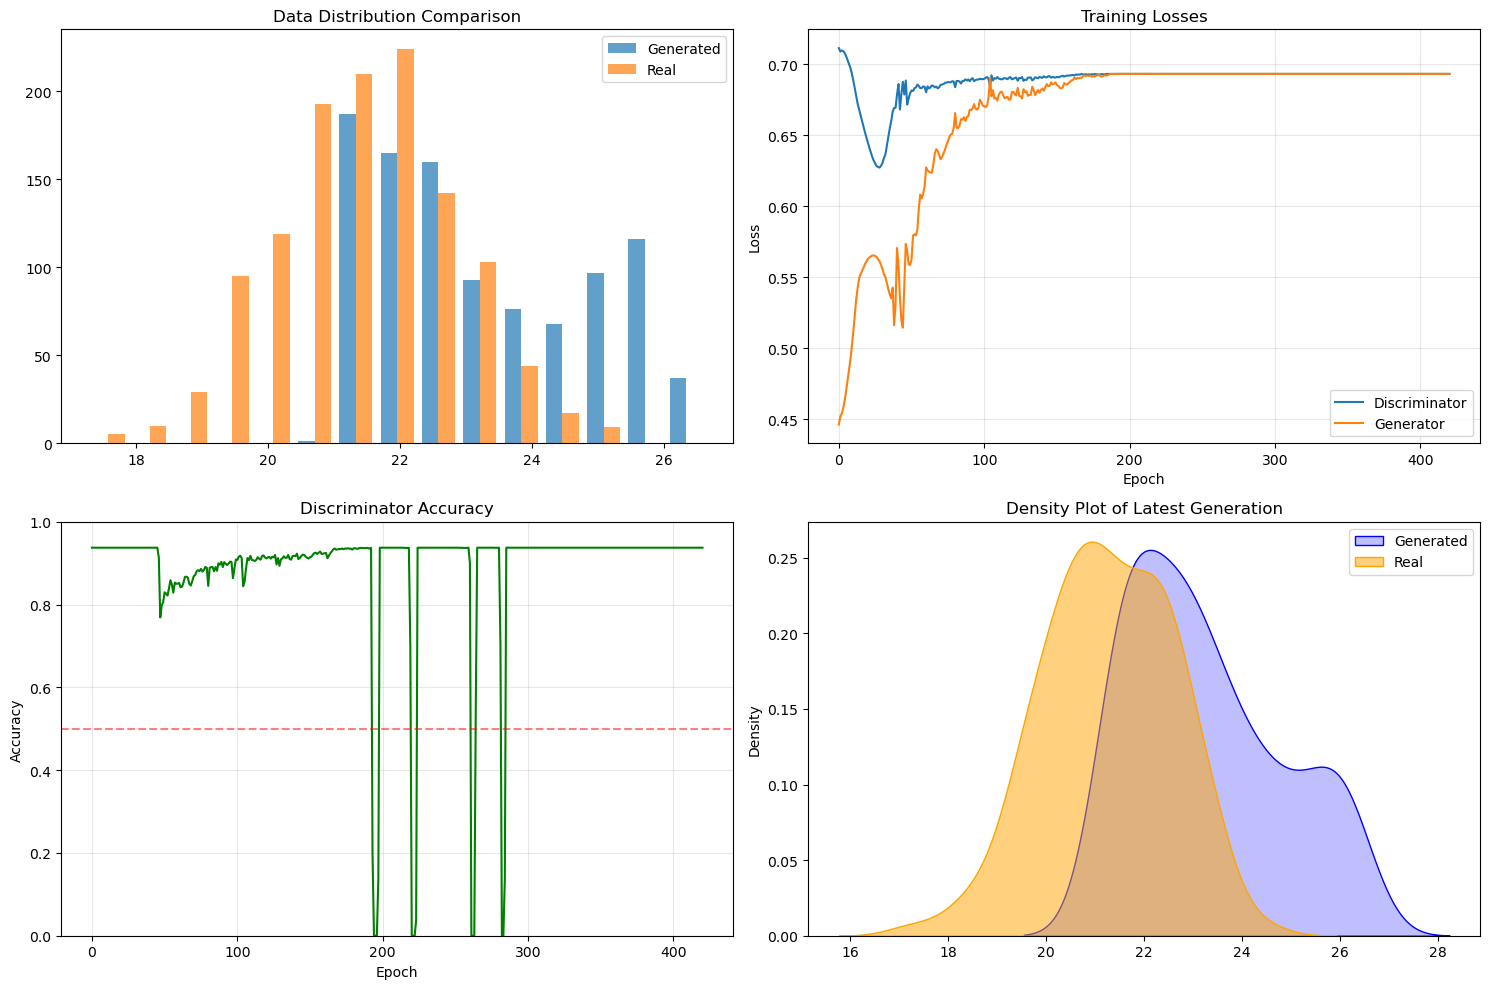

Epoch 421/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 422/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 423/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 424/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 425/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 426/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 427/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 428/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 429/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 430/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


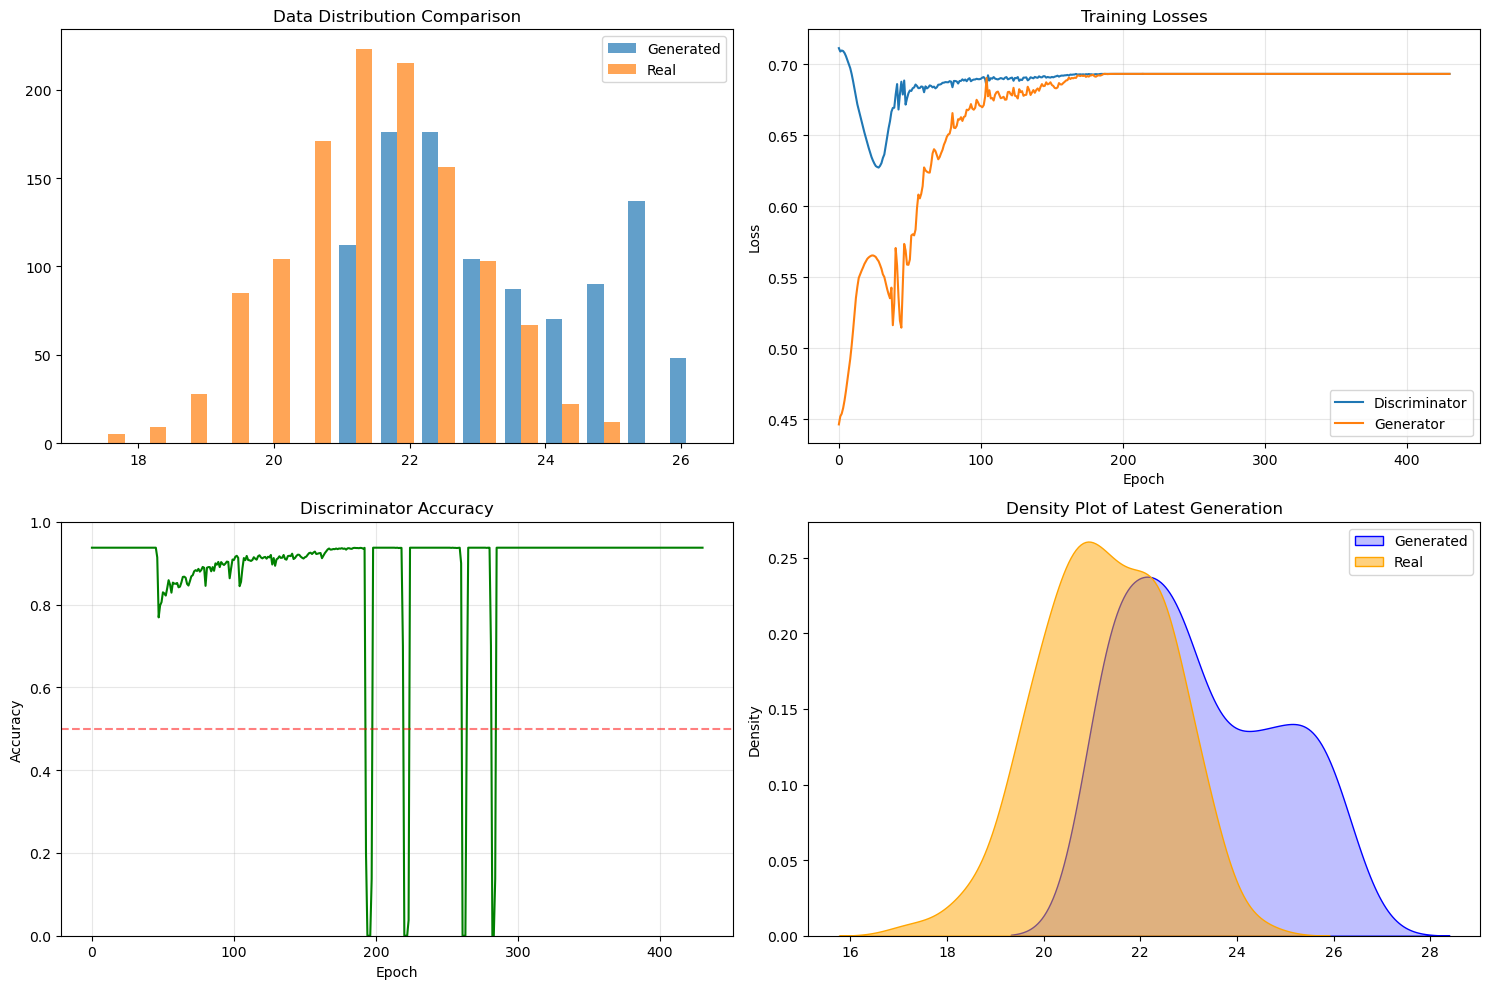

Epoch 431/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 432/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 433/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 434/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 435/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 436/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 437/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 438/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 439/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 440/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


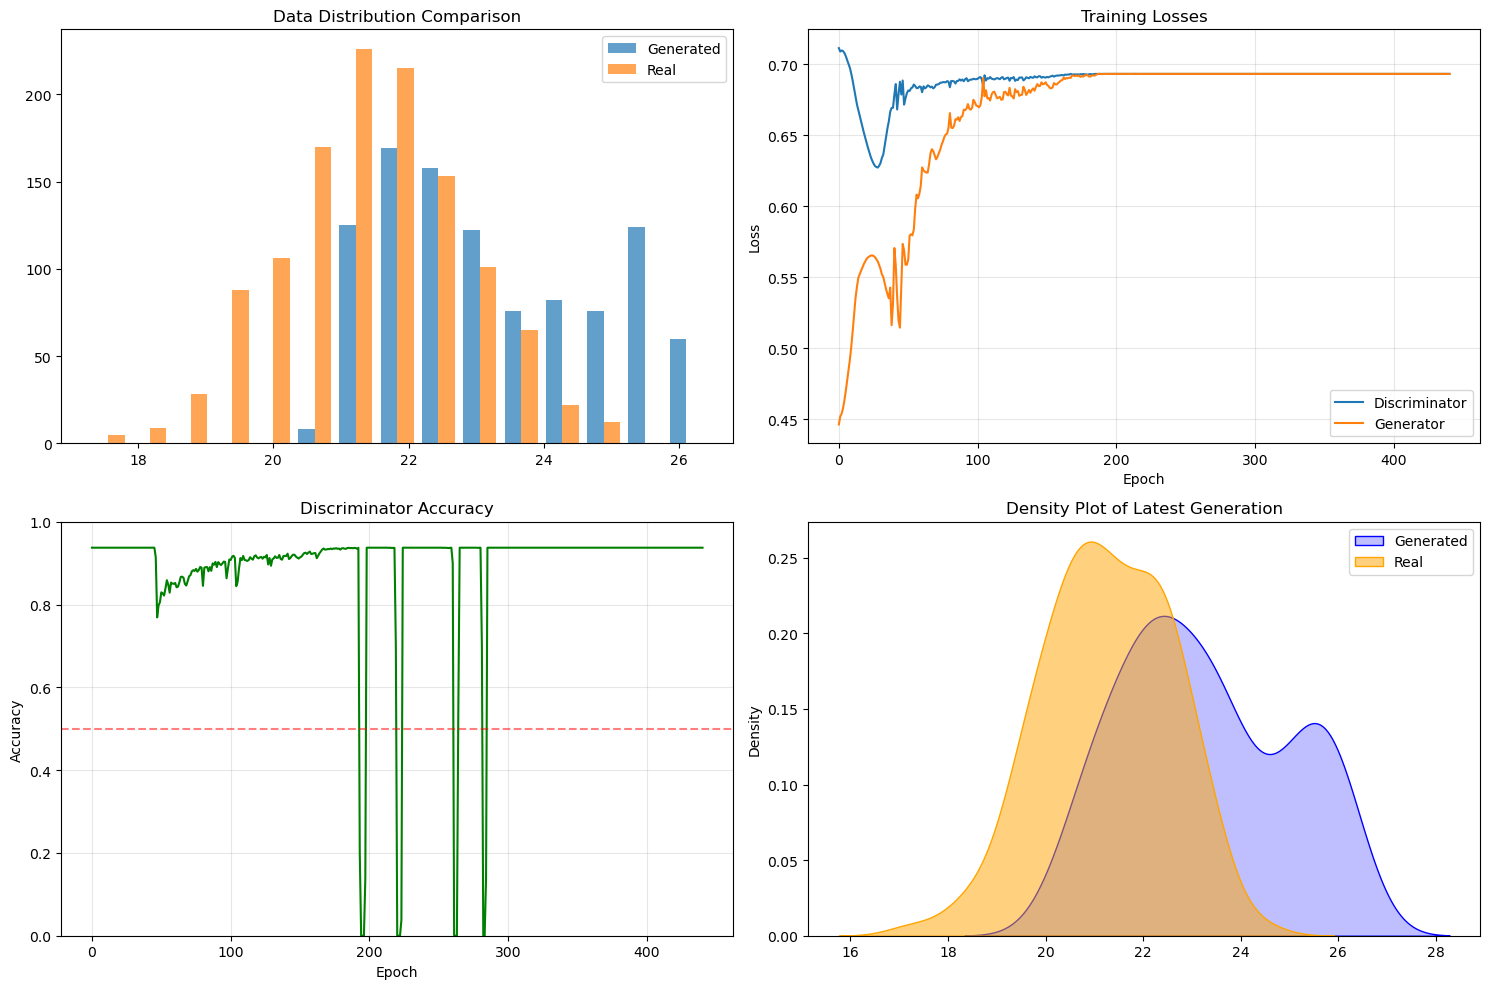

Epoch 441/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 442/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 443/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 444/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 445/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 446/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 447/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 448/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 449/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 450/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


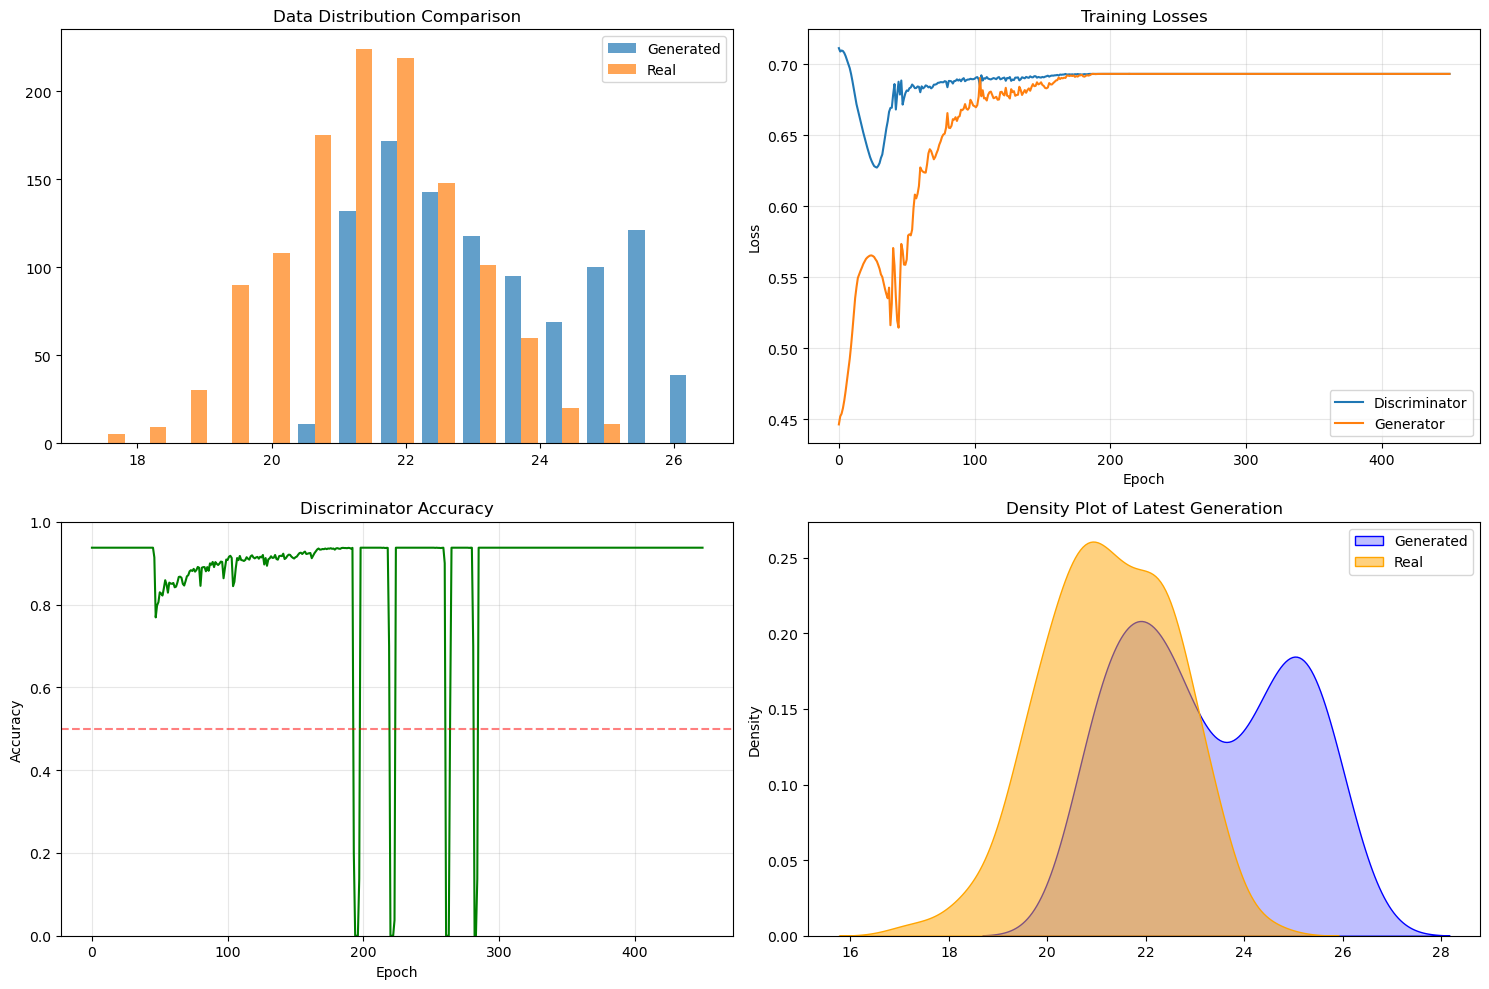

Epoch 451/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 452/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 453/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 454/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 455/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 456/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 457/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 458/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 459/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 460/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


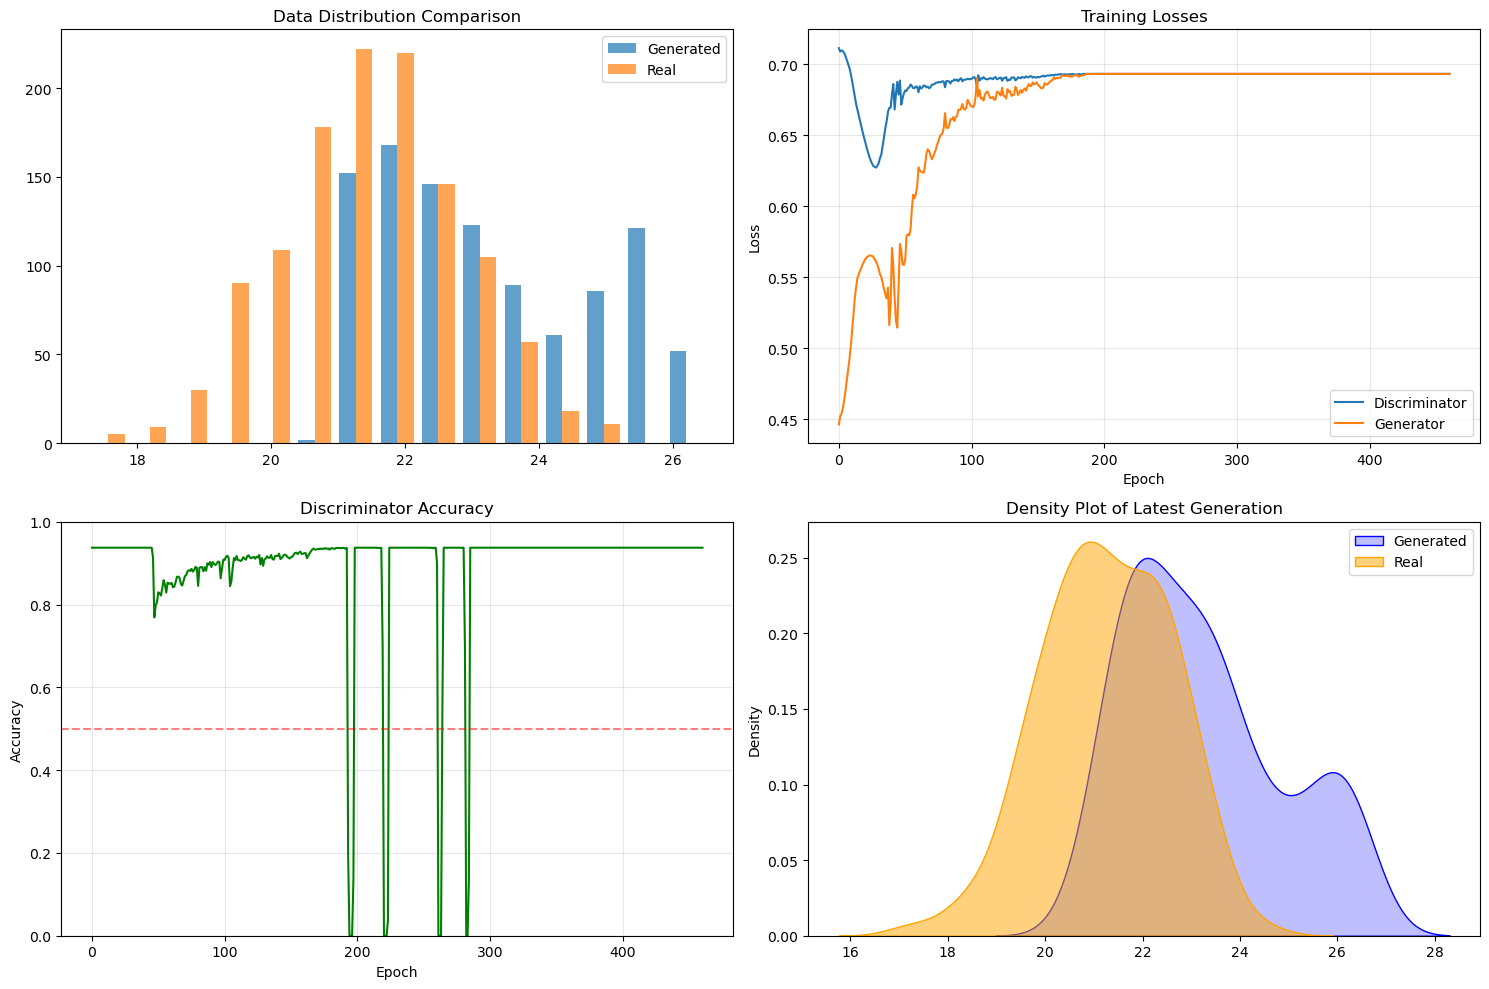

Epoch 461/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 462/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 463/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 464/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 465/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 466/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 467/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 468/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 469/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 470/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


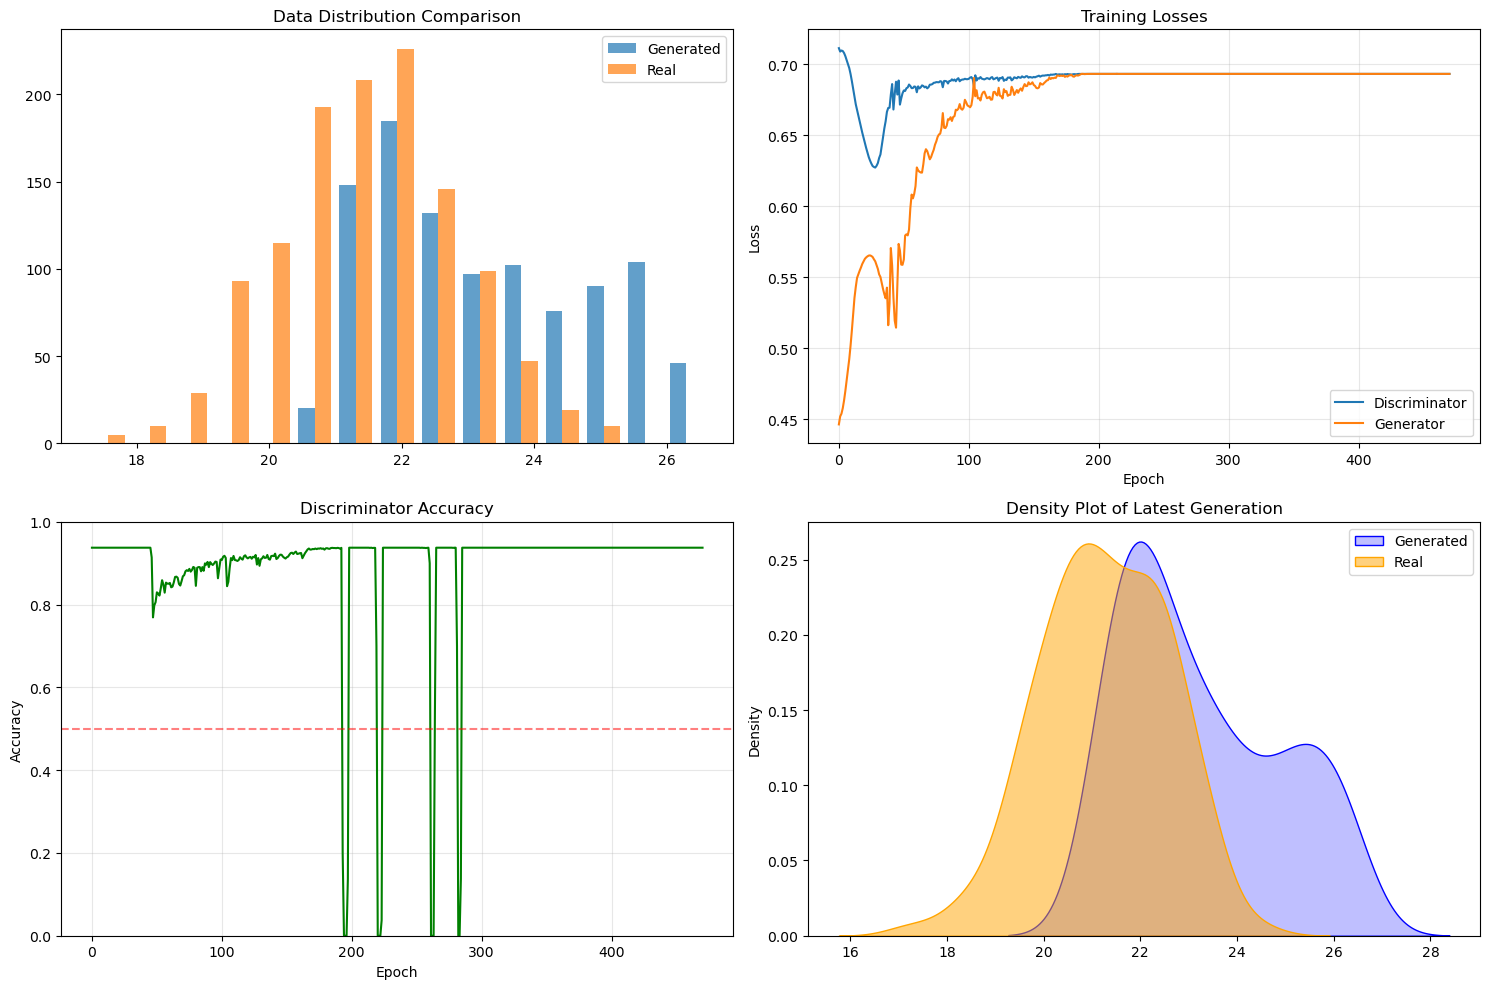

Epoch 471/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 472/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 473/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 474/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 475/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 476/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 477/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 478/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 479/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 480/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


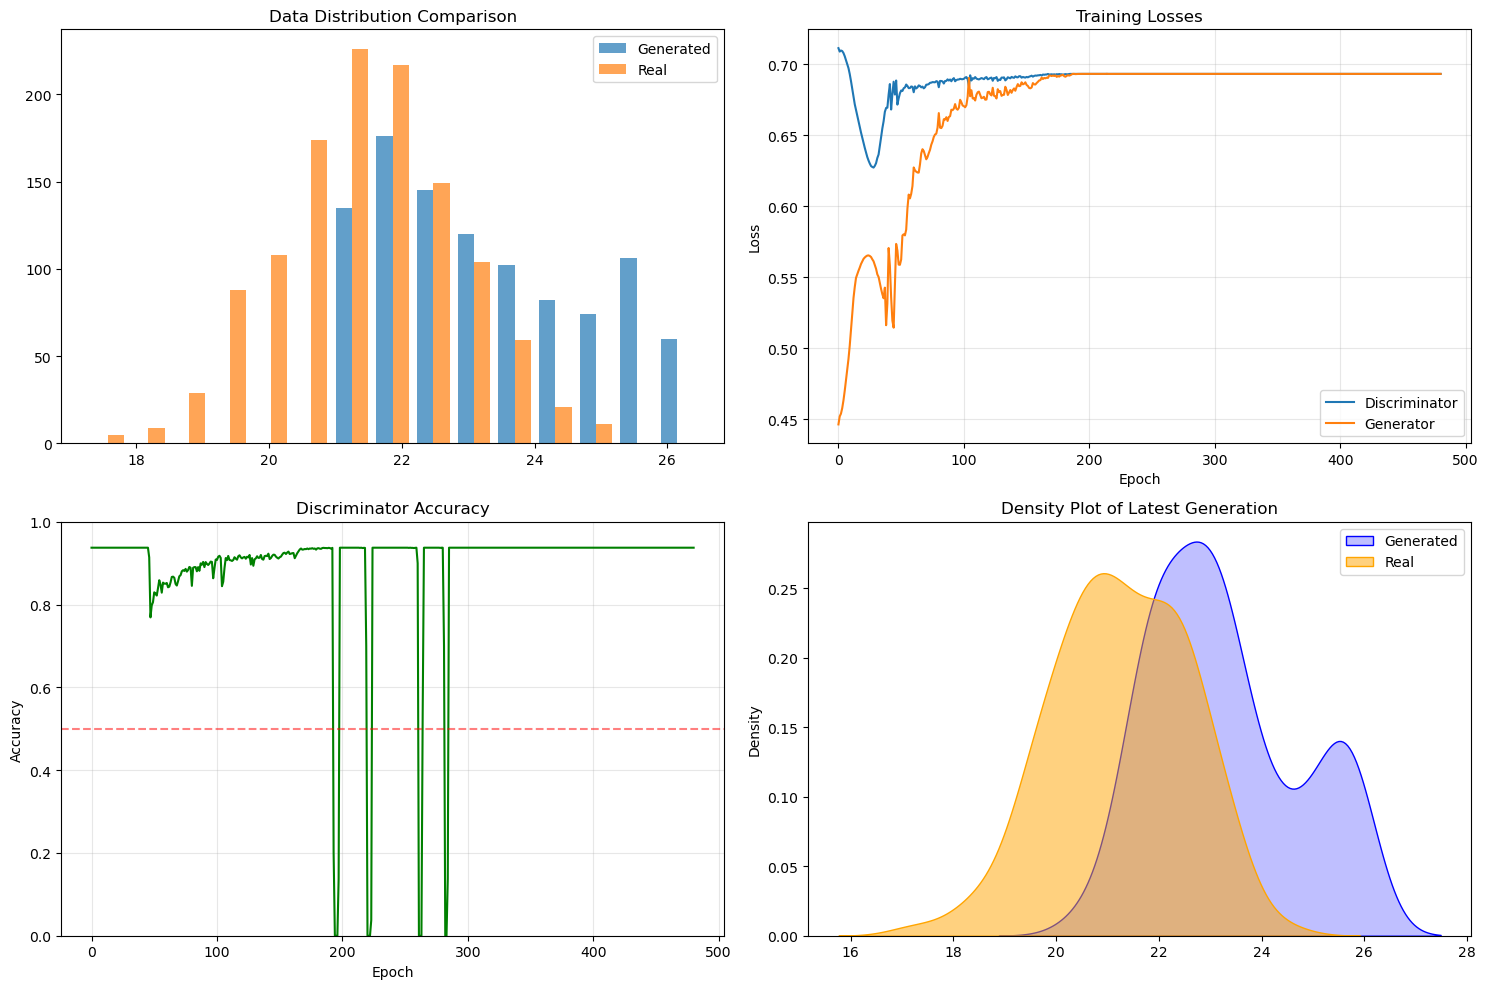

Epoch 481/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 482/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 483/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 484/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 485/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 486/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 487/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 488/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 489/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 490/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


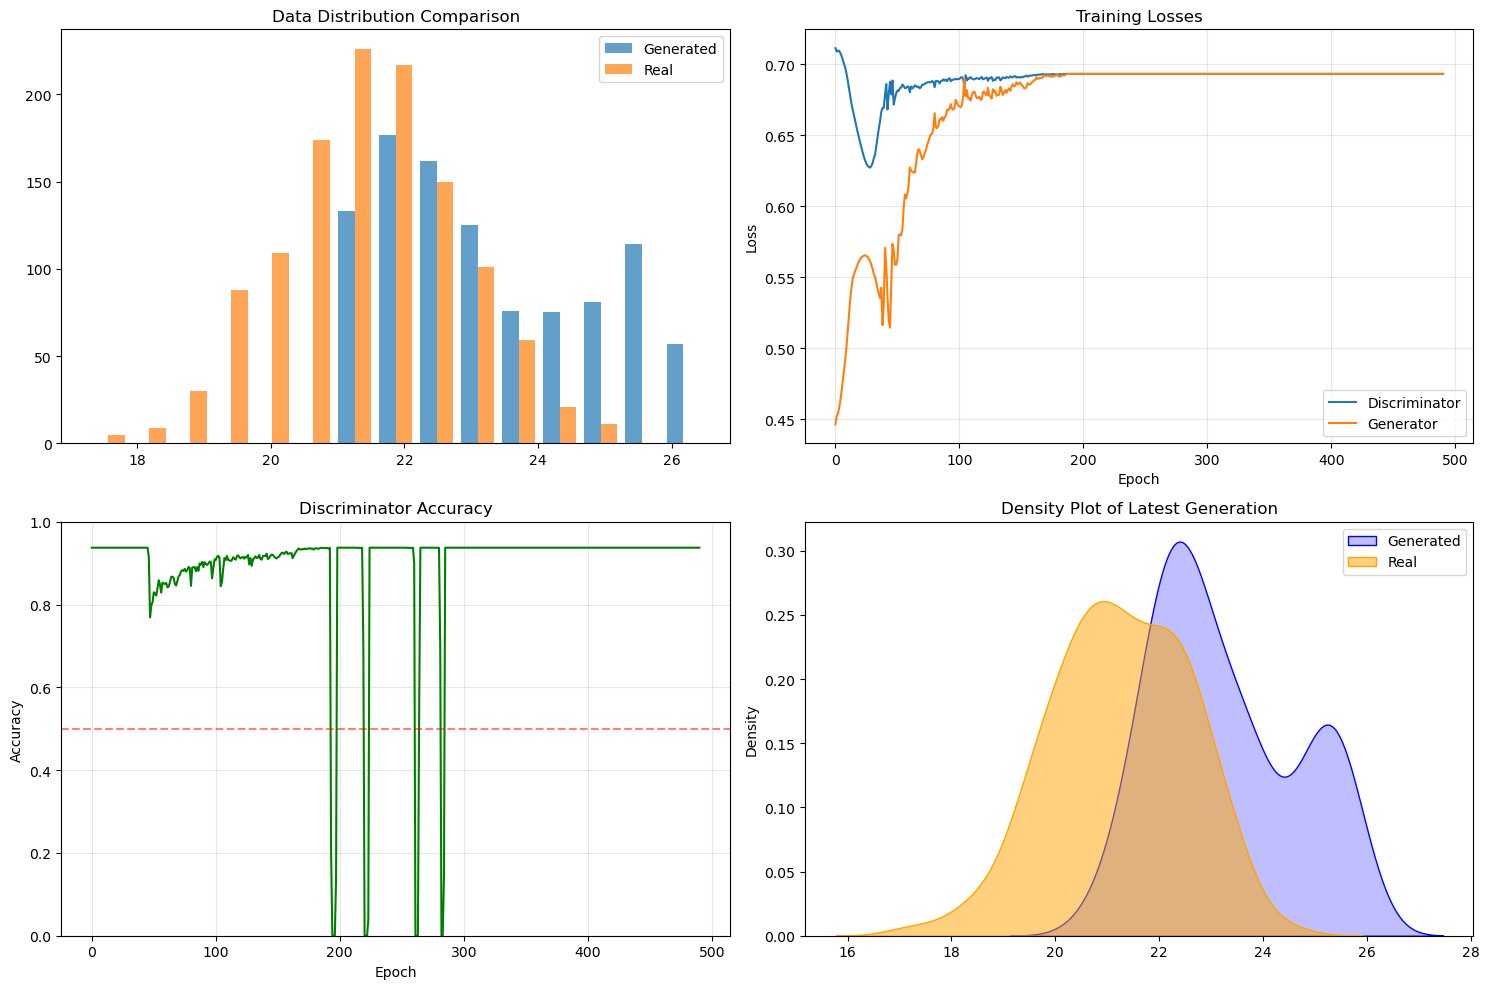

Epoch 491/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 492/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 493/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 494/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 495/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 496/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 497/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 498/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375
Epoch 499/500: D Loss: 0.6931, G Loss: 0.6931, D Accuracy: 0.9375


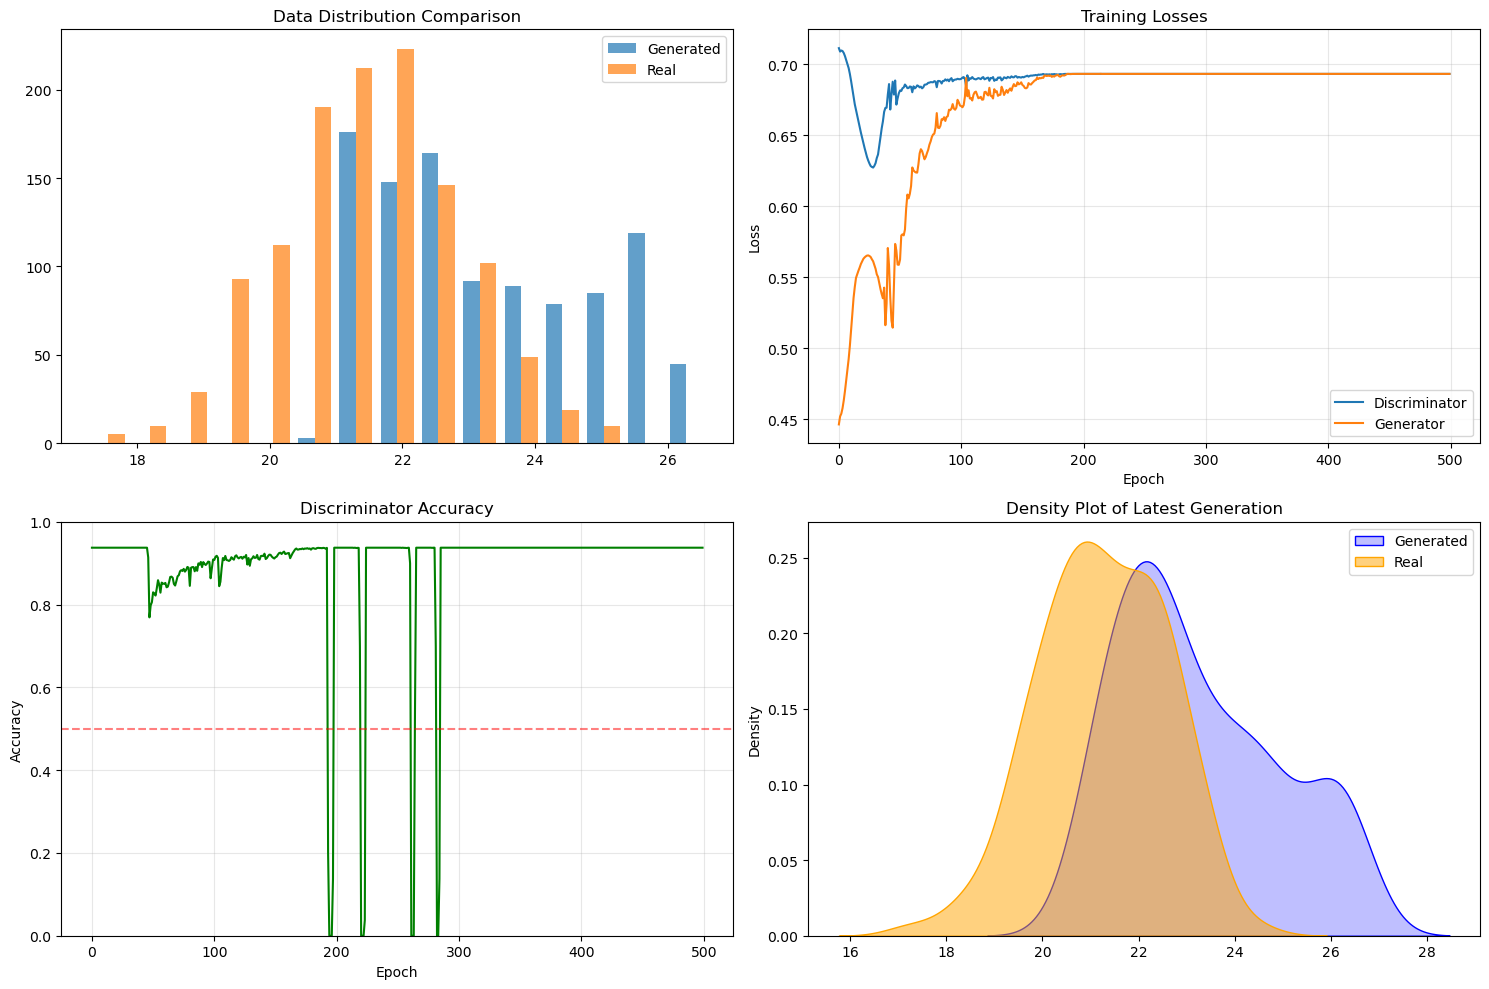


TRAINING COMPLETE
Final Discriminator Accuracy: 0.9375
Initial vs Final D Loss: 0.7113 → 0.6931
Initial vs Final G Loss: 0.4462 → 0.6931
Best Discriminator Performance: Epoch 0 (Accuracy: 0.9375)


In [27]:

dataset=torch.utils.data.TensorDataset(x_real, y_real)
dataloader= torch.utils.data.DataLoader(dataset, batch_size=batch_size)
loss_BCE = nn.BCELoss()
G_ = G(d_in = d_latent, d_x = d).to(device)
D_ = D(d_in = d).to(device)
opt_G = torch.optim.Adam(G_.parameters(), lr=0.001)
opt_D = torch.optim.Adam(D_.parameters(), lr=0.001)

d_losses = []
g_losses = []
d_accuracies = []
def get_sample_from_latent(num_samples_latent, d_latent):
    return torch.rand(num_samples_latent, d_latent)

for epoch in range(epochs):
    epoch_d_losses = []
    epoch_g_losses = []
    epoch_d_accuracies = []

    for i, (x_real_batch, y_real) in enumerate(dataloader):
                ## G
        batch_size_in = x_real_batch.shape[0]



        y_gen = torch.ones(batch_size_in, 1).to(device)

        z = get_sample_from_latent(batch_size_in, d_latent).to(device)


        ## D
        x_real_batch = x_real_batch.to(device)
        y_real = y_real.to(device)
        ######### fake
        #z = get_sample_from_latent(batch_size_in, d_latent).to(device)
        x_hat = G_(z.detach())
        y_fake = torch.zeros(batch_size_in, 1).to(device)
        pred_fake = D_(x_hat.detach())
        loss_fake = loss_BCE(pred_fake , y_fake)

        ######### real
        pred_real = D_(x_real_batch)
        loss_real = loss_BCE(pred_real, y_real)

        loss_total = (loss_fake  + loss_real )/2
        opt_D.zero_grad()
        loss_total.backward()
        opt_D.step()



        #### G
        x_hat = G_(z)
        pred = D_(x_hat)
        # loss_g = -torch.mean(torch.log(pred + 1e-8))  # Non-saturating loss

        loss_g = loss_BCE(pred, y_gen)
        opt_G.zero_grad()
        loss_g.backward()
        opt_G.step()
        epoch_g_losses.append(loss_g.item())


        with torch.no_grad():
            # Convert predictions to binary decisions (threshold at 0.5)
            pred_real_binary = (pred_real >= 0.5).float()
            pred_fake_binary = (pred_fake < 0.5).float()

            # Count correct predictions
            correct_real = (pred_real_binary == y_real).float().sum()
            correct_fake = (pred_fake_binary == y_fake).float().sum()

            # Calculate accuracy as the percentage of correct predictions
            total_samples = batch_size * 2  # both real and fake samples
            accuracy = (correct_real + correct_fake) / total_samples

            epoch_d_accuracies.append(accuracy.item())
            epoch_d_losses.append(loss_total.item())


    # At the end of each epoch, keep your summary stats collection the same
    mean_d_loss = sum(epoch_d_losses) / len(epoch_d_losses)
    mean_g_loss = sum(epoch_g_losses) / len(epoch_g_losses)
    mean_d_accuracy = sum(epoch_d_accuracies) / len(epoch_d_accuracies)
    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)
    d_accuracies.append(mean_d_accuracy)

    # Replace the print statements with a cleaner epoch summary
    print(f"Epoch {epoch}/{epochs}: D Loss: {mean_d_loss:.4f}, G Loss: {mean_g_loss:.4f}, D Accuracy: {mean_d_accuracy:.4f}")

    # Replace the periodic plotting with this enhanced visualization code (still every 10 epochs)
    if epoch % 10 == 0 or epoch == epochs-1:  # Add final epoch visualization
        plt.figure(figsize=(15, 10))

        # Plot 1: Generated vs Real Data
        plt.subplot(2, 2, 1)
        z = get_sample_from_latent(1000, d_latent).to(device)  # More samples for better histogram
        generated = G_(z).cpu().detach().numpy()
        plt.hist([generated.squeeze(), x_real.cpu().numpy().squeeze()], bins=15,
                 label=['Generated', 'Real'], alpha=0.7)
        plt.title("Data Distribution Comparison", fontsize=12)
        plt.legend()

        # Plot 2: Training Losses
        plt.subplot(2, 2, 2)
        plt.plot(d_losses, label='Discriminator')
        plt.plot(g_losses, label='Generator')
        plt.title("Training Losses", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        # Plot 3: Discriminator Accuracy
        plt.subplot(2, 2, 3)
        plt.plot(d_accuracies, color='green')
        plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)  # Random guess line
        plt.title("Discriminator Accuracy", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)

        # Plot 4: Latest Generator Output
        plt.subplot(2, 2, 4)
        z = get_sample_from_latent(batch_size, d_latent).to(device)
        generated_batch = G_(z).cpu().detach().numpy()
        sns.kdeplot(generated_batch.flatten(), fill=True, color='blue', label='Generated')
        sns.kdeplot(x_real[:batch_size].cpu().numpy().flatten(), fill=True, color='orange',
                    alpha=0.5, label='Real')
        plt.title("Density Plot of Latest Generation", fontsize=12)
        plt.legend()

        plt.tight_layout()
        plt.savefig(f"gan_progress_epoch_{epoch}.png")  # Save the plot
        plt.show()

    # Add this at the end of training to show the final performance summary
    if epoch == epochs-1:
        # Final performance report
        print("\n" + "="*50)
        print("TRAINING COMPLETE")
        print("="*50)
        print(f"Final Discriminator Accuracy: {d_accuracies[-1]:.4f}")
        print(f"Initial vs Final D Loss: {d_losses[0]:.4f} → {d_losses[-1]:.4f}")
        print(f"Initial vs Final G Loss: {g_losses[0]:.4f} → {g_losses[-1]:.4f}")

        # Show best epoch
        best_epoch = d_accuracies.index(max(d_accuracies))
        print(f"Best Discriminator Performance: Epoch {best_epoch} (Accuracy: {max(d_accuracies):.4f})")
        print("="*50)

## Mixture of Gaussian

In [13]:
num_components = 8

m = 1200 * num_components
d = 1
device = torch.device("mps")
d_latent = num_components * 2
epochs = 500
batch_size = 128


In [14]:

component_weights = torch.ones(num_components) / num_components  # Equal weights by default

# Parameters for each Gaussian component
means = torch.randn(num_components, d) * 20  # Random means for each component
stds = torch.rand(num_components, d) * 0.5 + 0.5  # Random standard deviations

# Generate samples from mixture of Gaussians
component_indices = torch.multinomial(component_weights, m, replacement=True)
x_real = torch.zeros(m, d)

for i in range(m):
    component_idx = component_indices[i]
    x_real[i] = torch.randn(d) * stds[component_idx] + means[component_idx]

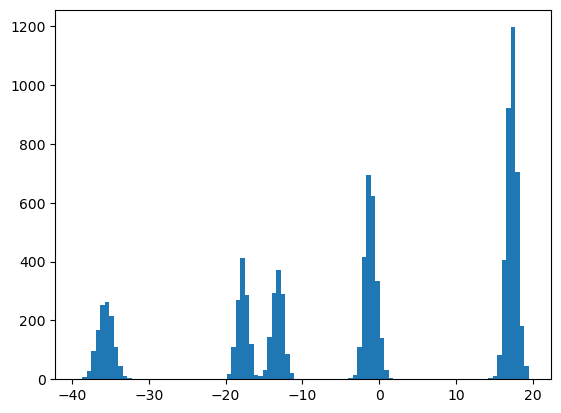

In [15]:
plt.hist(x_real,  bins=100);

In [16]:

y_real = torch.ones(m, 1)
batch_size = 128
dataset=torch.utils.data.TensorDataset(x_real, y_real)
dataloader= torch.utils.data.DataLoader(dataset, batch_size=batch_size)
loss_BCE = nn.BCELoss()
G_ = G(d_in = d_latent, d_x = d).to(device)
D_ = D(d_in = d).to(device)
opt_G = torch.optim.Adam(G_.parameters(), lr=0.002)
opt_D = torch.optim.Adam(D_.parameters(), lr=0.002)


d_losses = []
g_losses = []
d_accuracies = []


for epoch in range(epochs):
    epoch_d_losses = []
    epoch_g_losses = []
    epoch_d_accuracies = []

    for i, (x_real_batch, y_real) in enumerate(dataloader):
                ## G
        batch_size = x_real_batch.shape[0]



        y_gen = torch.ones(batch_size, 1).to(device)

        z = get_sample_from_latent(batch_size, d_latent).to(device)


        ## D
        x_real_batch = x_real_batch.to(device)
        y_real = y_real.to(device)
        ######### fake
        #z = get_sample_from_latent(batch_size, d_latent).to(device)
        x_hat = G_(z.detach())
        y_fake = torch.zeros(batch_size, 1).to(device)
        pred_fake = D_(x_hat.detach())
        loss_fake = loss_BCE(pred_fake , y_fake)

        ######### real
        pred_real = D_(x_real_batch)
        loss_real = loss_BCE(pred_real, y_real)

        loss_total = (loss_fake  + loss_real )/2
        opt_D.zero_grad()
        loss_total.backward()
        opt_D.step()



        #### G


        x_hat = G_(z)
        pred = D_(x_hat)
        loss_g = -torch.mean(torch.log(pred + 1e-8))  # Non-saturating loss

        #loss_g = loss_BCE(pred, y_gen)
        opt_G.zero_grad()
        loss_g.backward()
        opt_G.step()
        epoch_g_losses.append(loss_g.item())


        with torch.no_grad():
            # Convert predictions to binary decisions (threshold at 0.5)
            pred_real_binary = (pred_real >= 0.5).float()
            pred_fake_binary = (pred_fake < 0.5).float()

            # Count correct predictions
            correct_real = (pred_real_binary == y_real).float().sum()
            correct_fake = (pred_fake_binary == y_fake).float().sum()

            # Calculate accuracy as the percentage of correct predictions
            total_samples = batch_size * 2  # both real and fake samples
            accuracy = (correct_real + correct_fake) / total_samples

            epoch_d_accuracies.append(accuracy.item())
            epoch_d_losses.append(loss_total.item())

        # if i % 100 == 0:
            # print("This round:")
            # print(f"D Loss: {loss_total.detach():.4f}")
            # print(f"Real Loss: {loss_real.detach():.4f}")
            # print(f"Fake Loss: {loss_fake.detach():.4f}")
            # print(f"D Accuracy: {accuracy.item():.4f}")

    # At the end of each epoch, keep your summary stats collection the same
    mean_d_loss = sum(epoch_d_losses) / len(epoch_d_losses)
    mean_g_loss = sum(epoch_g_losses) / len(epoch_g_losses)
    mean_d_accuracy = sum(epoch_d_accuracies) / len(epoch_d_accuracies)
    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)
    d_accuracies.append(mean_d_accuracy)

    # Replace the print statements with a cleaner epoch summary
    print(f"Epoch {epoch}/{epochs}: D Loss: {mean_d_loss:.4f}, G Loss: {mean_g_loss:.4f}, D Accuracy: {mean_d_accuracy:.4f}")

    # Replace the periodic plotting with this enhanced visualization code (still every 10 epochs)
    if epoch % 10 == 0 or epoch == epochs-1:  # Add final epoch visualization
        plt.figure(figsize=(15, 10))

        # Plot 1: Generated vs Real Data
        plt.subplot(2, 2, 1)
        z = get_sample_from_latent(1000, d_latent).to(device)  # More samples for better histogram
        generated = G_(z).cpu().detach().numpy()
        plt.hist([generated.squeeze(), x_real.cpu().numpy().squeeze()], bins=15,
                 label=['Generated', 'Real'], alpha=0.7)
        plt.title("Data Distribution Comparison", fontsize=12)
        plt.legend()

        # Plot 2: Training Losses
        plt.subplot(2, 2, 2)
        plt.plot(d_losses, label='Discriminator')
        plt.plot(g_losses, label='Generator')
        plt.title("Training Losses", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        # Plot 3: Discriminator Accuracy
        plt.subplot(2, 2, 3)
        plt.plot(d_accuracies, color='green')
        plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)  # Random guess line
        plt.title("Discriminator Accuracy", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)

        # Plot 4: Latest Generator Output
        plt.subplot(2, 2, 4)
        z = get_sample_from_latent(batch_size, d_latent).to(device)
        generated_batch = G_(z).cpu().detach().numpy()
        sns.kdeplot(generated_batch.flatten(), fill=True, color='blue', label='Generated')
        sns.kdeplot(x_real[:batch_size].cpu().numpy().flatten(), fill=True, color='orange',
                    alpha=0.5, label='Real')
        plt.title("Density Plot of Latest Generation", fontsize=12)
        plt.legend()

        plt.tight_layout()
        plt.savefig(f"gan_progress_epoch_{epoch}.png")  # Save the plot
        plt.show()

    # Add this at the end of training to show the final performance summary
    if epoch == epochs-1:
        # Final performance report
        print("\n" + "="*50)
        print("TRAINING COMPLETE")
        print("="*50)
        print(f"Final Discriminator Accuracy: {d_accuracies[-1]:.4f}")
        print(f"Initial vs Final D Loss: {d_losses[0]:.4f} → {d_losses[-1]:.4f}")
        print(f"Initial vs Final G Loss: {g_losses[0]:.4f} → {g_losses[-1]:.4f}")

        # Show best epoch
        best_epoch = d_accuracies.index(max(d_accuracies))
        print(f"Best Discriminator Performance: Epoch {best_epoch} (Accuracy: {max(d_accuracies):.4f})")
        print("="*50)

TypeError: D.__init__() missing 1 required positional argument: 'num_layers'

Seems like high number of samples helps in training

In [ ]:

y_real = torch.ones(m, 1)
batch_size = 128
dataset=torch.utils.data.TensorDataset(x_real, y_real)
dataloader= torch.utils.data.DataLoader(dataset, batch_size=batch_size)
loss_BCE = nn.BCELoss()
G_ = G(d_in = d_latent, d_x = d).to(device)
D_ = D(d_in = d).to(device)
opt_G = torch.optim.Adam(G_.parameters(), lr=0.002)
opt_D = torch.optim.Adam(D_.parameters(), lr=0.002)


d_losses = []
g_losses = []
d_accuracies = []


for epoch in range(epochs):
    epoch_d_losses = []
    epoch_g_losses = []
    epoch_d_accuracies = []

    for i, (x_real_batch, y_real) in enumerate(dataloader):
                ## G
        batch_size = x_real_batch.shape[0]



        y_gen = torch.ones(batch_size, 1).to(device)

        z = get_sample_from_latent(batch_size, d_latent).to(device)


        ## D
        x_real_batch = x_real_batch.to(device)
        y_real = y_real.to(device)
        ######### fake
        #z = get_sample_from_latent(batch_size, d_latent).to(device)
        x_hat = G_(z.detach())
        y_fake = torch.zeros(batch_size, 1).to(device)
        pred_fake = D_(x_hat.detach())
        loss_fake = loss_BCE(pred_fake , y_fake)

        ######### real
        pred_real = D_(x_real_batch)
        loss_real = loss_BCE(pred_real, y_real)

        loss_total = (loss_fake  + loss_real )/2
        opt_D.zero_grad()
        loss_total.backward()
        opt_D.step()



        #### G


        x_hat = G_(z)
        pred = D_(x_hat)
        # loss_g = -torch.mean(torch.log(pred + 1e-8))  # Non-saturating loss

        loss_g = loss_BCE(pred, y_gen)
        opt_G.zero_grad()
        loss_g.backward()
        opt_G.step()
        epoch_g_losses.append(loss_g.item())


        with torch.no_grad():
            # Convert predictions to binary decisions (threshold at 0.5)
            pred_real_binary = (pred_real >= 0.5).float()
            pred_fake_binary = (pred_fake < 0.5).float()

            # Count correct predictions
            correct_real = (pred_real_binary == y_real).float().sum()
            correct_fake = (pred_fake_binary == y_fake).float().sum()

            # Calculate accuracy as the percentage of correct predictions
            total_samples = batch_size * 2  # both real and fake samples
            accuracy = (correct_real + correct_fake) / total_samples

            epoch_d_accuracies.append(accuracy.item())
            epoch_d_losses.append(loss_total.item())

        # if i % 100 == 0:
            # print("This round:")
            # print(f"D Loss: {loss_total.detach():.4f}")
            # print(f"Real Loss: {loss_real.detach():.4f}")
            # print(f"Fake Loss: {loss_fake.detach():.4f}")
            # print(f"D Accuracy: {accuracy.item():.4f}")

    # At the end of each epoch, keep your summary stats collection the same
    mean_d_loss = sum(epoch_d_losses) / len(epoch_d_losses)
    mean_g_loss = sum(epoch_g_losses) / len(epoch_g_losses)
    mean_d_accuracy = sum(epoch_d_accuracies) / len(epoch_d_accuracies)
    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)
    d_accuracies.append(mean_d_accuracy)

    # Replace the print statements with a cleaner epoch summary
    print(f"Epoch {epoch}/{epochs}: D Loss: {mean_d_loss:.4f}, G Loss: {mean_g_loss:.4f}, D Accuracy: {mean_d_accuracy:.4f}")

    # Replace the periodic plotting with this enhanced visualization code (still every 10 epochs)
    if epoch % 10 == 0 or epoch == epochs-1:  # Add final epoch visualization
        plt.figure(figsize=(15, 10))

        # Plot 1: Generated vs Real Data
        plt.subplot(2, 2, 1)
        z = get_sample_from_latent(1000, d_latent).to(device)  # More samples for better histogram
        generated = G_(z).cpu().detach().numpy()
        plt.hist([generated.squeeze(), x_real.cpu().numpy().squeeze()], bins=15,
                 label=['Generated', 'Real'], alpha=0.7)
        plt.title("Data Distribution Comparison", fontsize=12)
        plt.legend()

        # Plot 2: Training Losses
        plt.subplot(2, 2, 2)
        plt.plot(d_losses, label='Discriminator')
        plt.plot(g_losses, label='Generator')
        plt.title("Training Losses", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        # Plot 3: Discriminator Accuracy
        plt.subplot(2, 2, 3)
        plt.plot(d_accuracies, color='green')
        plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)  # Random guess line
        plt.title("Discriminator Accuracy", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)

        # Plot 4: Latest Generator Output
        plt.subplot(2, 2, 4)
        z = get_sample_from_latent(batch_size, d_latent).to(device)
        generated_batch = G_(z).cpu().detach().numpy()
        sns.kdeplot(generated_batch.flatten(), fill=True, color='blue', label='Generated')
        sns.kdeplot(x_real[:batch_size].cpu().numpy().flatten(), fill=True, color='orange',
                    alpha=0.5, label='Real')
        plt.title("Density Plot of Latest Generation", fontsize=12)
        plt.legend()

        plt.tight_layout()
        plt.savefig(f"gan_progress_epoch_{epoch}.png")  # Save the plot
        plt.show()

    # Add this at the end of training to show the final performance summary
    if epoch == epochs-1:
        # Final performance report
        print("\n" + "="*50)
        print("TRAINING COMPLETE")
        print("="*50)
        print(f"Final Discriminator Accuracy: {d_accuracies[-1]:.4f}")
        print(f"Initial vs Final D Loss: {d_losses[0]:.4f} → {d_losses[-1]:.4f}")
        print(f"Initial vs Final G Loss: {g_losses[0]:.4f} → {g_losses[-1]:.4f}")

        # Show best epoch
        best_epoch = d_accuracies.index(max(d_accuracies))
        print(f"Best Discriminator Performance: Epoch {best_epoch} (Accuracy: {max(d_accuracies):.4f})")
        print("="*50)

In [ ]:
z = get_sample_from_latent(10000, d_latent).to(device)

In [ ]:
plt.hist(G_(z).cpu().detach().numpy(), bins=30);
plt.hist(x_real.cpu().numpy().flatten(), bins=30);